<center>    

<h2> Data Analysis Project: Gemini Model </h2>

  <h4>Project Members:</h4>
    <ul style="list-style-type:none;">
        <li>Nazanin Mirzaei</li>
        <li>Hamed Zohrab</li>
        <li>Farin khodam Mohammadi</li>
    </ul> 
    <h4>Supervisor: Gholamali Aminian</h4>

<p>
The goal of this project is to specifically analyze the performance of the Gemini model in various matches and identify which features contribute to its winning outcomes.  
Initially, we performed a broad exploration of the dataset to understand all columns and their distributions, providing a comprehensive view of the data.  
Then, we focused on a specific set of features that are particularly relevant for evaluating the Gemini model's performance and winner comparison.  
Over time, additional features can be incorporated to enhance the analysis.
</p>

<h1>Contents of the Data Analysis Project</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <a href="#Step-1-Pre-Processing">Step 1: Pre-Processing</a>
            <ol>
                     <li><a href="#Tools">Tools</a></li>
                    <li><a href="#Data-Cleaning-Mapping-and-Feature-Extraction">Data Cleaning, Mapping, and Feature Extraction</a></li>
                    <li><a href="#Plot-1-Gemini-Win-Loss-Analysis">Plots</a></li>
                    <a href="#Plot-1-Gemini-Win-Loss-Analysis">Plot 1: Gemini Win/Loss Analysis</a>
                    <br><a href="#Plot-2-Correlation-Analysis-of-Numeric-Features">Plot 2: Correlation Analysis of Numeric Features</a>
                    <br><a href="#Plot-3-Feature-Distribution-Exploration">Plot 3: Feature Distribution Exploration</a>
                    <br><a href="#Plot-4-Winner-Count-Overview">Plot 4: Winner Count Overview</a>
                    <br><a href="#Plot-5-Average-Absolute-Difference-Analysis">Plot 5: Average Absolute Difference Analysis</a>
                    <br><a href="#Plot-6-Average-Percent-Difference-Analysis">Plot 6: Average Percent Difference Analysis</a>
                    <br><a href="#Plot-7-Average-Feature-Values-by-Winner">Plot 7: Average Feature Values by Winner</a>
                    <br><a href="#Plot-8-Features-Contributing-to-Gemini-Wins">Plot 8: Features Contributing to Gemini Wins</a>
                    <br><a href="#Plot-9-Features-Contributing-to-Gemini-Loss">Plot 9: Features Contributing to Gemini Loss</a>
                    <br><a href="#Plot-10-Features-Similar-in-Tie-Outcomes">Plot 10: Features Similar in Tie Outcomes</a>
                    <br><a href="#Plot-11-RandomForest-Feature-Importance">Plot 11: RandomForest Feature Importance</a>
                    <br><a href="#Plot-12-Correlation-Analysis-with-Gemini-Wins">Plot 12: Correlation Analysis with Gemini Wins</a>
                    <br><a href="#Plot-13-Interactive-Violin-Plots">Plot 13: Interactive Violin Plots</a>
                    <br><a href="#Plot-14-Feature-Comparison-by-Winner">Plot 14: Feature Comparison by Winner (Percentage of Max)</a>
                    <br><a href="#Plot-15-Criteria-Breakdown-by-Winner">Plot 15: Criteria Breakdown by Winner</a>
                    <br><a href="#Plot-16-Categorical-Features-on-Gemini-Win">Plot 16: Effect of Categorical (Boolean) Features on Gemini Win</a>
                    <br><a href="Plot-17-Feature-Importance-for-Gemini-Win">Plot 17: Feature Importance for Predicting Gemini Win</a>
                    <br><a href="Plot-18-Cumulative-Win-Rate-Curve">Plot 18: Cumulative  Win Rate Curve for Gemini</a>
          </ol>
    </ol>

<div id="Step-1-Pre-Processing">
    <h1>Step 1: Pre-Processing</h1>
</div>

<div id="Tools">
    <h1>Tools</h1>
</div>

In [52]:
import yaml
with open("config.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
import umap
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import plotly.express as px
from scipy.stats import pointbiserialr, chi2_contingency

warnings.filterwarnings("ignore", category=FutureWarning)
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_colwidth', None)

<div id="Pre-Processing">
    <h1>Pre-Processing</h1>
</div>

<h2> Reviewing the Dataset </h2>

In [53]:
df = pd.read_csv(cfg['path'])
df1 = df.copy()

In [54]:
df.shape 

(9438, 22)

In [55]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9438 entries, 0 to 9437
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     9438 non-null   object
 1   model_a                9438 non-null   object
 2   model_b                9438 non-null   object
 3   winner                 9438 non-null   object
 4   evaluation_session_id  9438 non-null   object
 5   evaluation_order       9438 non-null   int64 
 6   conversation_a         9438 non-null   object
 7   conversation_b         9438 non-null   object
 8   full_conversation      9438 non-null   object
 9   conv_metadata          9438 non-null   object
 10  category_tag           9438 non-null   object
 11  language               9438 non-null   object
 12  is_code                9438 non-null   bool  
 13  timestamp              9438 non-null   object
 14  turns                  9438 non-null   int64 
 15  response_a           

In [56]:
df.head() 

,id,model_a,model_b,winner,evaluation_session_id,evaluation_order,conversation_a,conversation_b,full_conversation,conv_metadata,...,is_code,timestamp,turns,response_a,response_b,user_prompt,gpt_in_a,gpt_in_b,gemini_in_a,gemini_in_b
0,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,gemini-2.5-pro,claude-3-7-sonnet-20250219-thinking-32k,model_a,a333a685-37f9-474d-b703-f079d8329552,1,"[{'role': 'user', 'content': array([{'type': '...","[{'role': 'user', 'content': array([{'type': '...","[{'user': {'role': 'user', 'content': array([{...","{'sum_assistant_a_tokens': 1854, 'header_count...",...,False,2025-05-29 14:48:41.602925,1,Excellent question! Comparing **Tormenta20 (T2...,# Tormenta20 vs D&D 5e\n\n**Origins & Populari...,Compare Tormenta20 with DnD5e,False,False,True,False
1,ea444be6-4b60-4d34-83f4-adb191e5279f,gemini-2.5-pro,claude-3-7-sonnet-20250219-thinking-32k,model_a,59e9c216-21ca-40ba-b6de-f8266f7158f4,1,"[{'role': 'user', 'content': array([{'type': '...","[{'role': 'user', 'content': array([{'type': '...","[{'user': {'role': 'user', 'content': array([{...","{'sum_assistant_a_tokens': 3, 'header_count_a'...",...,False,2025-07-19 14:23:40.534664,1,Uprooting,Vertreibung,1 word explanation of the German Expulsion aft...,False,False,True,False
2,312be858-df65-4131-8d13-82764d8fd3a9,gemini-2.5-pro,gemini-2.5-flash,model_b,4ded0a5f-8769-4dec-8dca-fdf7855dd30c,1,"[{'role': 'user', 'content': array([{'type': '...","[{'role': 'user', 'content': array([{'type': '...","[{'user': {'role': 'user', 'content': array([{...","{'sum_assistant_a_tokens': 201, 'header_count_...",...,False,2025-07-08 22:47:03.137073,1,"Oczywiście, proszę bardzo:\n\nSpotykają się dw...",Proszę bardzo:\n\nDlaczego gołębie tak często ...,opowiedz mi żart o gołębiach,False,False,True,False
3,94384fdf-b50a-4a69-8874-01bb58a52d6c,gemini-2.5-pro-preview-03-25,chatgpt-4o-latest-20250326,model_b,278f8ee0-0315-416a-8115-64a87642cfab,1,"[{'role': 'user', 'content': array([{'type': '...","[{'role': 'user', 'content': array([{'type': '...","[{'user': {'role': 'user', 'content': array([{...","{'sum_assistant_a_tokens': 510, 'header_count_...",...,False,2025-04-24 07:34:20.061356,1,La couleur du ciel est le plus souvent **bleue...,La couleur du ciel dépend des conditions atmos...,quel est la couleur du ciel ?,False,True,True,False
4,71fdece3-2416-4f9c-ad22-17d759811c9d,claude-opus-4-20250514,gemini-2.5-pro,model_b,c7091a2f-4ba1-4234-866b-7260d5319a2b,1,"[{'role': 'user', 'content': array([{'type': '...","[{'role': 'user', 'content': array([{'type': '...","[{'user': {'role': 'user', 'content': array([{...","{'sum_assistant_a_tokens': 758, 'header_count_...",...,False,2025-06-24 09:59:56.495325,1,"Όχι, δεν είναι αυτόματο ότι ένας router που υπ...",Εξαιρετική ερώτηση!\n\nΗ σύντομη απάντηση είνα...,"Εαν ενας router υποστηρίζει ipv4, είναι λογικό...",False,False,False,True


In [57]:
df['winner'].value_counts()

winner
model_b     3659
model_a     3489
tie         1441
both_bad     849
Name: count, dtype: int64

In [58]:
df.iloc[0] 

id                                    c4b9710c-8d64-4bee-a0b0-94637ae4cc65
model_a                                                     gemini-2.5-pro
model_b                            claude-3-7-sonnet-20250219-thinking-32k
winner                                                             model_a
evaluation_session_id                 a333a685-37f9-474d-b703-f079d8329552
evaluation_order                                                         1
conversation_a           [{'role': 'user', 'content': array([{'type': '...
conversation_b           [{'role': 'user', 'content': array([{'type': '...
full_conversation        [{'user': {'role': 'user', 'content': array([{...
conv_metadata            {'sum_assistant_a_tokens': 1854, 'header_count...
category_tag             {'creative_writing_v0.1': {'creative_writing':...
language                                                                en
is_code                                                              False
timestamp                

In [59]:
df['language'].value_counts()

language
en         5007
und         888
pl          840
ru          590
zh          456
           ... 
ku            1
ceb           1
uz            1
xx-Qaai       1
ln            1
Name: count, Length: 64, dtype: int64

<h2> Percentage of Wins by Model_Gemini for Each Language </h2>

In [60]:
df['winner1'] = np.where(df['winner'] == 'model_a', df['model_a'],
                        np.where(df['winner'] == 'model_b', df['model_b'],
                                 df['winner']))  

print(df[['model_a', 'model_b', 'winner1']].head())

                        model_a                                  model_b  \
0                gemini-2.5-pro  claude-3-7-sonnet-20250219-thinking-32k   
1                gemini-2.5-pro  claude-3-7-sonnet-20250219-thinking-32k   
2                gemini-2.5-pro                         gemini-2.5-flash   
3  gemini-2.5-pro-preview-03-25               chatgpt-4o-latest-20250326   
4        claude-opus-4-20250514                           gemini-2.5-pro   

                      winner1  
0              gemini-2.5-pro  
1              gemini-2.5-pro  
2            gemini-2.5-flash  
3  chatgpt-4o-latest-20250326  
4              gemini-2.5-pro  


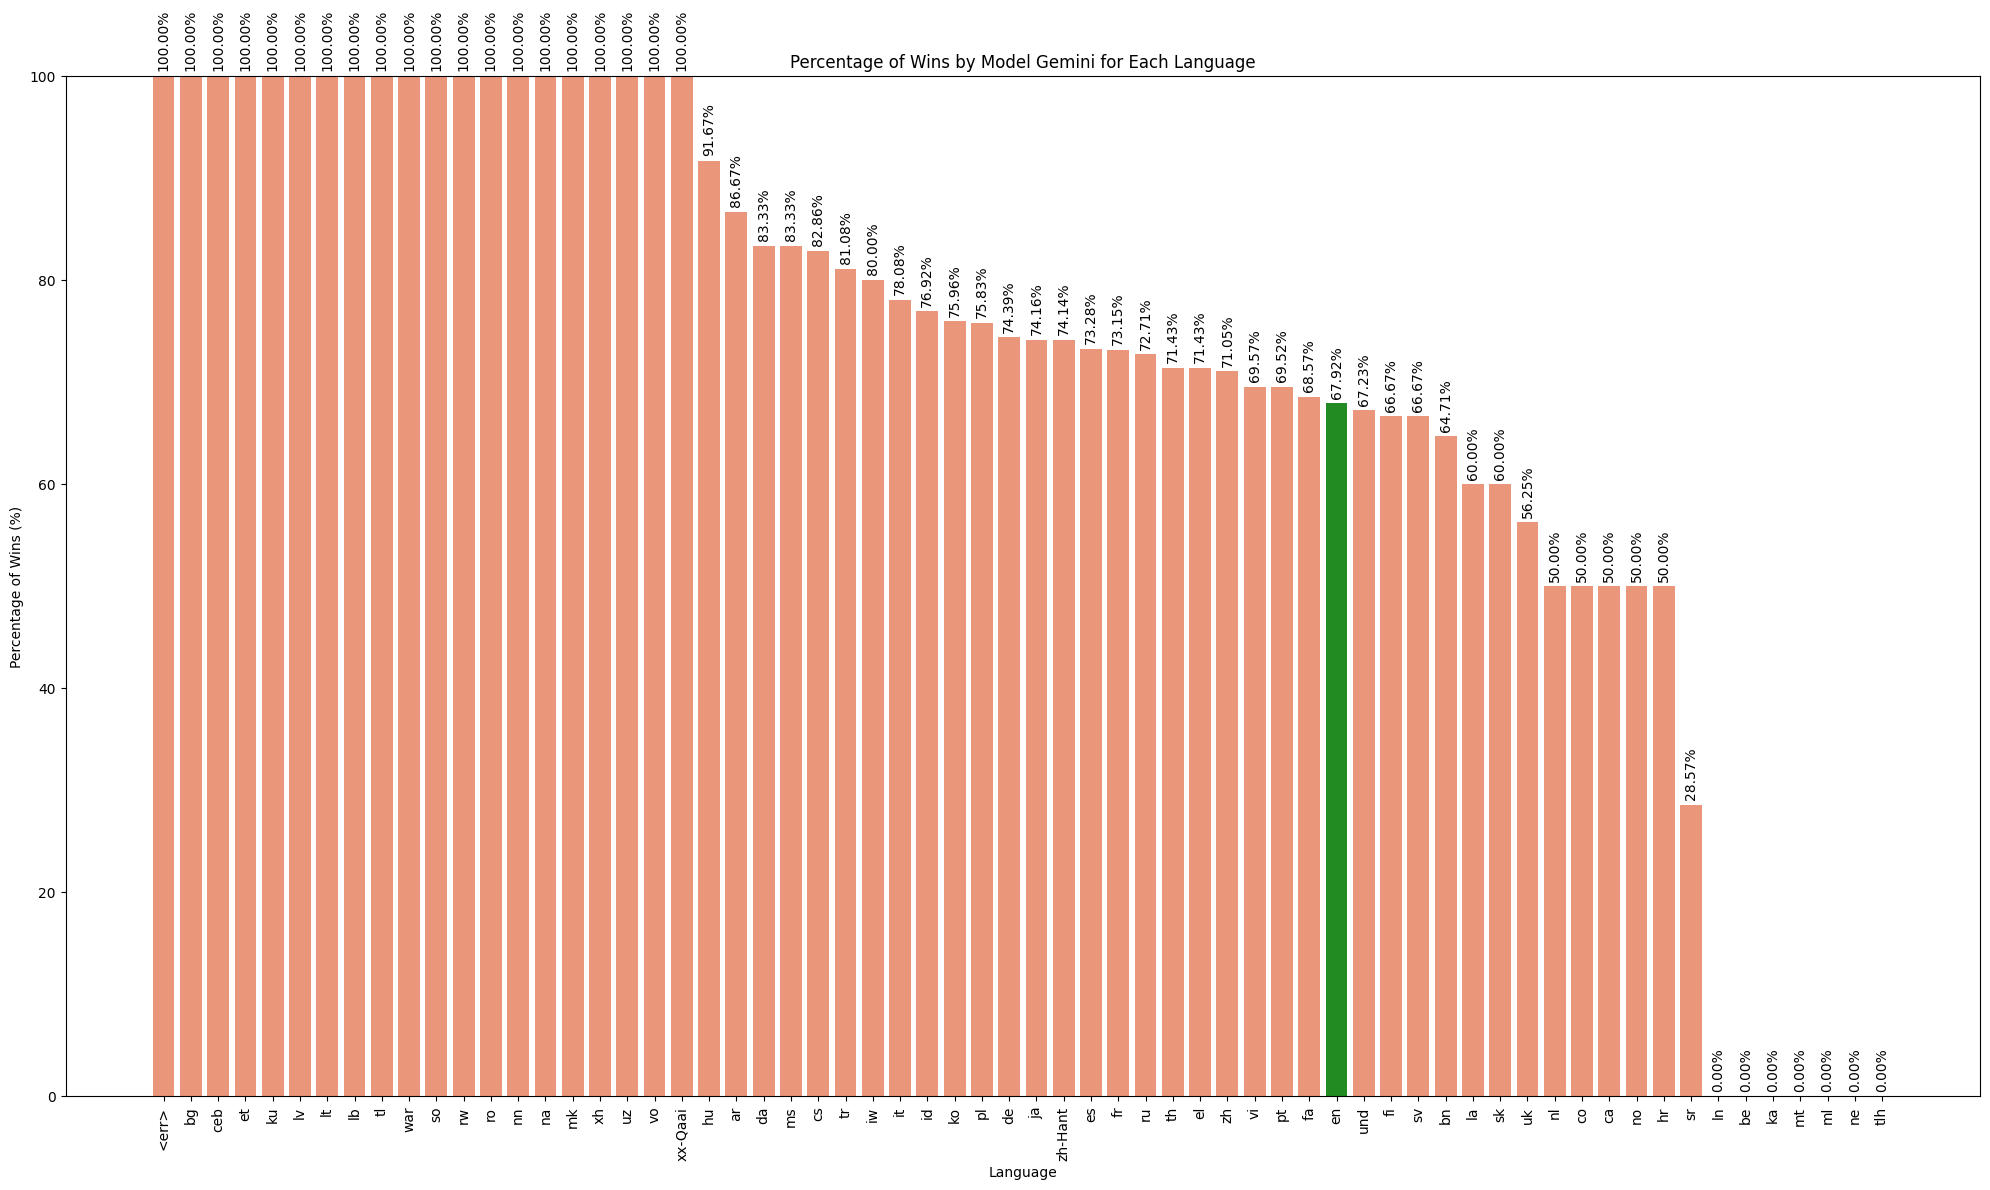

In [61]:
if 'winner' in df.columns and 'language' in df.columns:
    # Filter gemini
    model_g_wins = df[(df['winner1'].str.lower().str.startswith('gemini-2.5-pro')) | (df['winner1'] == 'tie')]

    # Group by language 
    language_counts = df.groupby('language').size()
    model_g_wins_by_language = model_g_wins.groupby('language').size()

    # Calculate the percentage
    win_percentage = (model_g_wins_by_language / language_counts) * 100
    win_percentage = win_percentage.fillna(0)  # To handle cases where model_g has 0 wins

    # Sort percentages
    win_percentage_sorted = win_percentage.sort_values(ascending=False)

    # Create a list of colors where 'en' gets a specific color, other languages have a default color
    colors = ['darksalmon' if lang != 'en' else 'forestgreen' for lang in win_percentage_sorted.index]

    # Create a bar chart with sorted data
    plt.figure(figsize=(20, 12))
    bars = plt.bar(win_percentage_sorted.index, win_percentage_sorted.values, color=colors)

    plt.title('Percentage of Wins by Model Gemini for Each Language')
    plt.xlabel('Language')
    plt.ylabel('Percentage of Wins (%)')
    plt.ylim(0, 100)
    plt.xticks(rotation=90)
    for bar in bars:
        yval = bar.get_height()  # Get the height of each bar (i.e., the percentage value)
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, f'{yval:.2f}%', 
                 ha='center', va='bottom', fontsize=10, color='black', rotation= 90)

    plt.tight_layout()
    plt.show()


<div id="Data-Cleaning-Mapping-and-Feature-Extraction">
<h2>Data Cleaning, Mapping, and Feature Extraction</h2>

<p>
In this step, we perform initial data cleaning and preprocessing.  
We remove columns and rows with no useful information, generate numeric IDs, map winners to their names and IDs, flatten nested metadata and category tags, aggregate specific counts, and filter the dataset for English language entries.  
We also create binary columns to indicate winner models and map winners to a simplified numeric scheme.
</p>
</div>

</div>

</div>

</div>


In [62]:
#Step 1
# Drop columns with only one unique value or all NaNs
# Drop rows with all NaN values and remove duplicate rows
cols_to_drop = [col for col in df.columns if df[col].nunique(dropna=True) <= 1]
df = df.drop(columns=cols_to_drop)
df = df.dropna(how='all')
df = df.drop_duplicates()
print(df.shape)

#Step 2
# Assign a numeric ID to each row
df['numeric_id'] = range(1, len(df)+1)
# Create a mapping from numeric ID to original 'id' column
id_mapping = dict(zip(df['numeric_id'], 
                      df['id']))

#Step 3
# Determine the actual winner name based on the 'winner' column
def get_winner_name(row):
    if row['winner'] == 'model_a':
        return row['model_a']
    elif row['winner'] == 'model_b':
        return row['model_b']
    else:
        return row['winner']  

df['winner_name'] = df.apply(get_winner_name, axis=1)

#Step 4
# Create unique IDs for each model
unique_models = list(pd.unique(df[['model_a', 'model_b', 'winner_name']].values.ravel()))
model_id_mapping = {model: idx+1 for idx, model in enumerate(unique_models)}
# Map winner names to numeric IDs
df['winner_id'] = df['winner_name'].map(model_id_mapping)

#Step 5
# Flatten nested 'conv_metadata' dictionaries into separate columns
def flatten_metadata(row):
    meta = ast.literal_eval(row['conv_metadata'])
    flat = {}
    for key, value in meta.items():
        if isinstance(value, dict):
            for subkey, subval in value.items():
                flat[f"{key}_{subkey}"] = subval
        else:
            flat[key] = value
    return pd.Series(flat)

conv_meta_flat = df.apply(flatten_metadata, axis=1)
df = pd.concat([df, conv_meta_flat], axis=1)
#df.drop(columns=['conv_metadata'], inplace=True)

#Step 6
# Aggregate header, list, and bold counts for model_a and model_b
df['sum_header_count_a'] = df[['header_count_a_h1','header_count_a_h2','header_count_a_h3',
                               'header_count_a_h4','header_count_a_h5','header_count_a_h6']].sum(axis=1)
df['sum_list_count_a'] = df[['list_count_a_ordered','list_count_a_unordered']].sum(axis=1)
df['sum_bold_count_a'] = df[['bold_count_a_**','bold_count_a___']].sum(axis=1)

df['sum_header_count_b'] = df[['header_count_b_h1','header_count_b_h2','header_count_b_h3',
                               'header_count_b_h4','header_count_b_h5','header_count_b_h6']].sum(axis=1)
df['sum_list_count_b'] = df[['list_count_b_ordered','list_count_b_unordered']].sum(axis=1)
df['sum_bold_count_b'] = df[['bold_count_b_**','bold_count_b___']].sum(axis=1)
# Create unified context_tokens column
df['context_tokens'] = df[['context_a_tokens', 'context_b_tokens']].max(axis=1)

#Step 7
# Flatten nested 'category_tag' dictionaries into separate columns, converting boolean to int
def flatten_category_tag(row):
    cat = ast.literal_eval(row['category_tag'])
    flat = {}
    for key, value in cat.items():
        for subkey, subval in value.items():
            if isinstance(subval, bool):
                flat[f"{key}_{subkey}"] = int(subval)
            else:
                flat[f"{key}_{subkey}"] = subval
    return pd.Series(flat)

category_flat = df.apply(flatten_category_tag, axis=1)
df = pd.concat([df, category_flat], axis=1)
#df.drop(columns=['category_tag'], inplace=True)

#Step 8
# Convert specific columns to integer type
df['gemini_in_a'] = df['gemini_in_a'].astype(int)
df['gemini_in_b'] = df['gemini_in_b'].astype(int)
df['is_code'] = df['is_code'].astype(int)

#Step 9
# Keep only English language rows
df = df[df['language'] == 'en']

#Step 10
# Map winner names to simplified numeric categories
# 1 = Gemini, 2 = Other Model, 3 = Tie, 4 = Both Bad
def map_winner(row):
    if 'gemini-2.5-pro' in row['winner_name'].lower():
        return 1
    elif row['winner_name'] == 'tie':
        return 3
    elif row['winner_name'] == 'both_bad':
        return 4
    else:
        return 2

df['winner_mapped'] = df.apply(map_winner, axis=1)

#Step 11
# Create binary columns 'a' and 'b' indicating which model won
df['a'] = 0
df['b'] = 0
df.loc[df['winner'] == 'model_a', 'a'] = 1
df.loc[df['winner'] == 'model_b', 'b'] = 1
df.loc[df['winner'] == 'tie', ['a','b']] = 1
df.loc[df['winner'] == 'both_bad', ['a','b']] = 0

#Step 12
# Select final subset of columns for analysis
df_final = df[[
    'id', 'numeric_id', 'winner_name', 'winner_id', 'a', 'b',
    'sum_assistant_a_tokens', 'sum_header_count_a', 'sum_list_count_a',
    'sum_bold_count_a', 'sum_assistant_b_tokens', 'sum_header_count_b',
    'sum_list_count_b', 'sum_bold_count_b',
    'context_tokens',
    'creative_writing_v0.1_creative_writing',
    'creative_writing_v0.1_score',
    'criteria_v0.1_complexity',
    'criteria_v0.1_creativity',
    'criteria_v0.1_domain_knowledge',
    'criteria_v0.1_problem_solving',
    'criteria_v0.1_real_world',
    'criteria_v0.1_specificity',
    'criteria_v0.1_technical_accuracy',
    'if_v0.1_if',
    'if_v0.1_score',
    'math_v0.1_math',
    'winner_mapped', 'is_code',
    'response_a','response_b','conversation_a','conversation_b'
]]

df_final = df_final.copy()

# Create binary target: 1 if Gemini won, else 0
df_final.loc[:, 'gemini_win'] = df_final['winner_mapped'].isin([1, 3]).astype(int)


(9438, 21)


In [63]:
gemini_wins_counts = df[df['winner_name'].str.contains('gemini', case=False)]['winner_name'].value_counts()
print(gemini_wins_counts)


winner_name
gemini-2.5-pro                                  1738
gemini-2.5-pro-preview-05-06                     555
gemini-2.5-pro-preview-03-25                     345
gemini-2.5-flash                                  38
gemini-2.0-flash-001                              26
gemini-2.5-flash-preview-04-17                    20
gemini-2.5-flash-lite-preview-06-17-thinking      14
gemini-2.0-flash-thinking-exp-01-21                3
Name: count, dtype: int64


In [64]:
df_final.iloc[0]

id                                                     c4b9710c-8d64-4bee-a0b0-94637ae4cc65
numeric_id                                                                                1
winner_name                                                                  gemini-2.5-pro
winner_id                                                                                 1
a                                                                                         1
b                                                                                         0
sum_assistant_a_tokens                                                                 1854
sum_header_count_a                                                                        8
sum_list_count_a                                                                         39
sum_bold_count_a                                                                         65
sum_assistant_b_tokens                                                          

### checking emojis with regex

In [65]:
import re
checking_emojis = ['response_a', 'response_b']
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emojis face
    "\U0001F300-\U0001F5FF"  # symbols & pictograms
    "\U0001F680-\U0001F6FF"  # symbols transport & ...
    "\U0001F700-\U0001F77F"  # symbols chemical
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\U00002700-\U000027BF"  # symbols sundry like ✔✖
    "\U00002600-\U000026FF"  # symbols weather signs different ☀☔
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"  # dingbats
	"\U000024C2-\U0001F251"  # enclosed characters
    "]+",
    flags=re.UNICODE
)

for checking_emoji in checking_emojis:
    col = df_final[checking_emoji].astype(str)
    has_emoji_mask = col.str.contains(emoji_pattern)
    has_emoji = has_emoji_mask.any()
    print(f'\n{checking_emoji} column has emojis? {has_emoji}')

    if has_emoji:
        df_final[checking_emoji + '_emoji_count'] = (
            df_final[checking_emoji]
            .astype(str)
            .str.findall(emoji_pattern)
            .str.len()
        )
        print('column created')
    else:
        print('column not created!')


response_a column has emojis? True
column created

response_b column has emojis? True
column created


### checking tables

In [66]:
from typing import Any
import math


def _is_nan(value: Any) -> bool:
	"""
	Best-effort NaN detection without heavy dependencies.
	"""
	if value is None:
		return True
	if isinstance(value, float):
		return math.isnan(value)
	return False


def detectTables(text: Any) -> bool:
	"""
	Detect table-like structures: Markdown and HTML.
	"""
	if _is_nan(text):
		return False
	s = str(text)
	if not s:
		return False
	# Markdown tables: at least three columns separated by pipes on a line
	if re.search(r"\|.*\|.*\|", s, re.MULTILINE):
		return True
	# HTML tables: presence of typical tags
	if re.search(r"<table|<tr|<td|<th", s, re.IGNORECASE):
		return True
	return False


__all__ = ["detectTables"]

checking_tables = ['response_a', 'response_b']
for checking_table in checking_tables:
	df_final[checking_table] = df_final[checking_table].astype(str)
	has_table =  df_final[checking_table].apply(detectTables).any()
	print(f'\n{checking_table} column has tables? {has_table}')
	df_final[checking_table + '_table_count'] = df_final[checking_table].apply(
    	lambda x: len(re.findall(r"(\|.*\|.*\|)", x)) + len(re.findall(r"<table|<tr|<td|<th", x)) if detectTables(x) else 0
    )	
	print('column created!')


response_a column has tables? True
column created!

response_b column has tables? True
column created!


### analyzing writing style

In [67]:
from typing import Dict
def _is_nan(value: Any) -> bool:
	"""
	Best-effort NaN detection without heavy dependencies.
	"""
	if value is None:
		return True
	if isinstance(value, float):
		return math.isnan(value)
	return False


def analyzeWritingStyle(text: Any) -> Dict[str, float]:
	"""
	Analyze writing style and return metrics.
	"""
	if _is_nan(text):
		return {
			"is_detailed": False,
			"word_count": 0,
			"sentence_count": 0,
			"avg_words_per_sentence": 0.0,
		}
	s = str(text)
	if not s:
		return {
			"is_detailed": False,
			"word_count": 0,
			"sentence_count": 0,
			"avg_words_per_sentence": 0.0,
		}
	words = s.split()
	sentences = re.split(r"[.!?]+\s+", s)
	sentences = [seg for seg in sentences if seg.strip()]
	word_count = len(words)
	sentence_count = len(sentences) if sentences else 1
	avg_wps = (word_count / sentence_count) if sentence_count > 0 else 0.0
	is_detailed = (avg_wps > 15) and (word_count > 50)
	return {
		"is_detailed": is_detailed,
		"word_count": word_count,
		"sentence_count": sentence_count,
		"avg_words_per_sentence": avg_wps,
	}


__all__ = ["analyzeWritingStyle"]

checking_styles = ['response_a', 'response_b']
for checking_style in checking_styles:
    df_final[checking_style + '_writing_style'] = df_final[checking_style].apply(analyzeWritingStyle)
    df_final[checking_style + '_is_detailed'] = df_final[checking_style + '_writing_style'].apply(lambda x: x['is_detailed'])
    df_final[checking_style + '_word_count'] = df_final[checking_style + '_writing_style'].apply(lambda x: x['word_count'])
    df_final[checking_style + '_sentence_count'] = df_final[checking_style + '_writing_style'].apply(lambda x: x['sentence_count'])
    df_final[checking_style + '_avg_words_per_sentence'] = df_final[checking_style + '_writing_style'].apply(lambda x: x['avg_words_per_sentence'])
    print(f'columns created for {checking_style}')


columns created for response_a
columns created for response_b


### count (deliminators / sentences / punctuations)

In [68]:
import string
from nltk.tokenize import sent_tokenize
def safe_text(x):
    """Ensures input is a string, converting non-string values to an empty string."""
    if isinstance(x, str):
        return x
    return ""
def count_code_delimiters(text):
    """Counts the number of Markdown code block delimiters (```). 
    This is often used as a feature proxy for the presence of code.
    """
    text = safe_text(text)
    return text.count("```")

def count_sentences_robust(text):
    """Uses NLTK's sent_tokenize for accurate sentence counting, 
    handling abbreviations, etc. better than simple regex.
    """
    text = safe_text(text)
    if not text.strip():
        return 0
    try:
        # sent_tokenize splits text into sentences
        return len(sent_tokenize(text))
    except LookupError:
        # Handles case where punkt is not downloaded
        return len(re.findall(r'[.!?]+', text))
    except:
        # General safety net
        return 0 

def count_punct_comprehensive(text):
    """Counts the total number of characters in the comprehensive string.punctuation set."""
    text = safe_text(text)
    # Counts any character found in the standard string.punctuation set
    return sum(1 for c in text if c in string.punctuation)
# --- 6. Applying the Functions to your DataFrame (df_final) ---



# List of columns to analyze
target_columns = ['response_a', 'response_b']

# Dictionary of functions to apply, with desired new column suffixes
feature_functions = {
    'count_code_delimiters': count_code_delimiters,
    'count_sentences_robust': count_sentences_robust,
    'count_punct_comprehensive': count_punct_comprehensive,
}

# Loop through each target column and apply all feature functions
for col in target_columns:
    for suffix, func in feature_functions.items():
        # Create the new column name (e.g., 'response_a_emoji_count')
        new_col_name = f'{col}_{suffix}'
        
        # Apply the function to the specified column of your df1
        df_final[new_col_name] = df_final[col].apply(func)
        print(f'{new_col_name} is created! for {col}')

response_a_count_code_delimiters is created! for response_a
response_a_count_sentences_robust is created! for response_a
response_a_count_punct_comprehensive is created! for response_a
response_b_count_code_delimiters is created! for response_b
response_b_count_sentences_robust is created! for response_b
response_b_count_punct_comprehensive is created! for response_b


<div id="Plot-1-Gemini-Win-Loss-Analysis">
<h2>Plot 1:  Gemini Win/Loss Analysis</h2>

<p>
In this step, we analyze the overall performance of the Gemini model by comparing its win and loss counts across all matches.  
We calculate the total number of matches, determine how many were wins or losses (including ties), compute the corresponding percentages, and visualize the results using a bar chart.  
This provides a quick overview of Gemini’s general effectiveness in comparison to other models.
</p>
</div>


Gemini win percentage: 67.92%
Gemini loss percentage: 32.08%


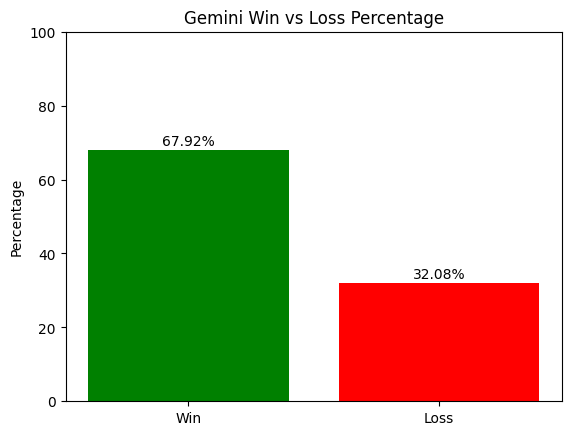

In [69]:
# Count the total number of matches in the dataset
total_matches = len(df_final)

# Count matches where Gemini won (winner_mapped == 1) or tied (winner_mapped == 3)
gemini_wins = df_final[df_final['winner_mapped'].isin([1, 3])].shape[0]

# Calculate Gemini win percentage
gemini_win_percentage = gemini_wins / total_matches * 100
print(f"Gemini win percentage: {gemini_win_percentage:.2f}%")

# Count matches where Gemini lost (winner_mapped == 2 or 4)
gemini_losses = df_final[df_final['winner_mapped'].isin([2, 4])].shape[0]

# Calculate Gemini loss percentage
gemini_loss_percentage = gemini_losses / total_matches * 100
print(f"Gemini loss percentage: {gemini_loss_percentage:.2f}%")

# Prepare data for bar chart visualization
labels = ['Win', 'Loss']
percentages = [gemini_win_percentage, gemini_loss_percentage]

# Create a bar chart showing Gemini's win vs loss percentage
bars = plt.bar(labels, percentages, color=['green', 'red'])
plt.ylabel('Percentage')
plt.title('Gemini Win vs Loss Percentage')
plt.ylim(0, 100)
for bar in bars:
        yval = bar.get_height()  # Get the height of each bar (i.e., the percentage value)
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, f'{yval:.2f}%', 
                 ha='center', va='bottom', fontsize=10, color='black')
plt.show()


<div id="Plot-2-Correlation-Analysis-of-Numeric-Features">
<h2>Plot 2: Correlation Analysis of Numeric Features</h2>

<p>
In this step, we examine the relationships among all numeric features using a correlation matrix and visualize it with a heatmap.  
This analysis helps identify potential multicollinearity and feature dependencies before modeling.  
At this stage, the winner model information is <strong>not yet considered</strong>; the purpose is purely exploratory — to observe general feature correlations across the dataset.
</p>
</div>


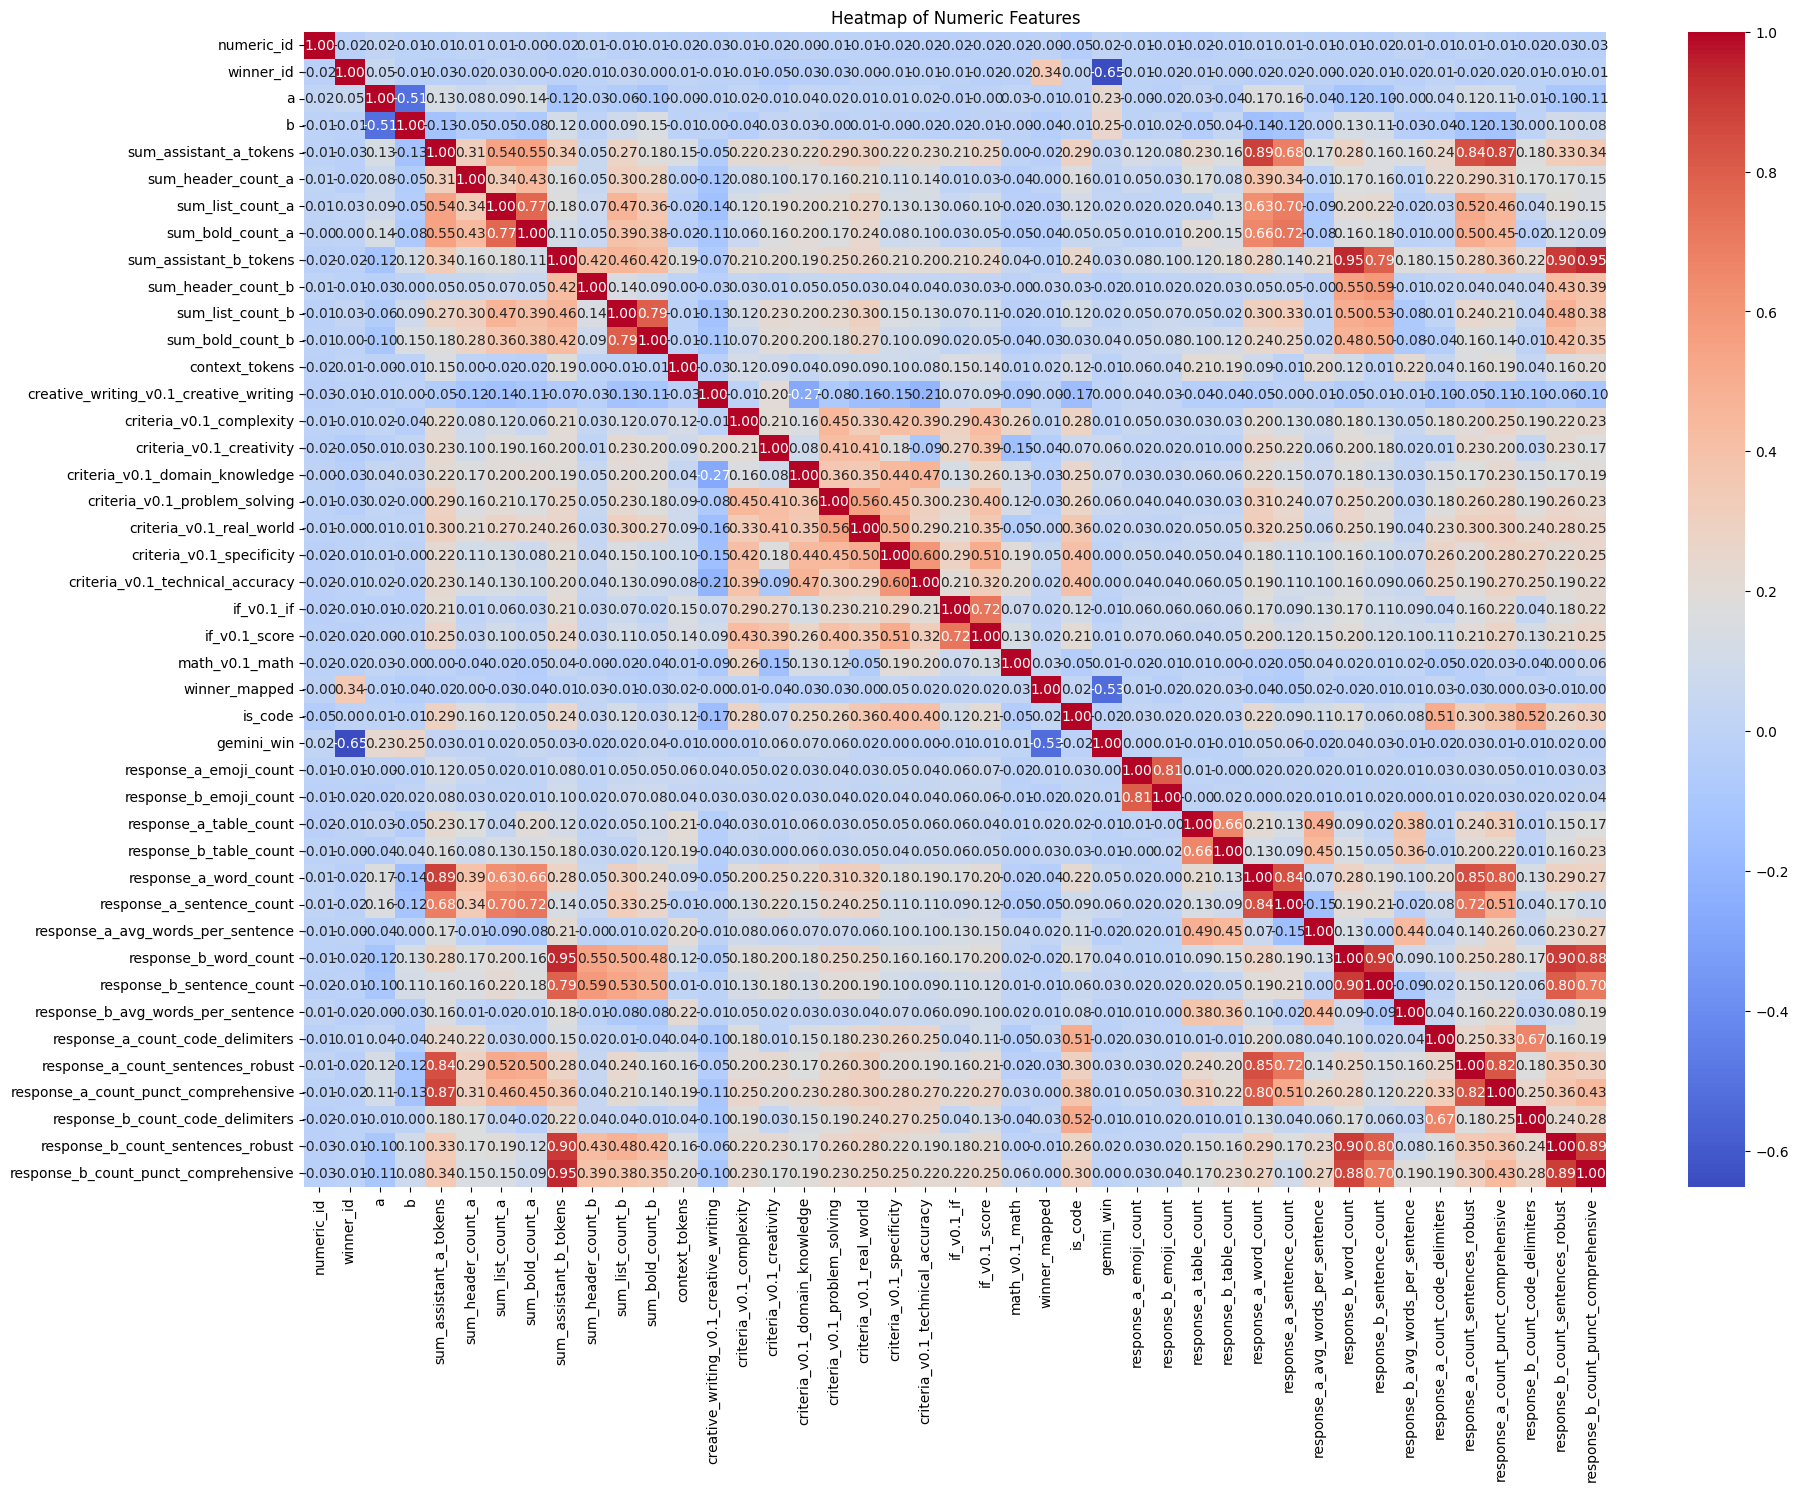

In [70]:
# Select only numeric columns for correlation analysis
numeric_cols = df_final.select_dtypes(include=['int64', 'float64']).columns

# Compute the correlation matrix among numeric features
corr_matrix = df_final[numeric_cols].corr()

# Plot a heatmap to visualize feature correlations
plt.figure(figsize=(21, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Heatmap of Numeric Features')
plt.show()


<div id="Plot-3-Feature-Distribution-Exploration">
<h2>Plot 3: Feature Distribution Exploration</h2>

<p>
In this step, we visualize the overall distributions of key numerical features across the dataset using histograms and boxplots.  
The goal is to gain a general understanding of how each feature behaves (e.g., skewness, outliers, or spread).  
At this stage, the <strong>winner model is not yet incorporated</strong> into the analysis — the exploration remains broad and unspecific.  
In the next steps, we will refine these analyses by comparing the distributions for each winner category and model-related characteristics.
</p>
</div>

</div>


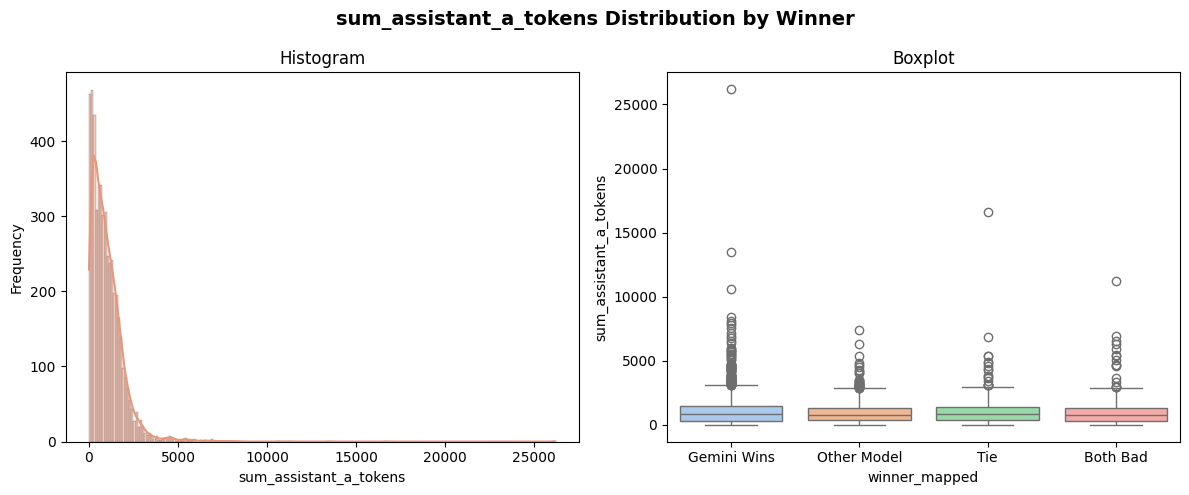

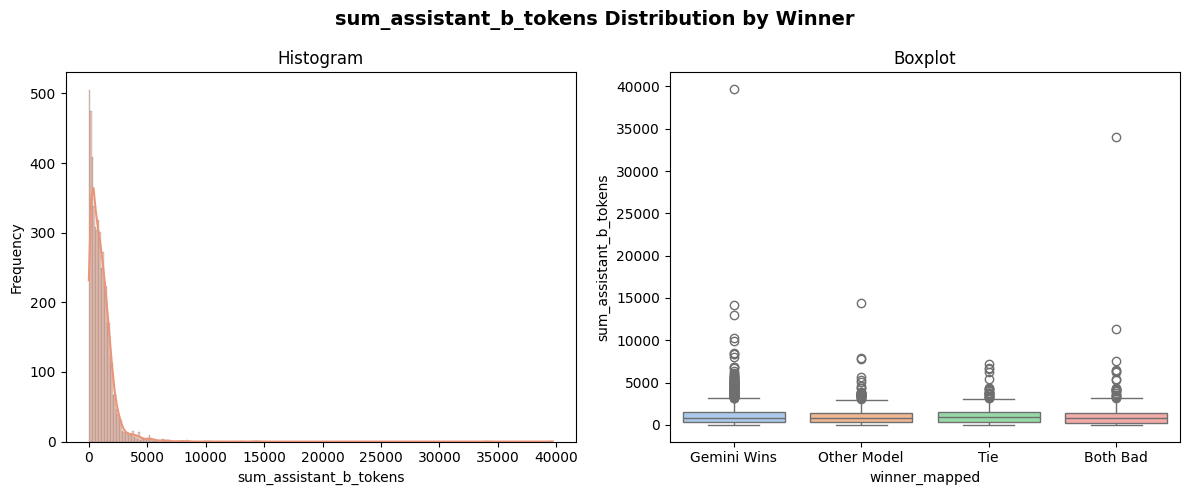

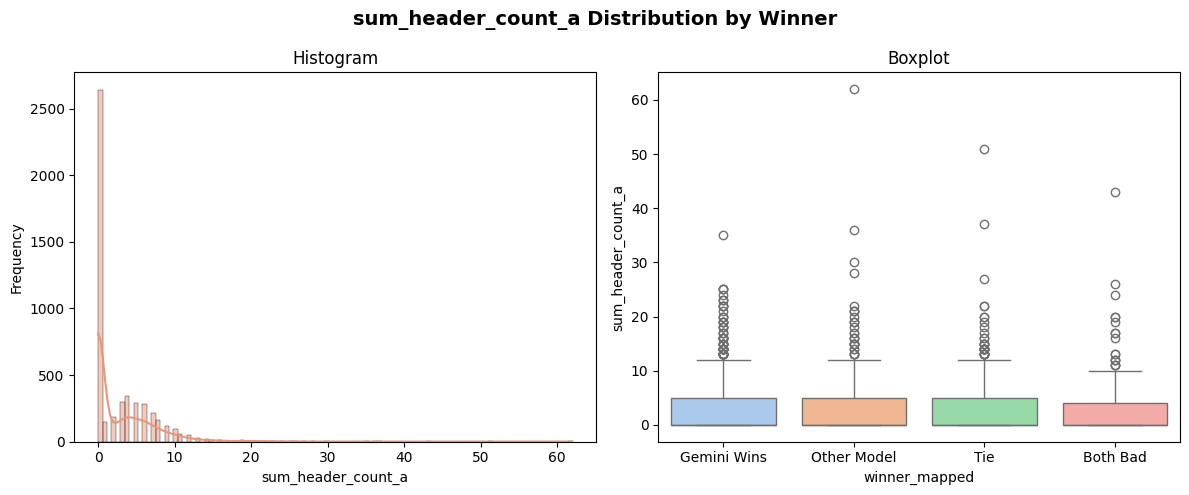

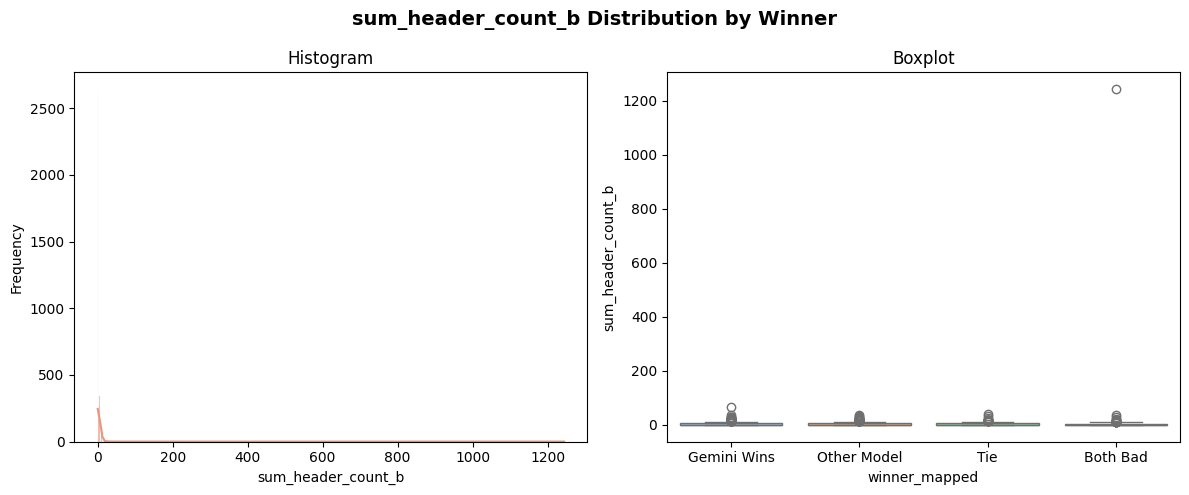

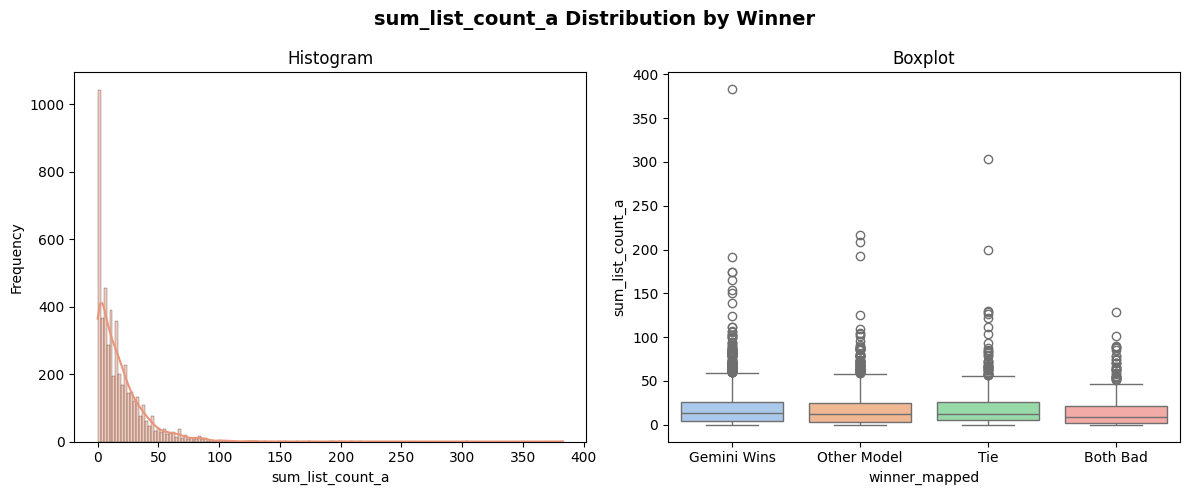

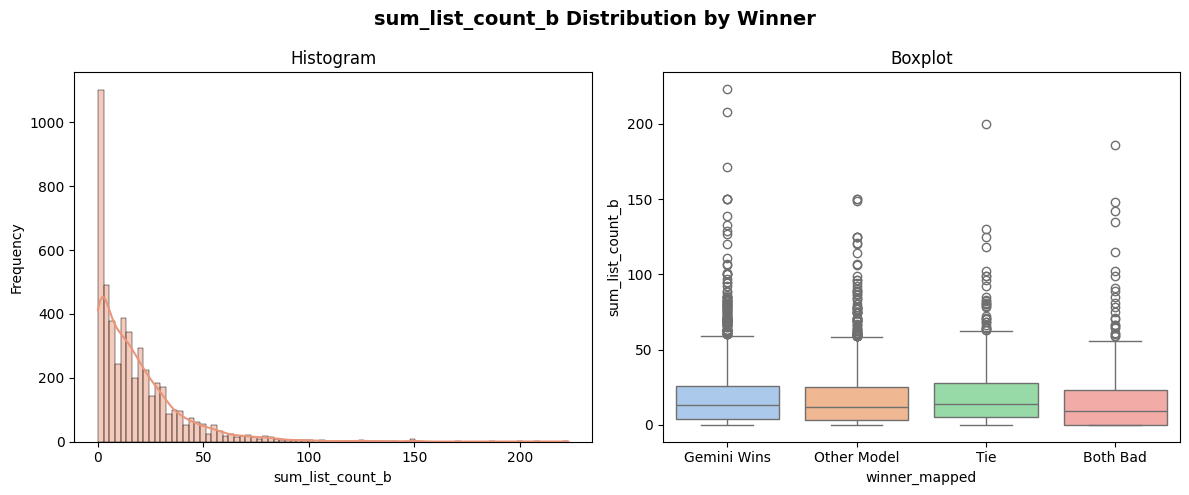

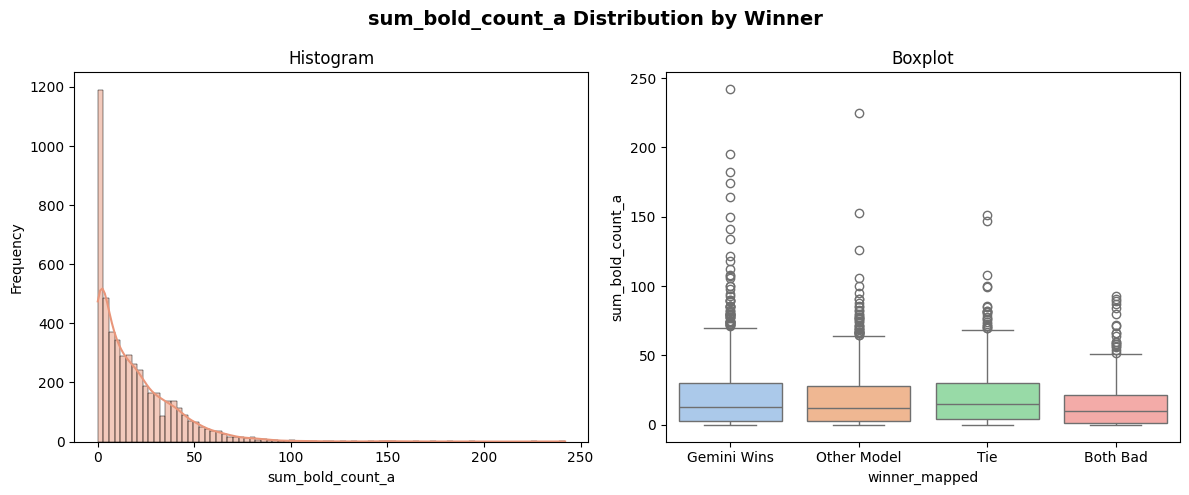

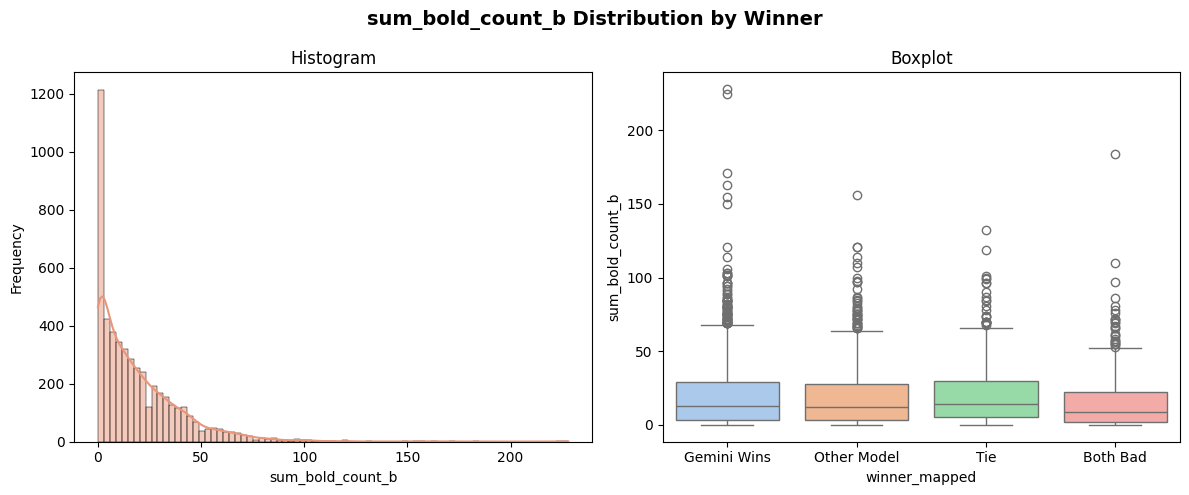

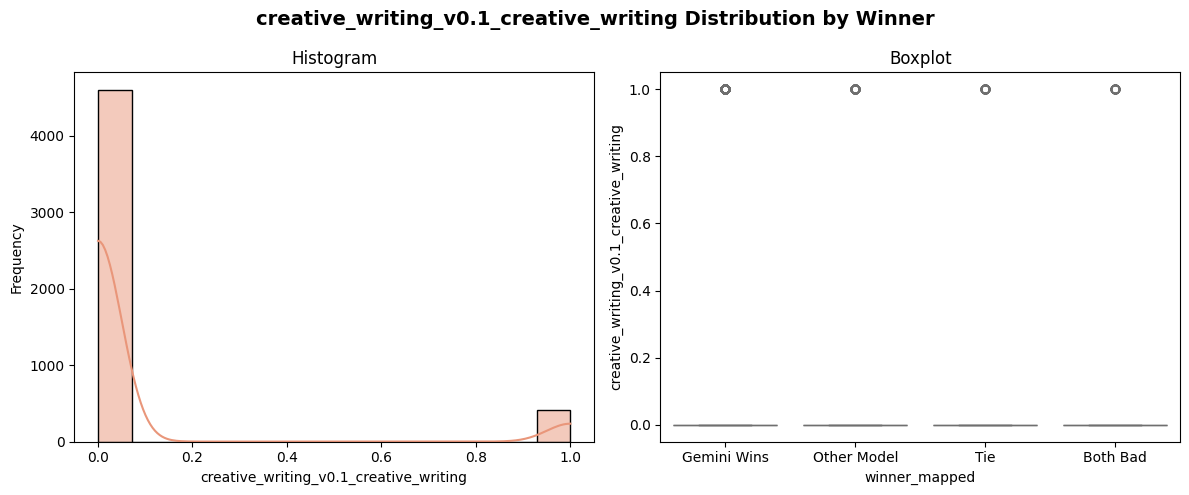

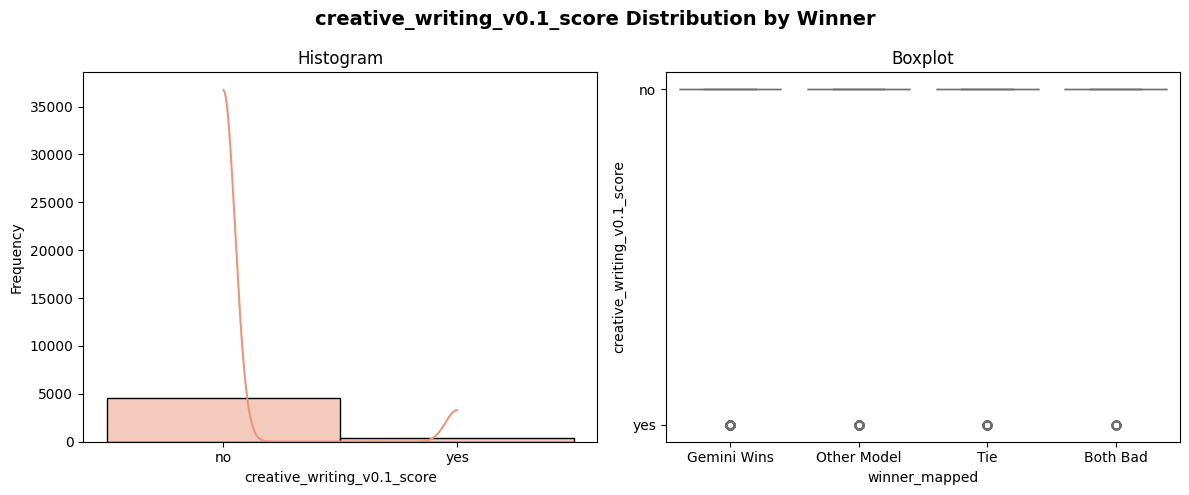

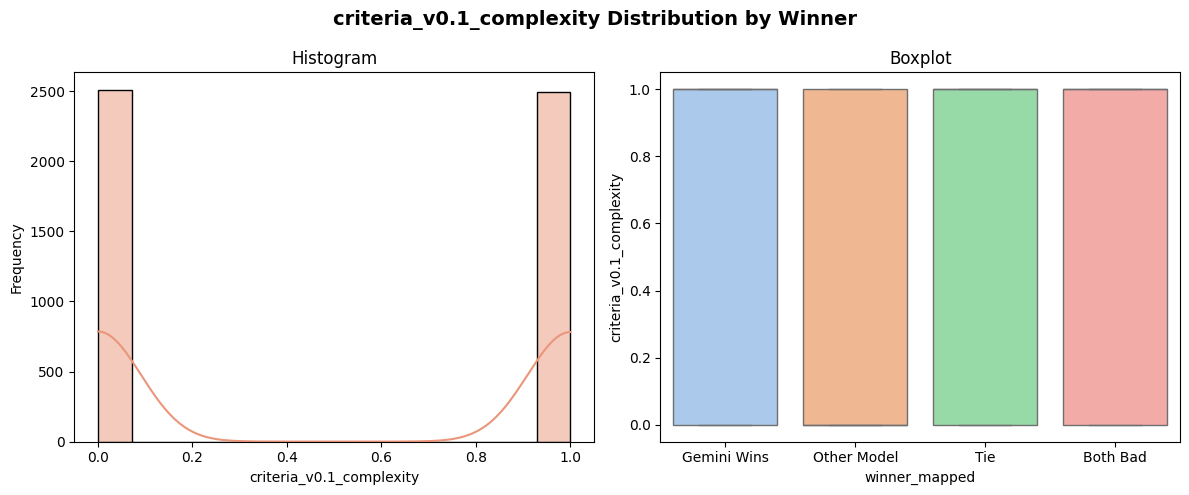

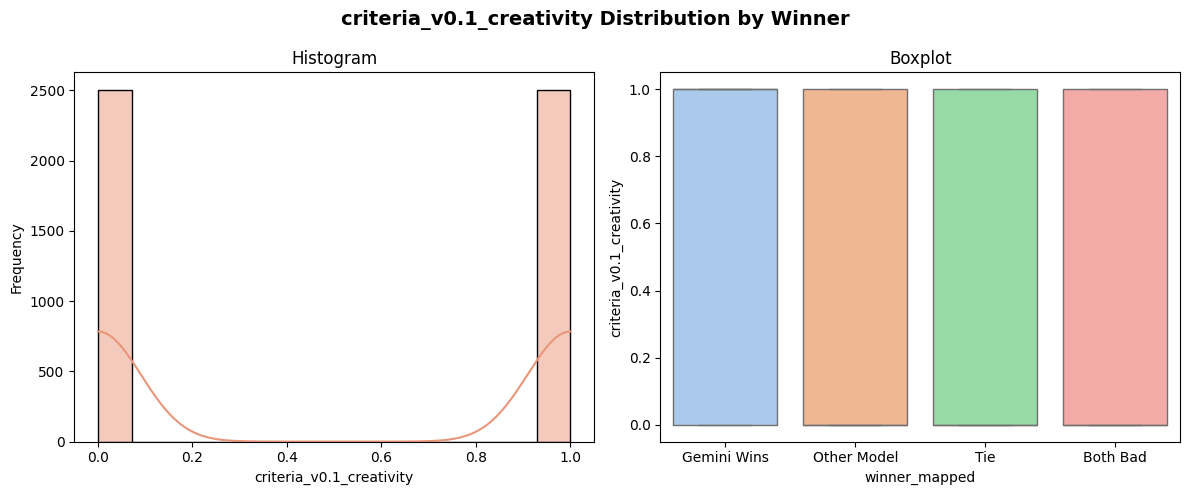

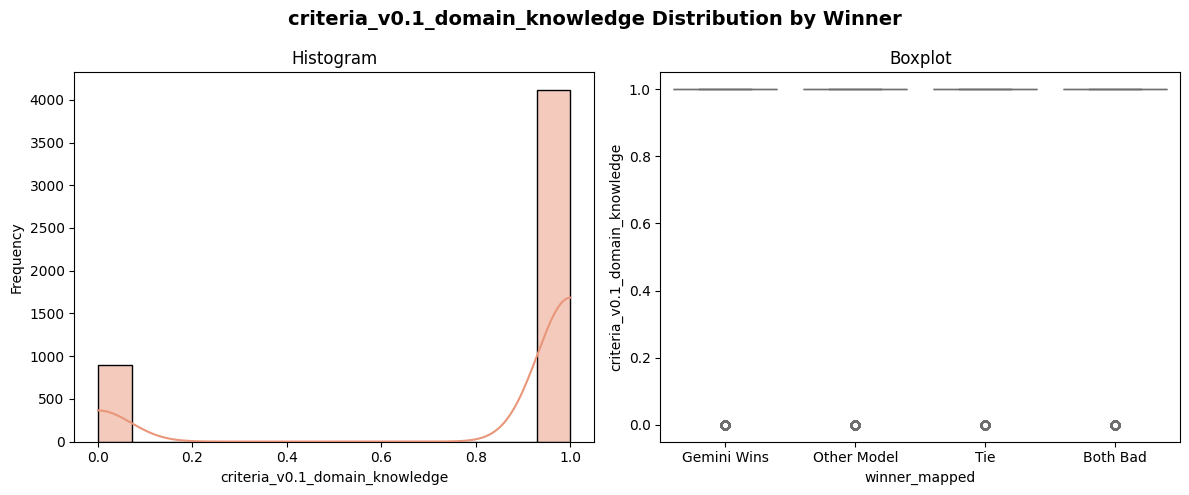

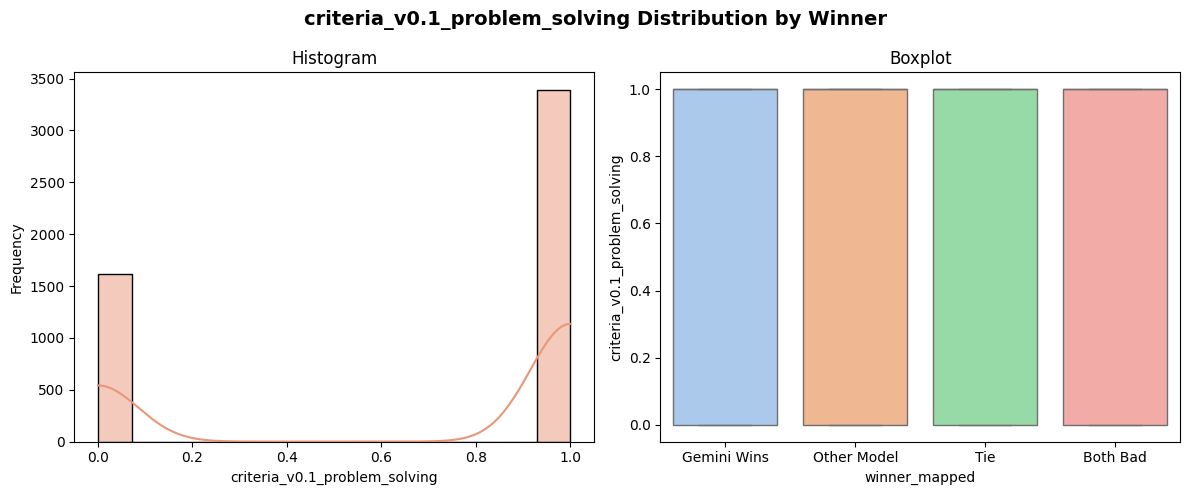

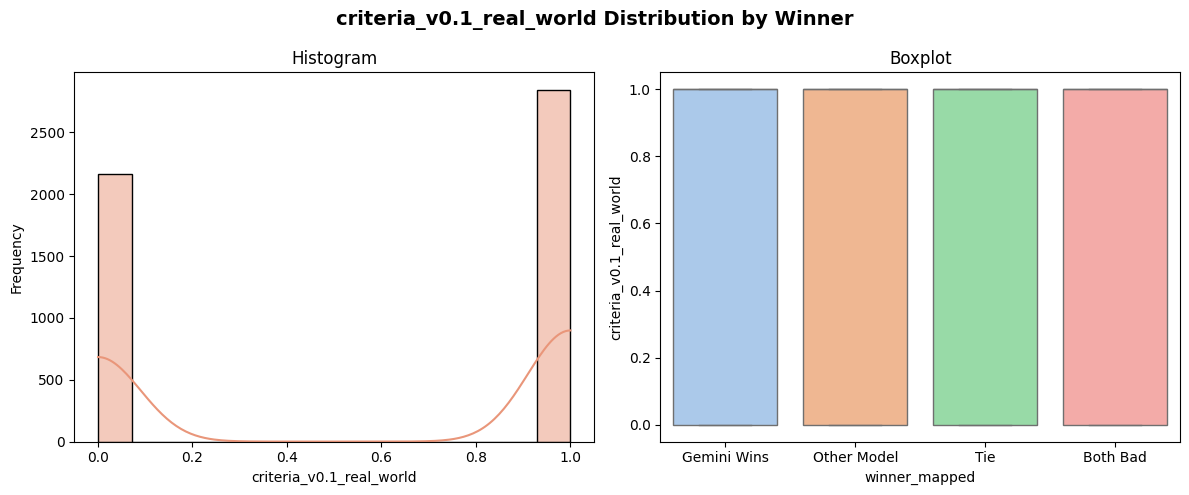

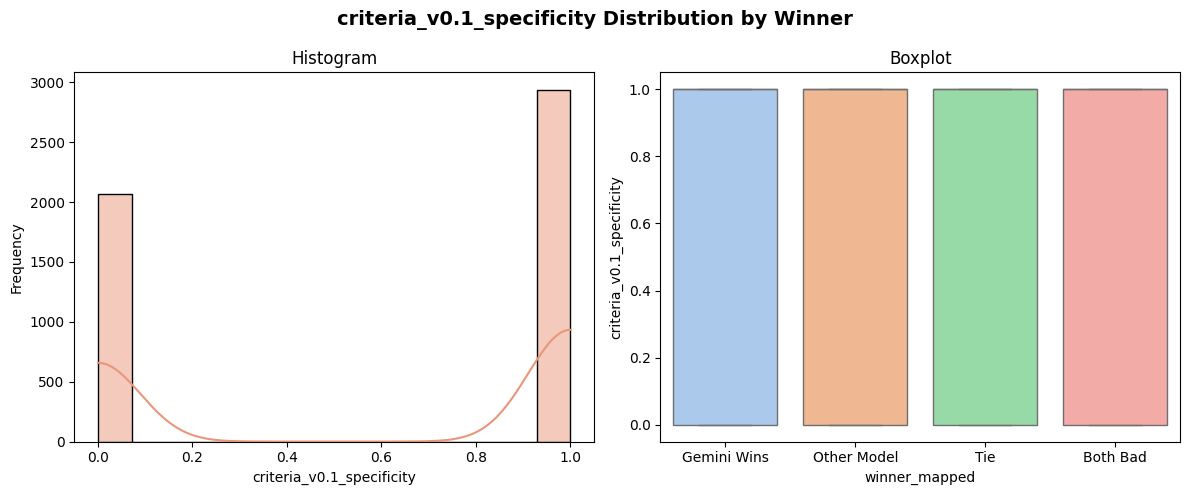

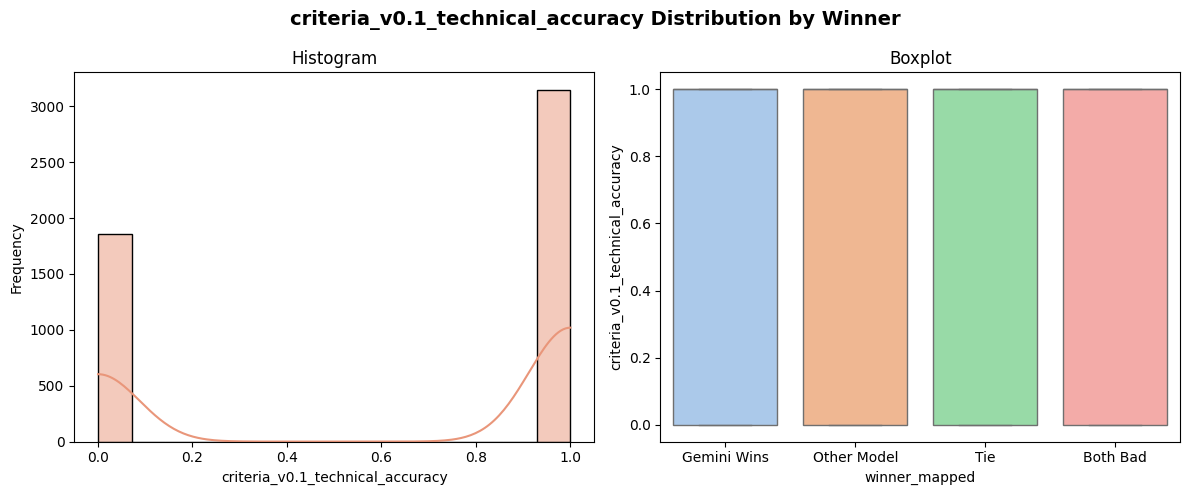

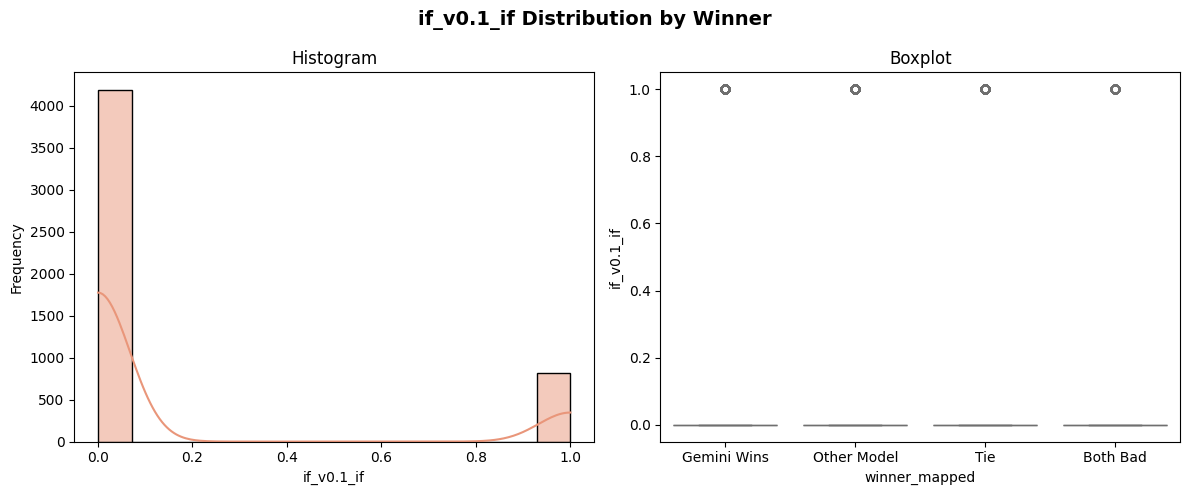

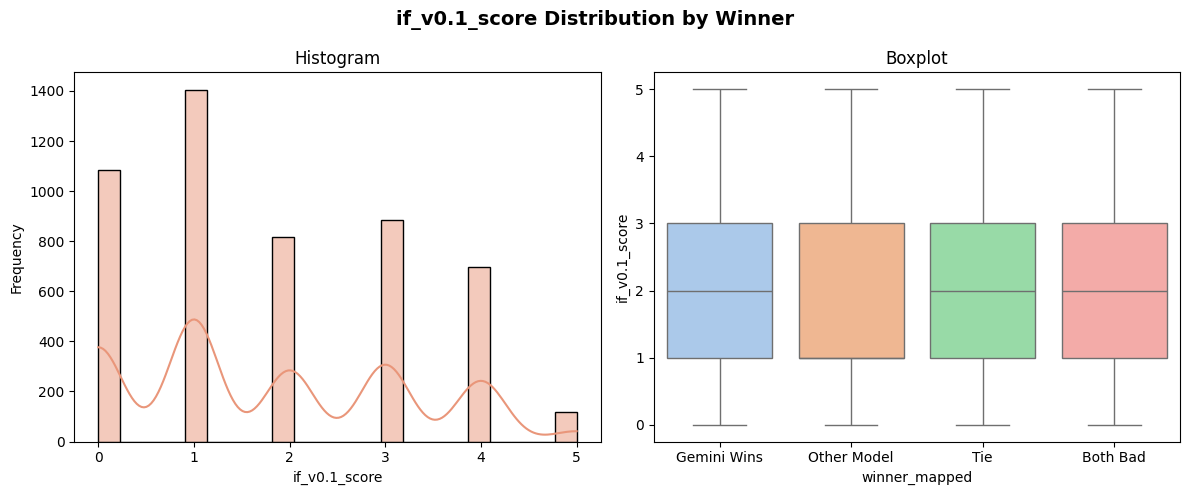

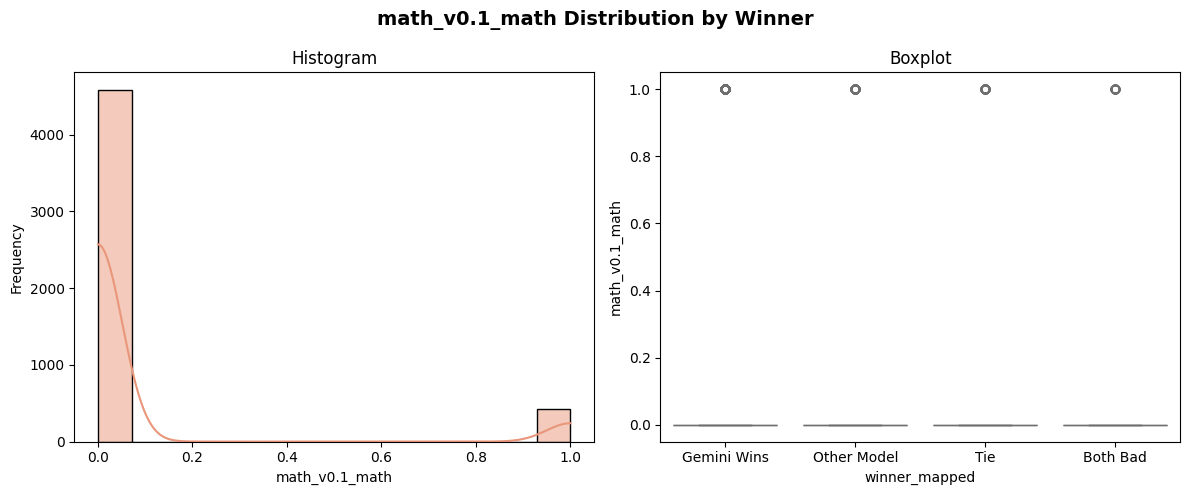

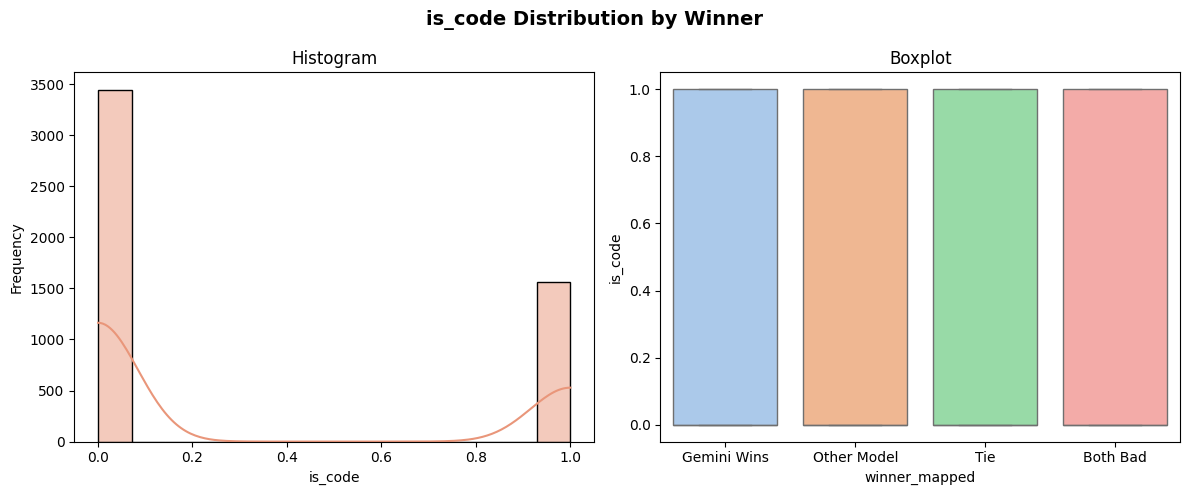

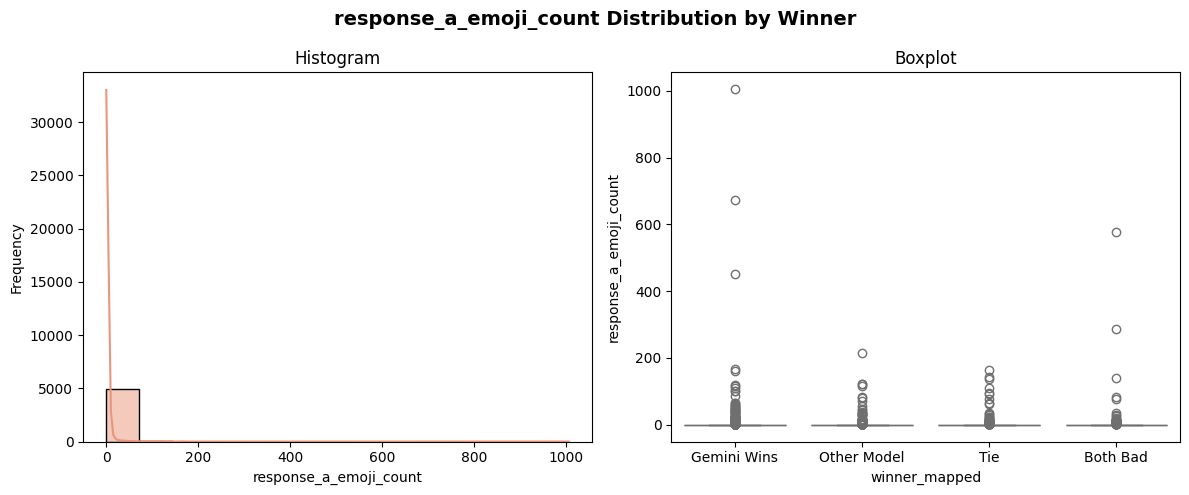

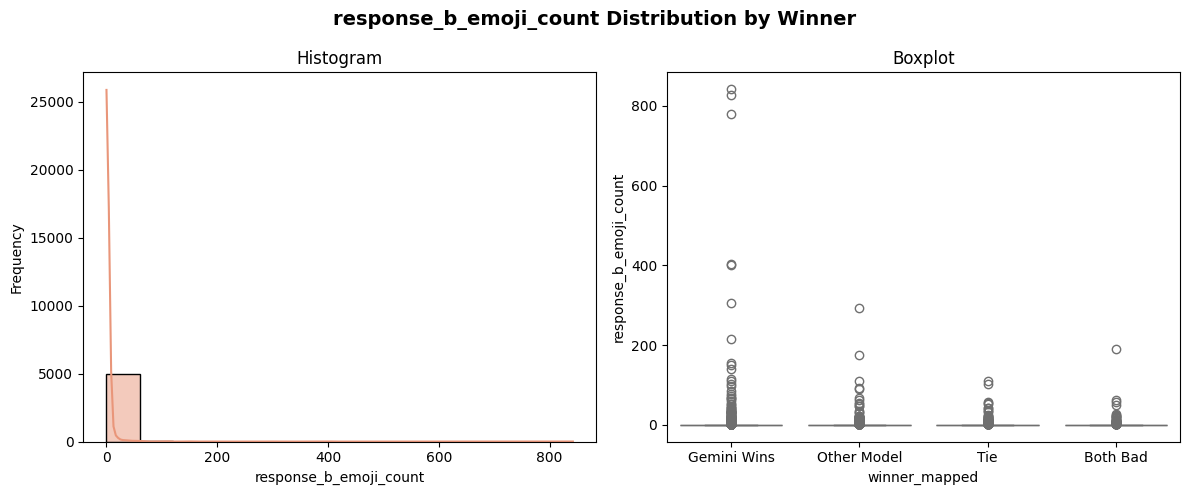

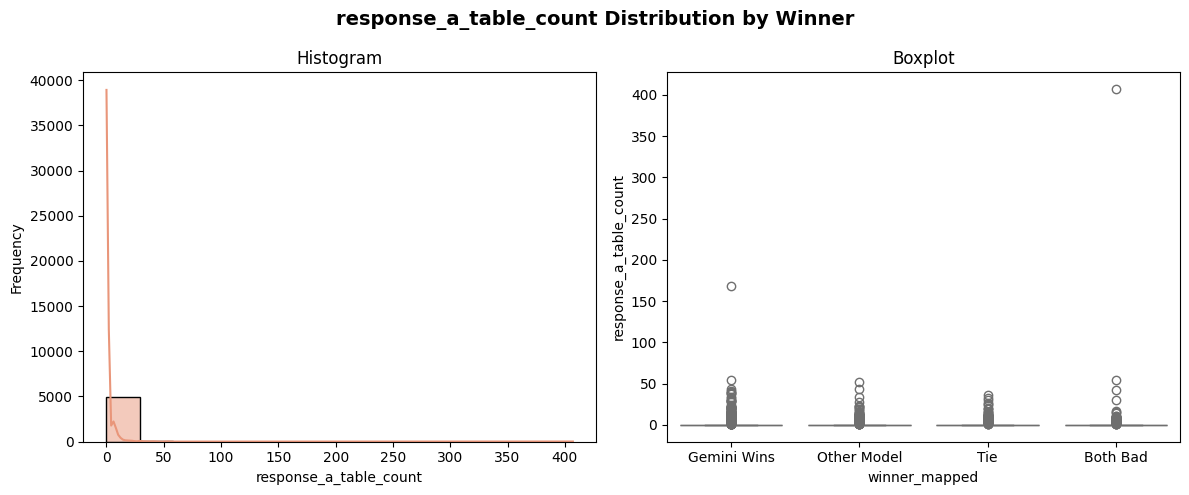

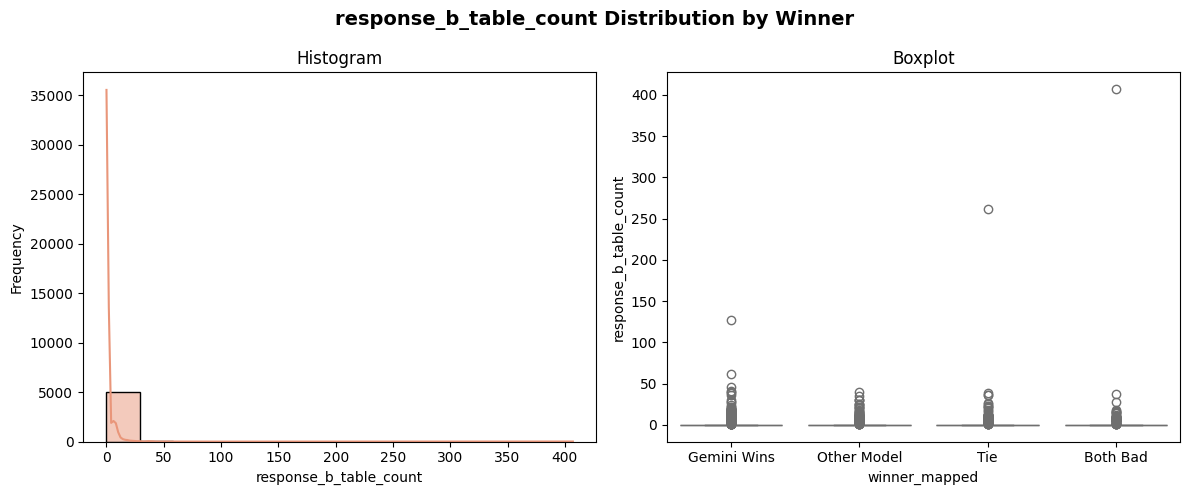

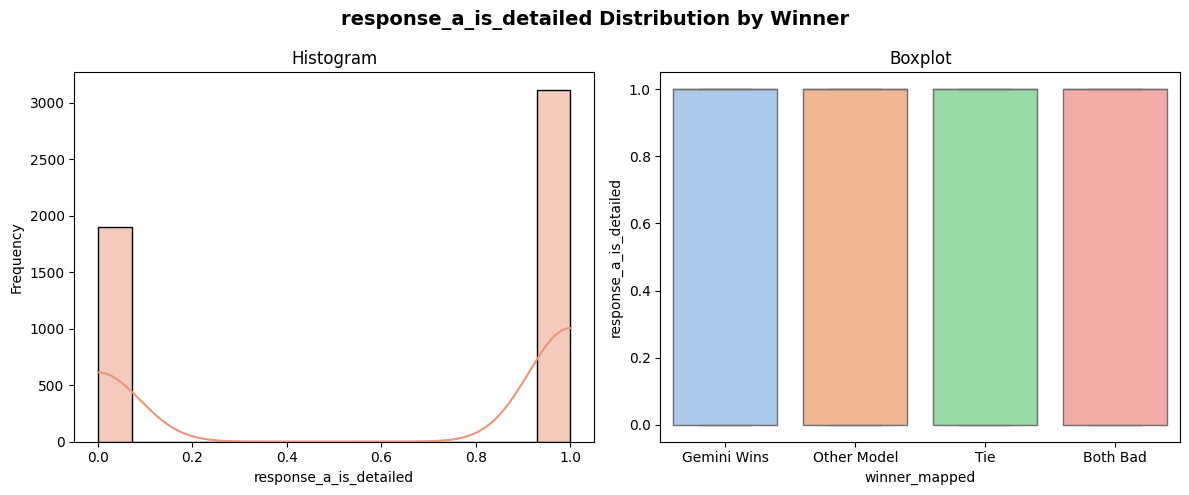

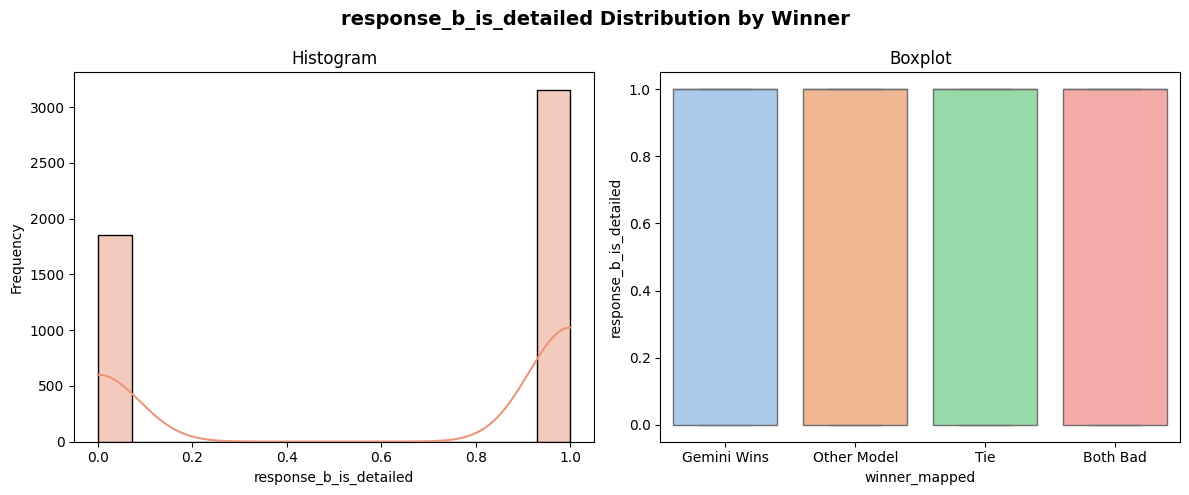

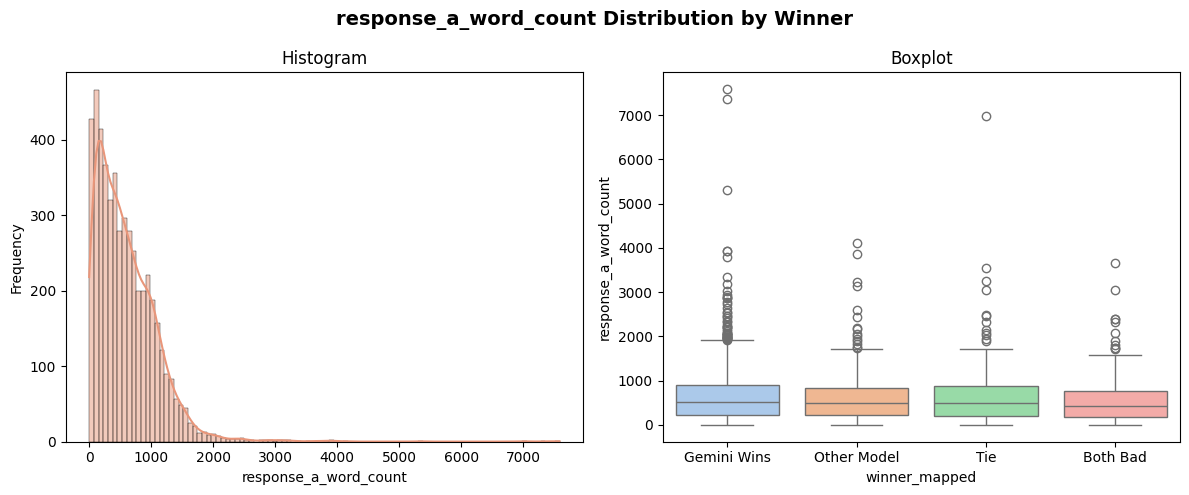

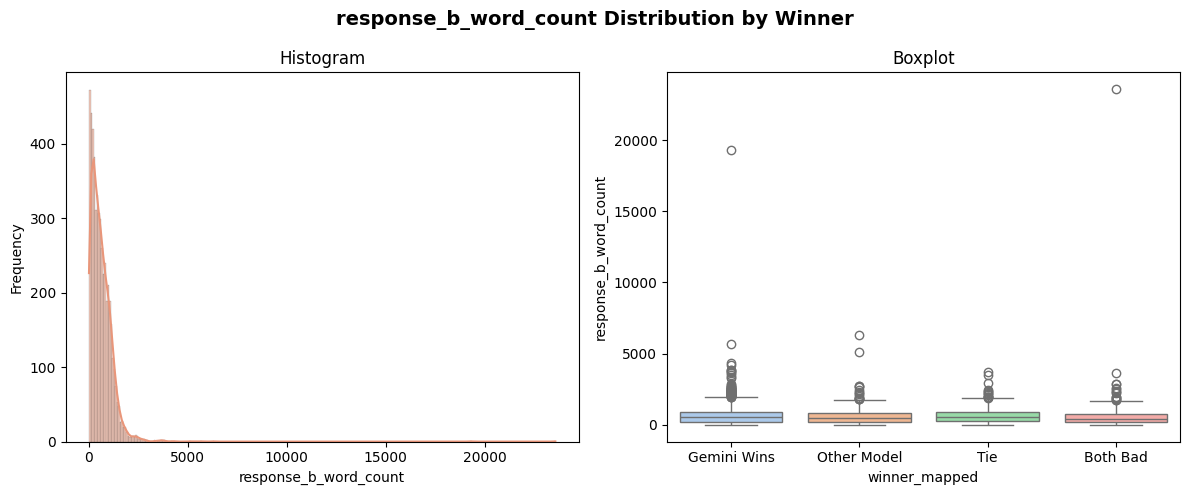

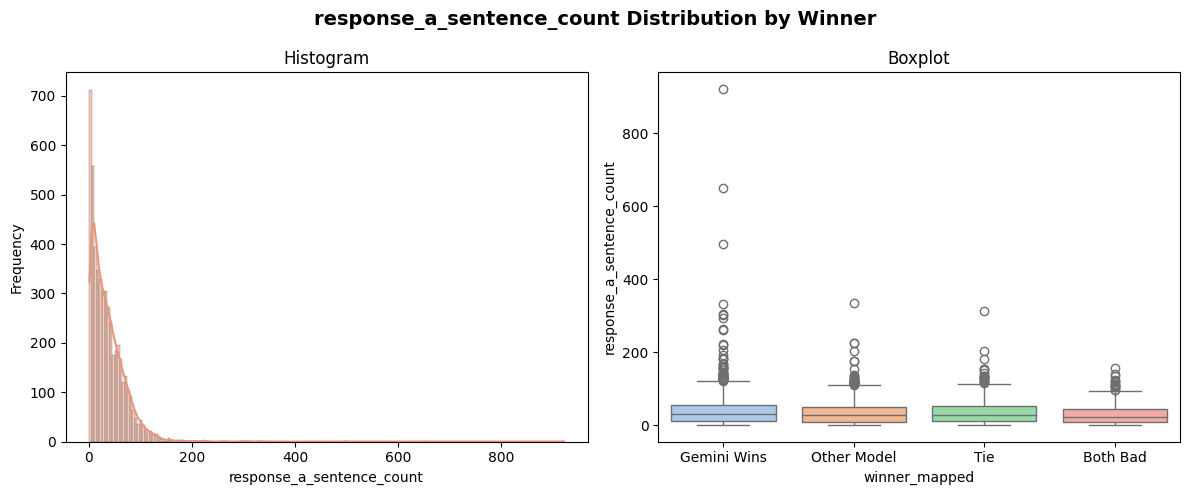

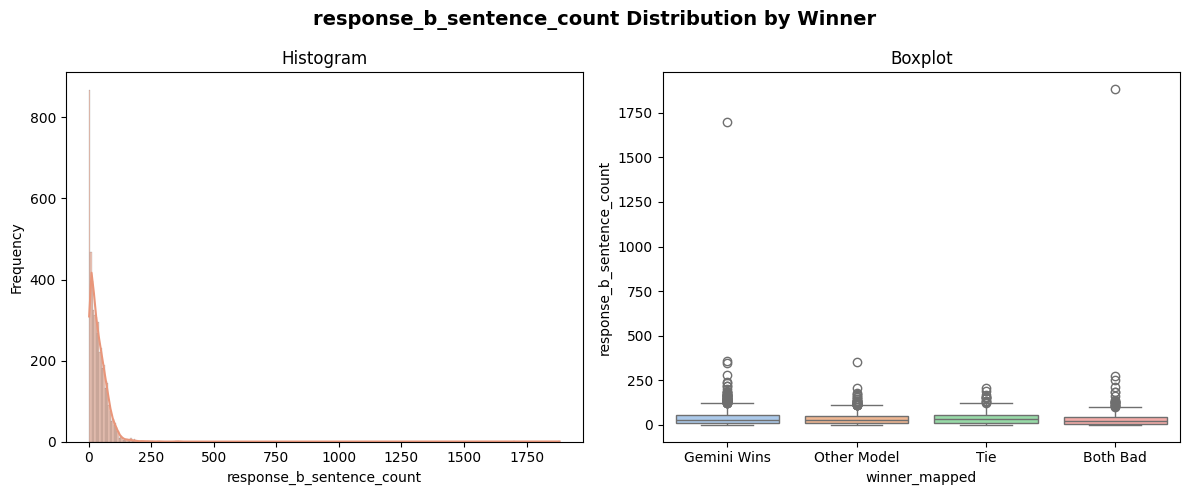

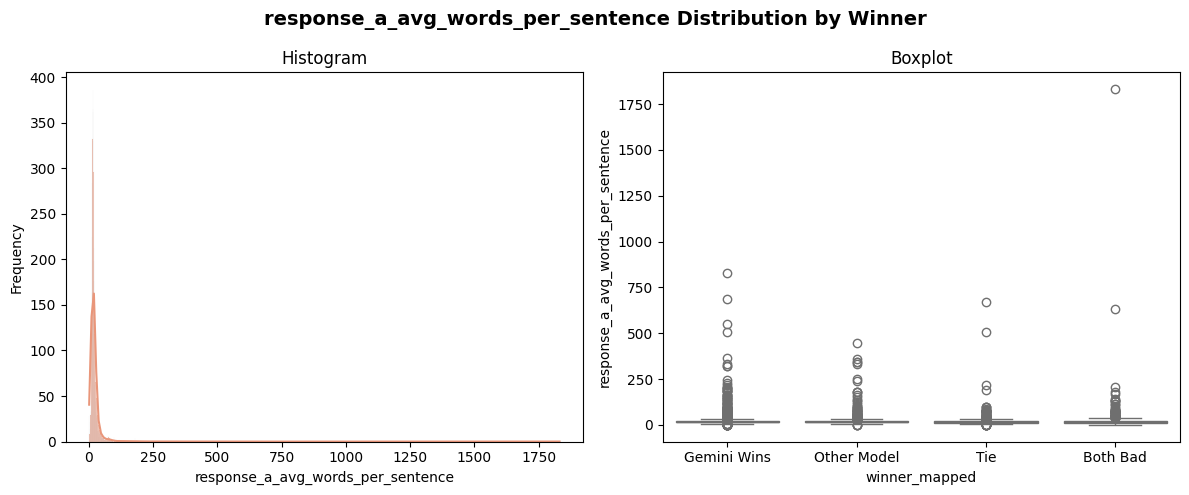

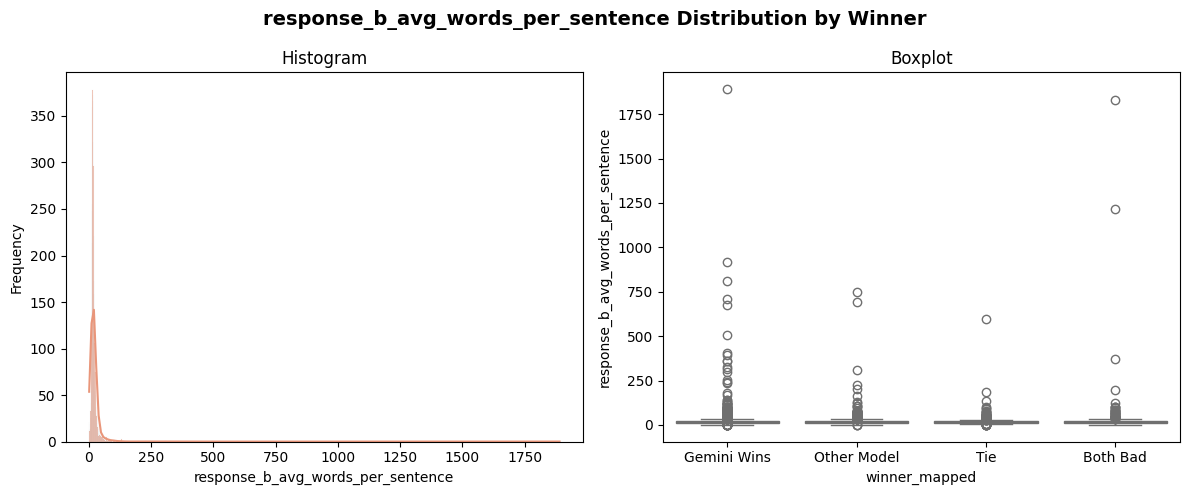

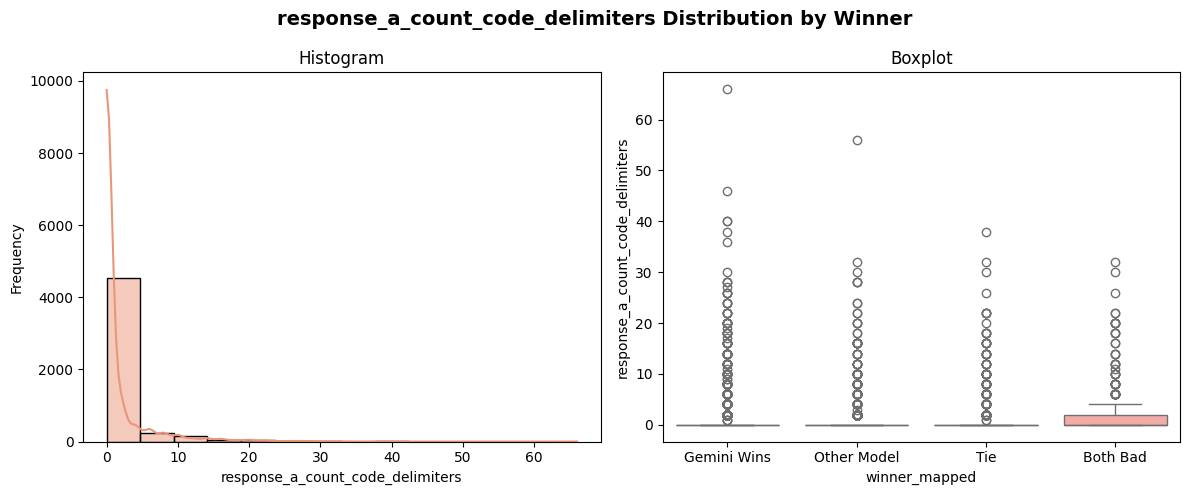

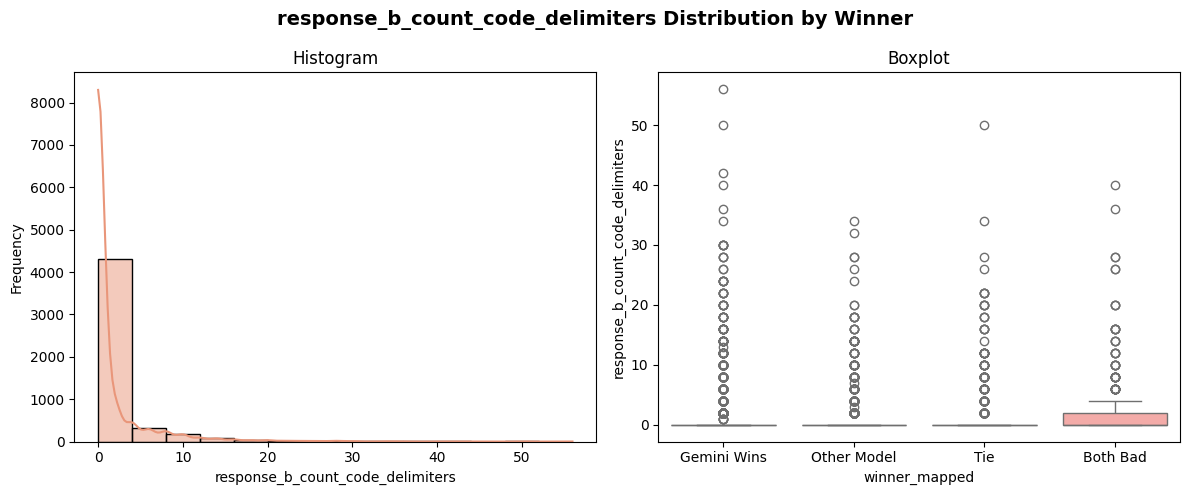

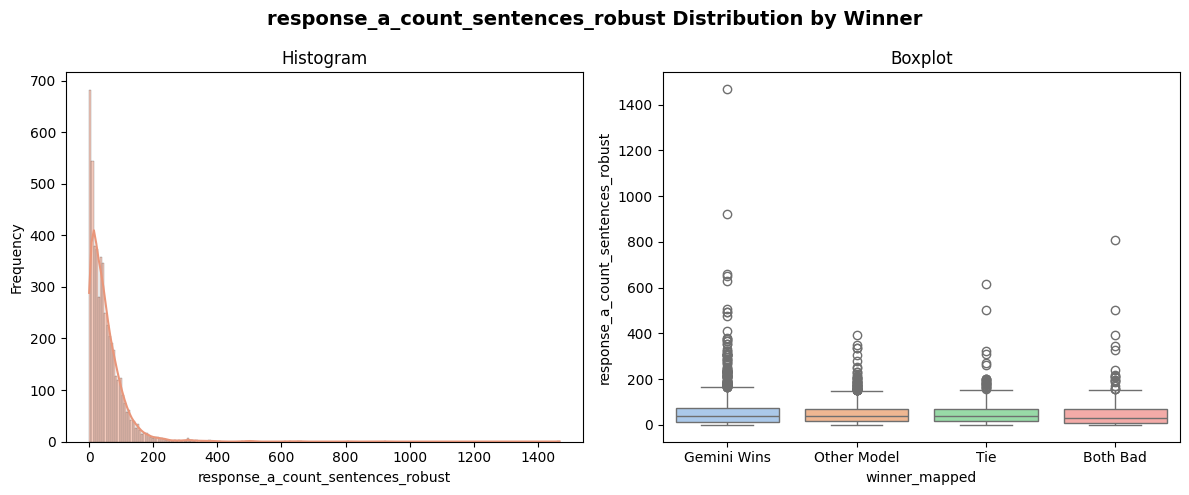

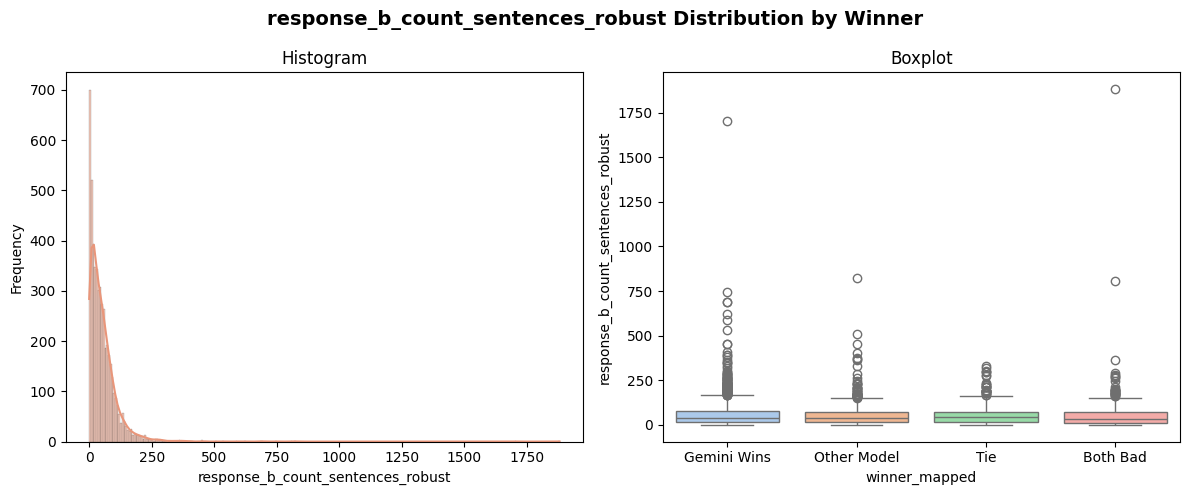

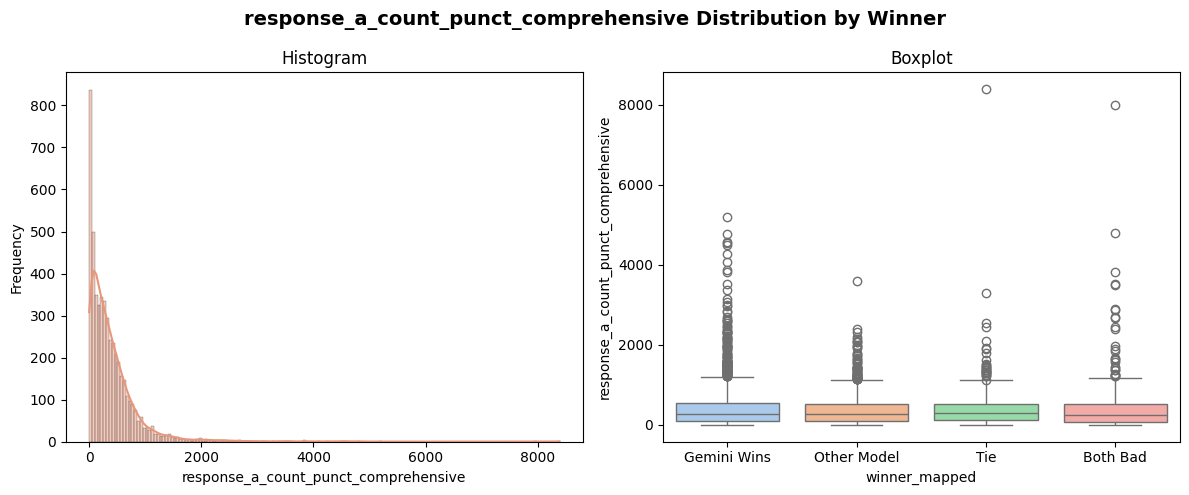

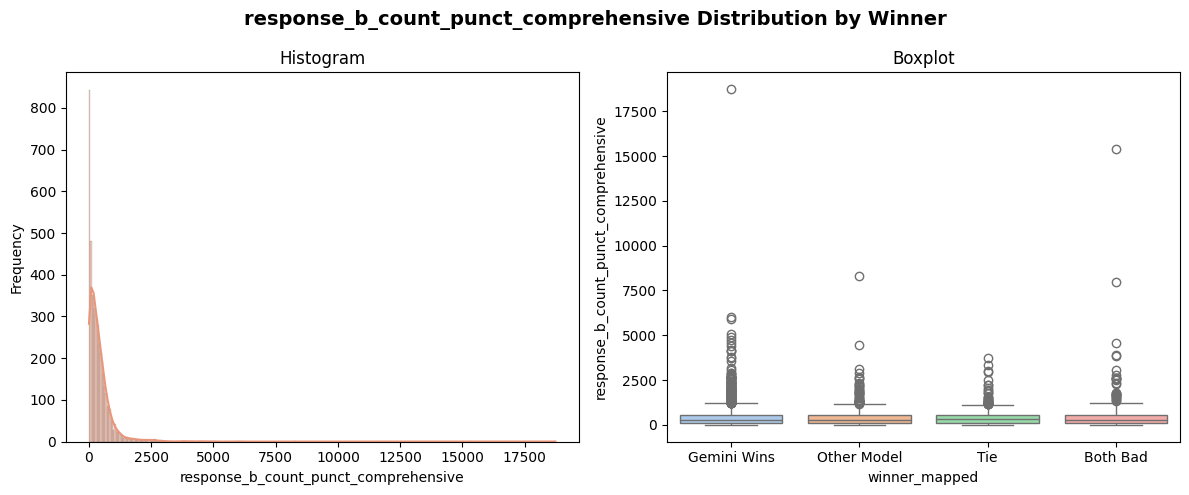

In [71]:
# Define the list of features to explore
winner_map = cfg['winner_map']
features = cfg['features']

# Optional axis limits for consistent visualization
x_min, x_max = 0, 2000
y_min, y_max = 0, 400

# Loop through each feature to plot its distribution
for feature in features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{feature} Distribution by Winner", fontsize=14, fontweight='bold')
    
    # Histogram of the feature
    sns.histplot(df_final[feature], kde=True, color='darksalmon', ax=axes[0])
    # axes[0].set_xlim(x_min, x_max)
    # axes[0].set_ylim(y_min, y_max)
    axes[0].set_title("Histogram")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Frequency")
    
    # Boxplot of the feature
    sns.boxplot(x=df_final['winner_mapped'].map(winner_map), y=df_final[feature], color='salmon', ax=axes[1], palette='pastel',)
    # axes[1].set_ylim(x_min, x_max)  
    axes[1].set_title("Boxplot")
    axes[1].set_ylabel(feature)
    
    plt.tight_layout()
    plt.show()


<div id="Plot-4-Winner-Count-Overview">
<h2>Plot 4: Winner Count Overview</h2>

<p>
In this step, we visualize the number of matches for each winner category: <strong>Gemini, Other Model, Tie,</strong> and <strong>Both Bad</strong>.  
The bar chart shows the count of matches per outcome, providing an overview of how match results are distributed across different categories.  
This helps to quickly see which outcomes are more frequent and whether the dataset is balanced.
</p>
</div>

</div>


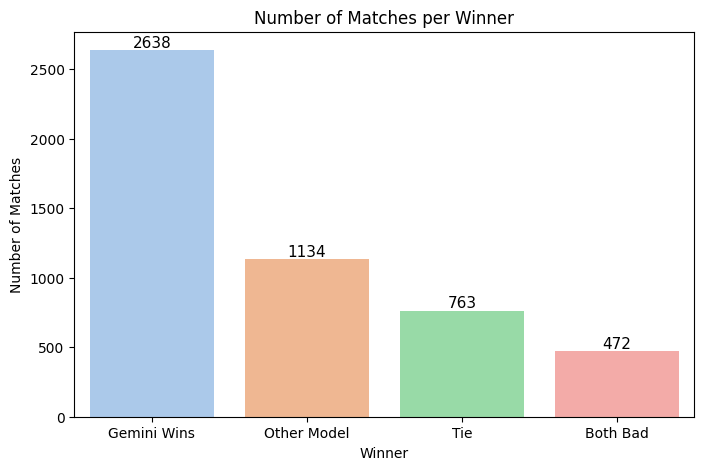

In [72]:
winner_map = cfg['winner_map']
plt.figure(figsize=(8,5))
ax = sns.countplot(x=df_final['winner_mapped'].map(winner_map), palette='pastel')

plt.xlabel('Winner')
plt.ylabel('Number of Matches')
plt.title('Number of Matches per Winner')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11)

plt.show()


<div id="Plot-5-Average-Absolute-Difference-Analysis">
<h2>Plot 5: Average Absolute Difference Analysis</h2>

<p>
In this step, we analyze the differences between winning and losing models for selected features.  
We calculate the <strong>absolute difference</strong> between winner and loser values for each match, excluding ties and both_bad cases.  
Then, we compute the <strong>average absolute difference</strong> per feature and winner category and visualize it using a horizontal bar chart.  
This helps identify which features differ most between winners and losers across the dataset.
</p>
</div>

</div>


<Figure size 1000x600 with 0 Axes>

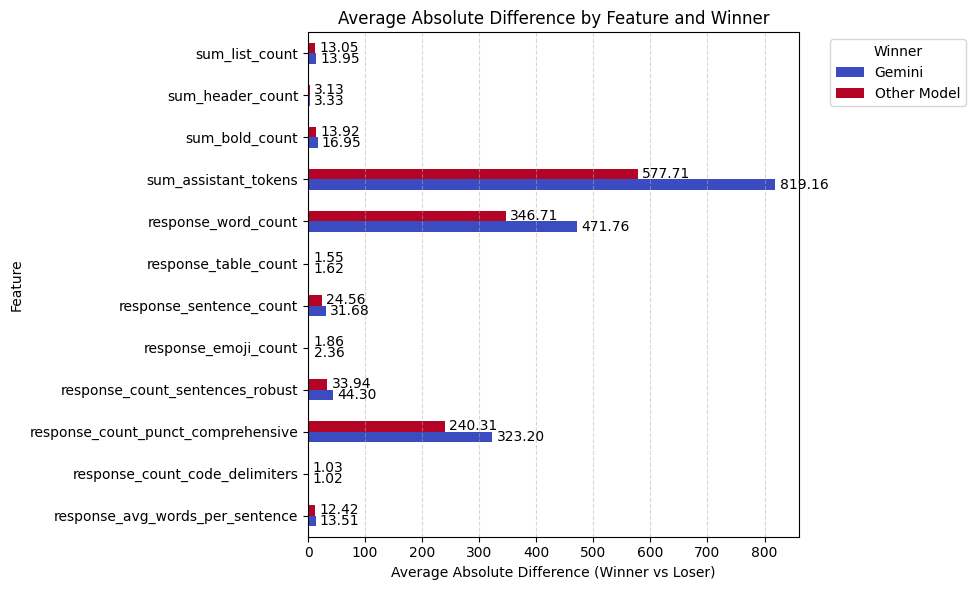

In [73]:
winner_map = cfg['winner_map']
# Define feature pairs: column A, column B, and combined base name
features = cfg['feature_pairs']

rows = []

for _, row in df_final.iterrows():
    # Skip tie or both_bad matches
    if (row.get('a',0) == 1 and row.get('b',0) == 1) or (row.get('a',0) == 0 and row.get('b',0) == 0):
        continue

    for col_a, col_b, base in features:
        a_val = row.get(col_a, np.nan)
        b_val = row.get(col_b, np.nan)

        # Assign winner and loser values
        if row.get('a', 0) == 1:
            winner_val, loser_val = a_val, b_val
        elif row.get('b', 0) == 1:
            winner_val, loser_val = b_val, a_val
        else:
            continue

        # Compute absolute difference
        abs_diff = np.abs(winner_val - loser_val)

        rows.append({
            'winner_mapped': row['winner_mapped'],
            'feature': base,
            'abs_diff': abs_diff
        })

# Create DataFrame with absolute differences
df_abs_diffs = pd.DataFrame(rows)

# Compute average absolute difference per feature and winner
mean_abs = df_abs_diffs.groupby(['winner_mapped','feature'])['abs_diff'].mean().reset_index()

# Map winner IDs to names
winner_map = {1:'Gemini', 2:'Other Model', 3:'Tie', 4:'Both Bad'}
mean_abs['winner_name'] = mean_abs['winner_mapped'].map(winner_map)

# Pivot for plotting
pivot_abs = mean_abs.pivot(index='feature', columns='winner_name', values='abs_diff').fillna(0)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
ax = pivot_abs.plot(kind='barh', figsize=(10,6), colormap='coolwarm')

plt.xlabel('Average Absolute Difference (Winner vs Loser)')
plt.ylabel('Feature')
plt.title('Average Absolute Difference by Feature and Winner')
plt.legend(title='Winner', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

<div id="Plot-6-Average-Percent-Difference-Analysis">
<h2>Plot 6: Average Percent Difference Analysis</h2>

<p>
In this step, we calculate the <strong>percentage difference</strong> between the winner and loser values for selected features.  
The percent difference is defined as:  
$$
\text{pct\_diff} = \frac{\text{winner\_val} - \text{loser\_val}}{|\text{loser\_val}|} \times 100
$$
This step is similar to Step 6 (absolute difference), but now the differences are expressed as percentages relative to the loser value.  
Ties and both_bad matches are excluded. The results are averaged per feature and winner and visualized using a horizontal bar chart.
</p>
</div>

<Figure size 1000x600 with 0 Axes>

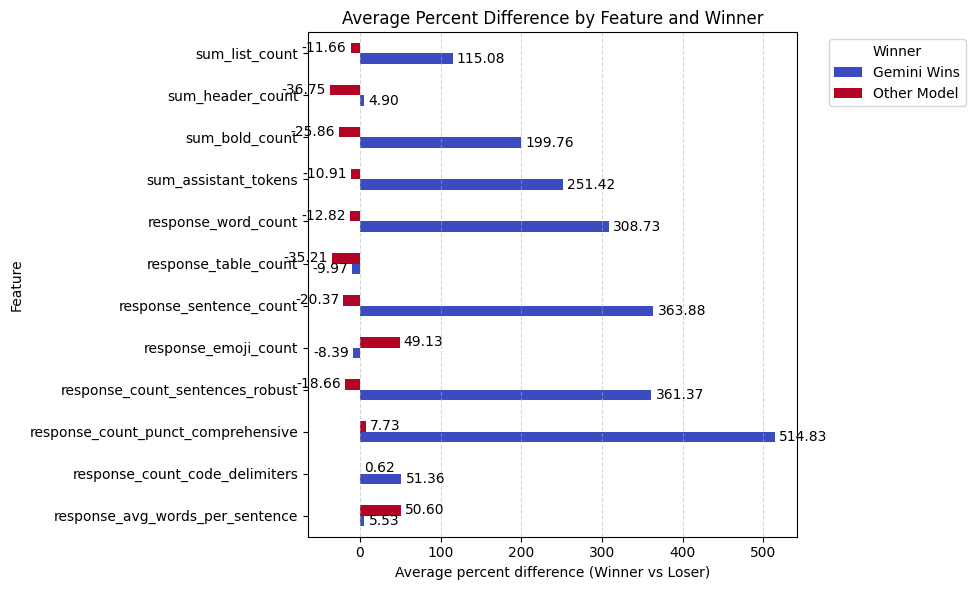

In [74]:
# Define feature pairs: column A, column B, and combined base name
features = cfg['feature_pairs']
winner_map = cfg['winner_map']

rows = []

for _, row in df_final.iterrows():
    # Skip both_bad and tie cases
    if row.get('a', 0) == 0 and row.get('b', 0) == 0:
        continue
    if row.get('a', 0) == 1 and row.get('b', 0) == 1:
        continue

    for col_a, col_b, base in features:
        a_val = row.get(col_a, np.nan)
        b_val = row.get(col_b, np.nan)

        # Assign winner and loser values
        if row.get('a', 0) == 1:
            winner_val, loser_val = a_val, b_val
        elif row.get('b', 0) == 1:
            winner_val, loser_val = b_val, a_val
        else:
            continue

        # Calculate differences
        diff = winner_val - loser_val
        abs_diff = np.abs(diff)
        pct_diff = np.nan
        if pd.notna(loser_val) and loser_val != 0:
            pct_diff = (diff / abs(loser_val)) * 100.0

        rows.append({
            'winner_mapped': row['winner_mapped'],
            'feature': base,
            'winner_val': winner_val,
            'loser_val': loser_val,
            'diff': diff,
            'abs_diff': abs_diff,
            'pct_diff': pct_diff
        })

# Create DataFrame with differences
df_diffs = pd.DataFrame(rows)
df_diffs['winner_name'] = df_diffs['winner_mapped'].map(winner_map)

# Aggregate average percentage difference per winner and feature
agg_pct = (
    df_diffs.groupby(['winner_name', 'feature'])['pct_diff']
    .mean()
    .reset_index()
)

# Pivot for visualization
pivot_pct = agg_pct.pivot(index='feature', columns='winner_name', values='pct_diff').fillna(0)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
ax = pivot_pct.plot(kind='barh', figsize=(10, 6), colormap='coolwarm')

plt.xlabel('Average percent difference (Winner vs Loser)')
plt.ylabel('Feature')
plt.title('Average Percent Difference by Feature and Winner')
plt.legend(title='Winner', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()


In [75]:
df_final[['sum_list_count_a','sum_list_count_b','a','b','winner_mapped']].head(10)


,sum_list_count_a,sum_list_count_b,a,b,winner_mapped
0,39,0,1,0,1
1,0,0,1,0,1
5,0,0,0,1,2
8,0,0,1,1,3
9,0,0,1,0,1
10,12,18,1,0,1
12,9,4,0,1,2
13,0,0,0,1,1
16,59,40,0,1,1
18,18,18,1,1,3


<div id="Plot-7-Average-Feature-Values-by-Winner">
<h2>Plot 7: Average Feature Values by Winner</h2>

<p>
In this step, we combine feature pairs (model A and model B) into a single value depending on the winner of the match.
</p>

<ul>
    <li>If model A wins, we take the value from A.</li>
    <li>If model B wins, we take the value from B.</li>
    <li>In case of a tie, we average A and B.</li>
    <li>If both models are bad, we assign 0.</li>
</ul>

<p>
After combining, we calculate and visualize the <strong>average value of each combined feature per winner</strong> using bar plots.
</p>
</div>

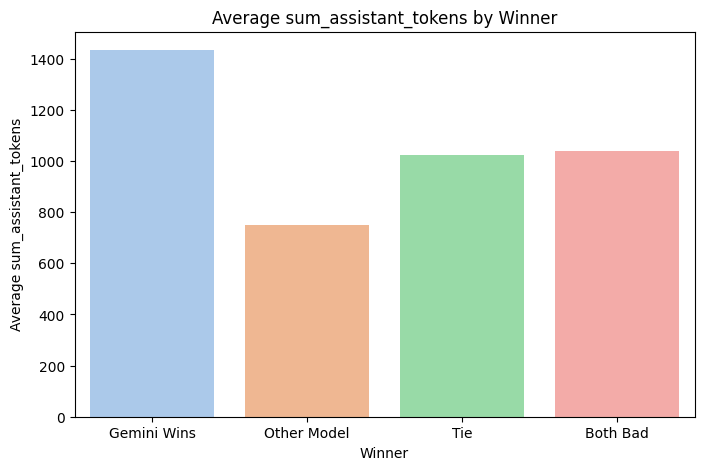

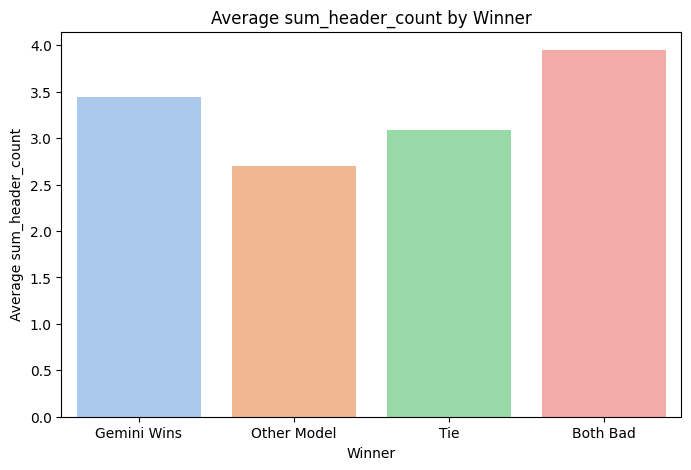

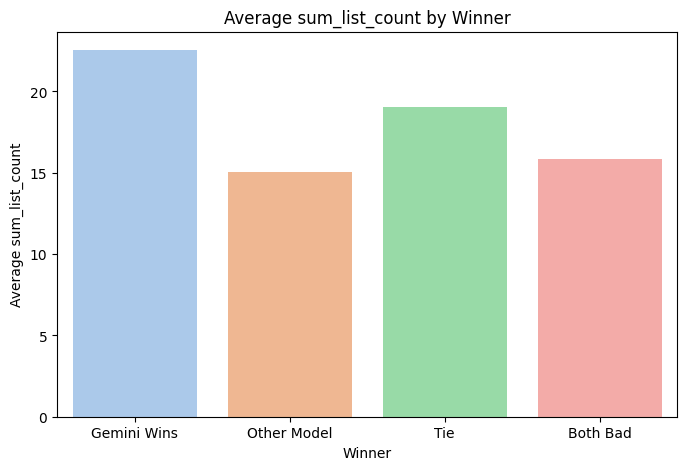

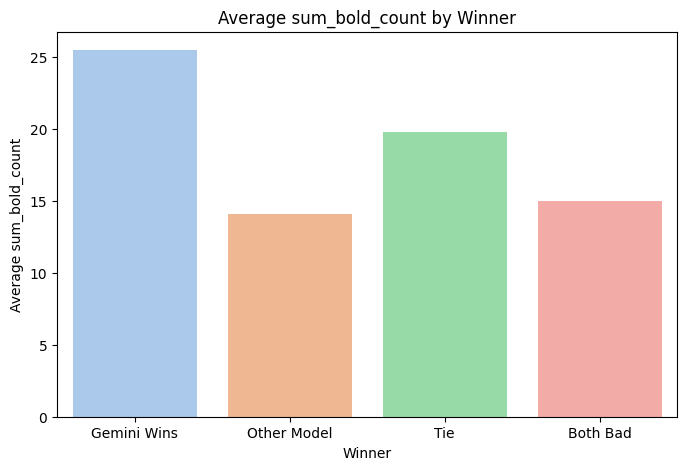

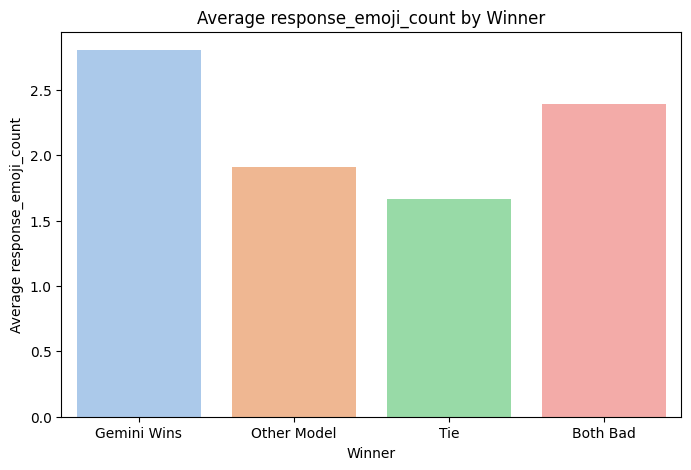

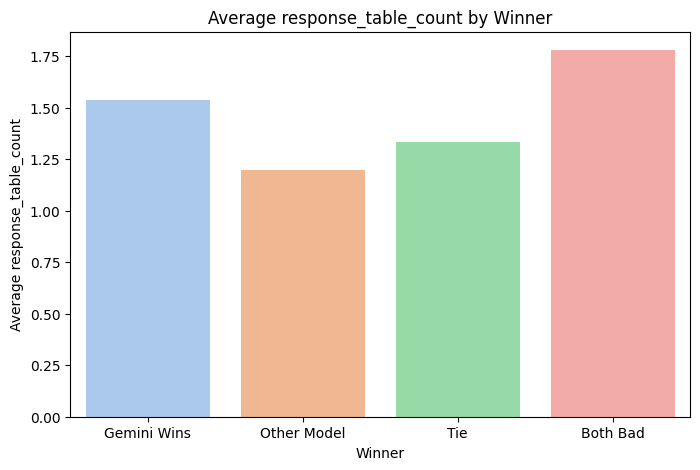

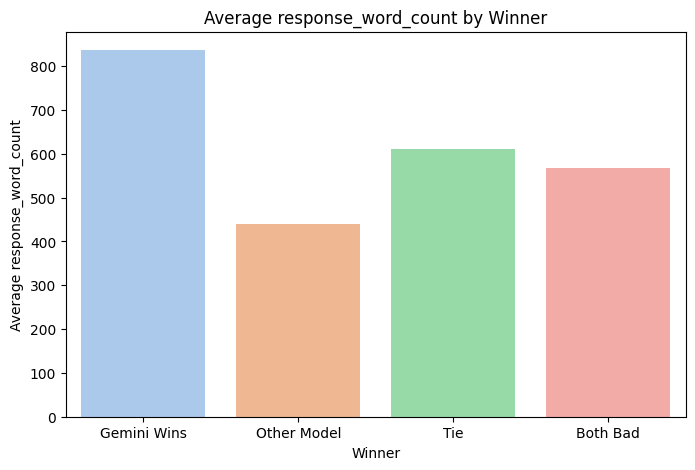

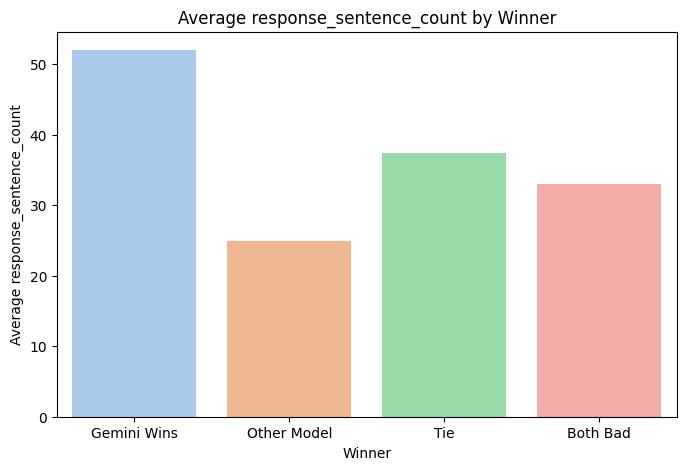

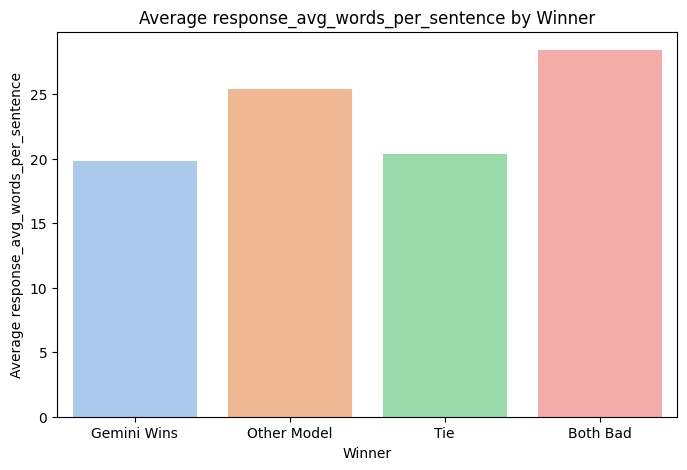

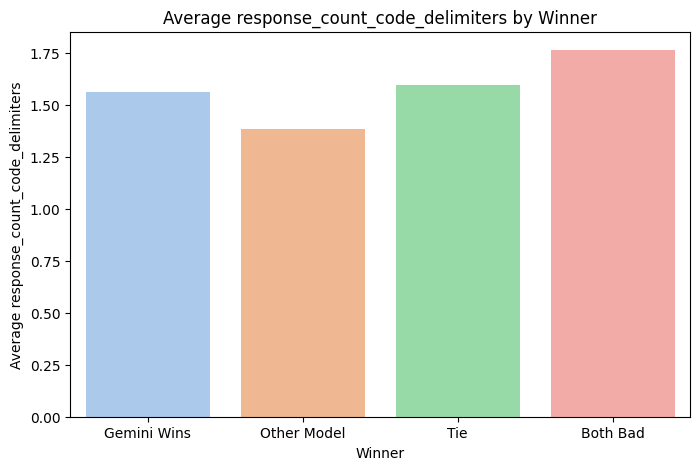

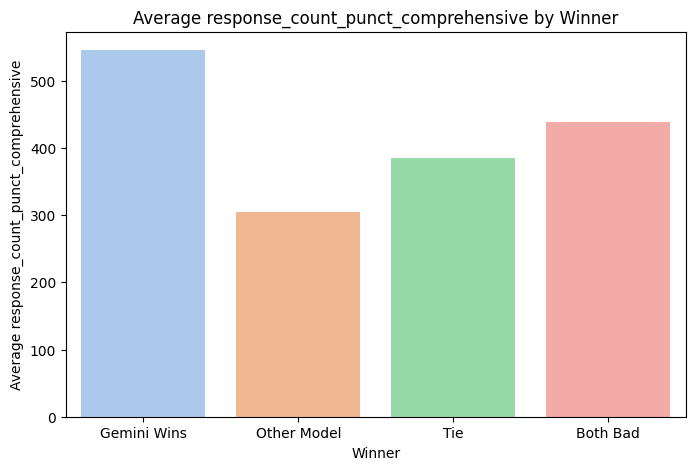

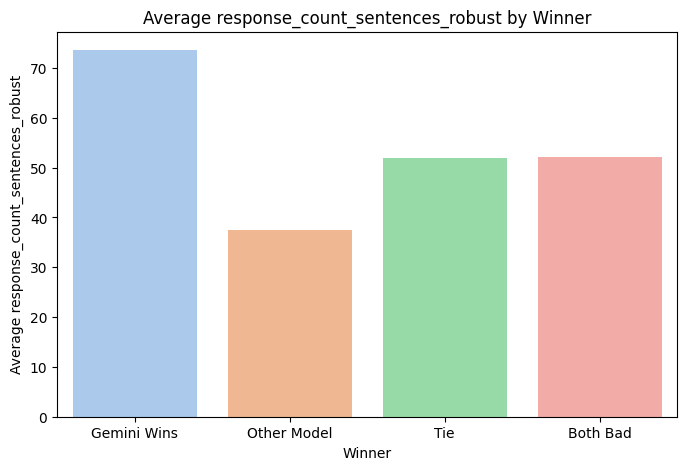

In [76]:
df_final = df_final.copy() 

# Map winner_mapped numbers to readable names
winner_map = cfg['winner_map']

# Define feature pairs: (column_a, column_b, combined_column_name)
features_pairs = cfg['feature_pairs']

# Combine features based on winner
for col_a, col_b, col_comb in features_pairs:
    df_final.loc[:, col_comb] = df_final.apply(
        lambda row: row[col_a] if row['a']==1 and row['b']==0
                    else row[col_b] if row['b']==1 and row['a']==0
                    else (row[col_a]+row[col_b])/2 if row['a']==1 and row['b']==1
                    else (row[col_a]+row[col_b])/2,
        axis=1
    )

# List of combined features
combined_features = [f[2] for f in features_pairs]

# Plot average value per winner for each feature
for feature in combined_features:
    avg_feature = df_final.groupby('winner_mapped')[feature].mean().reset_index()
    avg_feature['winner_name'] = avg_feature['winner_mapped'].map(winner_map)
    
    plt.figure(figsize=(8,5))
    sns.barplot(x='winner_name', y=feature, data=avg_feature, palette='pastel')
    plt.xlabel('Winner')
    plt.ylabel(f'Average {feature}')
    plt.title(f'Average {feature} by Winner')
    plt.show()


<div id="Plot-8-Features-Contributing-to-Gemini-Wins">
<h2>Plot 8: Features Contributing to Gemini Wins</h2>

<p>
In this step, we calculate which features have the largest contribution to Gemini winning over other models.  
We combine feature pairs based on the winner, then compute the average value of each feature for Gemini and for other models.  
Finally, we calculate the absolute percentage difference and visualize the features contributing most to Gemini wins using a horizontal bar plot.
</p>
</div>

</div>

</div>


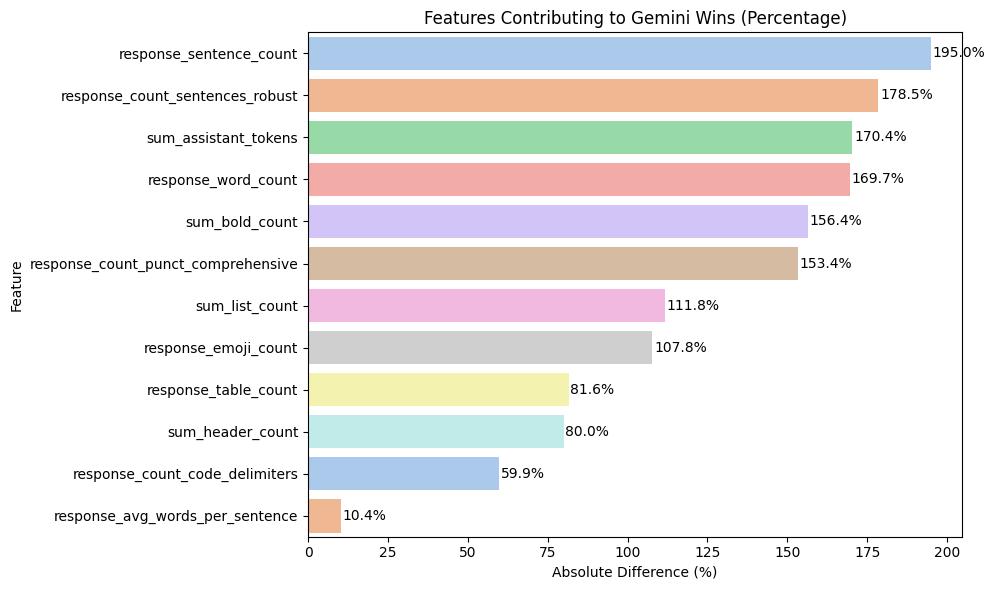

In [77]:
# Make a copy of the dataframe to avoid modifying the original
df_final = df_final.copy() 

# Define feature pairs: (column from model A, column from model B, combined column name)
features_pairs = cfg['feature_pairs']

# Combine features based on winner: take winner's value, average if tie, 0 if both_bad
for col_a, col_b, col_comb in features_pairs:
    df_final[col_comb] = df_final.apply(
        lambda row: row[col_a] if row['a']==1 and row['b']==0
                    else row[col_b] if row['b']==1 and row['a']==0
                    else (row[col_a]+row[col_b])/2 if row['a']==1 and row['b']==1
                    else 0,
        axis=1
    )

# List of combined features
features = [col_comb for _, _, col_comb in features_pairs]

# Compute average value for Gemini and for other models
gemini_avg = df_final[df_final['winner_mapped']==1][features].mean()
other_avg = df_final[df_final['winner_mapped'].isin([2,4])][features].mean()

# Calculate absolute percentage difference
diff_percent = ((gemini_avg - other_avg) / other_avg * 100).abs().sort_values(ascending=False)
top_features = diff_percent  # Take all features, not limited to top 10

# Plot horizontal bar chart of feature differences
plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_features.values, y=top_features.index, palette='pastel')

plt.xlabel('Absolute Difference (%)')
plt.ylabel('Feature')
plt.title('Features Contributing to Gemini Wins (Percentage)')

# Annotate values on bars
for i, v in enumerate(top_features.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", color='black', va='center')

plt.tight_layout()
plt.show()


**Interpretation of 170.4% Value**

The value **170.4%** means that for this specific feature, **Gemini’s average value is 170.4% higher than the average value of the other models**.  

In other words, if the other models have an average value of 1 for this feature, Gemini has an average value of:

$$
1 \times \left(1 + \frac{170.4}{100}\right) = 2.704
$$

This percentage quantifies how much this feature contributes to Gemini's wins compared to the other models.
r models.


<div id="Plot-9-Features-Contributing-to-Gemini-Loss">
<h2>Plot 9: Features Contributing to Gemini Loss</h2>

<p>
In this step, we analyze which features are associated with Gemini losing to other models.  
We combine feature pairs (model A and model B) based on the winner of the match, then calculate the average value of each combined feature for matches where Gemini lost and where Gemini won.  
Finally, we compute the absolute percentage difference and visualize the features that most contribute to Gemini's losses using a horizontal bar plot.
</p>
</div>

</div>


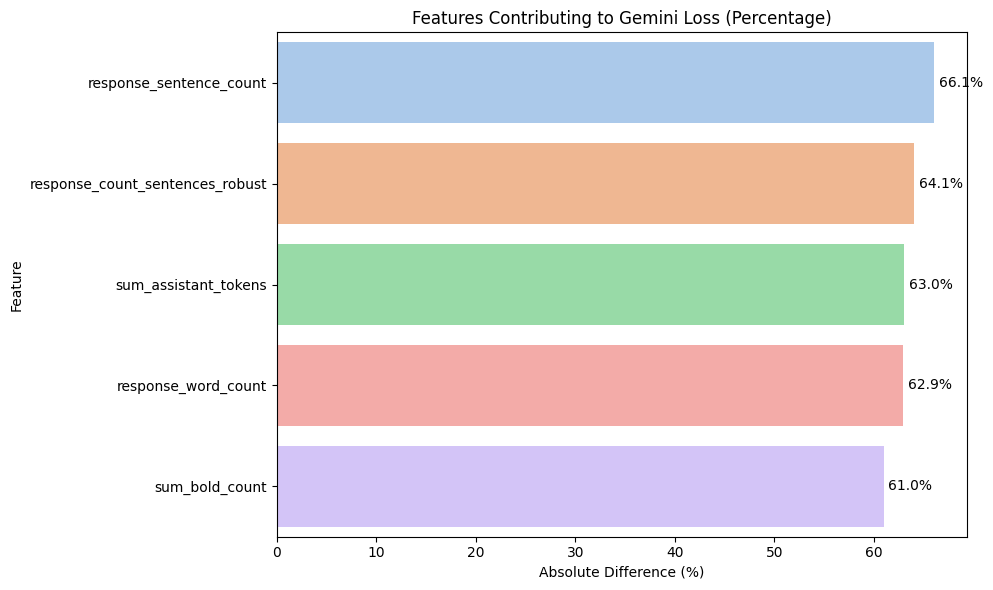

In [78]:
# Analyze features contributing to Gemini's losses

df_final = df_final.copy()

# Define feature pairs to combine A and B features
features_pairs = cfg['feature_pairs']

# Combine features based on winner
for col_a, col_b, col_comb in features_pairs:
    df_final[col_comb] = df_final.apply(
        lambda row: row[col_a] if row['a']==1 and row['b']==0
                    else row[col_b] if row['b']==1 and row['a']==0
                    else (row[col_a]+row[col_b])/2 if row['a']==1 and row['b']==1
                    else 0,
        axis=1
    )

# List of combined features
features = [col_comb for _, _, col_comb in features_pairs]

# Separate matches where Gemini won and lost
gemini_lost = df_final[df_final['winner_mapped'].isin([2,4])]
gemini_win = df_final[df_final['winner_mapped'] == 1]

# Calculate average feature values for lost and won matches
gemini_lost_avg = gemini_lost[features].mean()
gemini_win_avg = gemini_win[features].mean()

# Compute absolute percentage difference
diff_percent = ((gemini_win_avg - gemini_lost_avg) / gemini_win_avg * 100).abs().sort_values(ascending=False)
top10_features = diff_percent.head()

# Plot features contributing most to Gemini losses
plt.figure(figsize=(10,6))
ax = sns.barplot(x=top10_features.values, y=top10_features.index, palette='pastel')

plt.xlabel('Absolute Difference (%)')
plt.ylabel('Feature')
plt.title('Features Contributing to Gemini Loss (Percentage)')

# Annotate bars with percentage values
for i, v in enumerate(top10_features.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", color='black', va='center')

plt.tight_layout()
plt.show()


<div id="Plot-10-Features-Similar-in-Tie-Outcomes">
<h2>Plot 10: Features Similar in Tie Outcomes</h2>

<p>
In this step, we identify which features have similar values in tie matches compared to matches with a clear winner.  
We combine feature pairs (model A and model B) based on the winner of each match.  
Then, we calculate the average feature values for tie matches and for winner matches, compute the absolute percentage difference, and visualize the features that are most similar in tie outcomes using a horizontal bar plot.
</p>
</div>

</div>


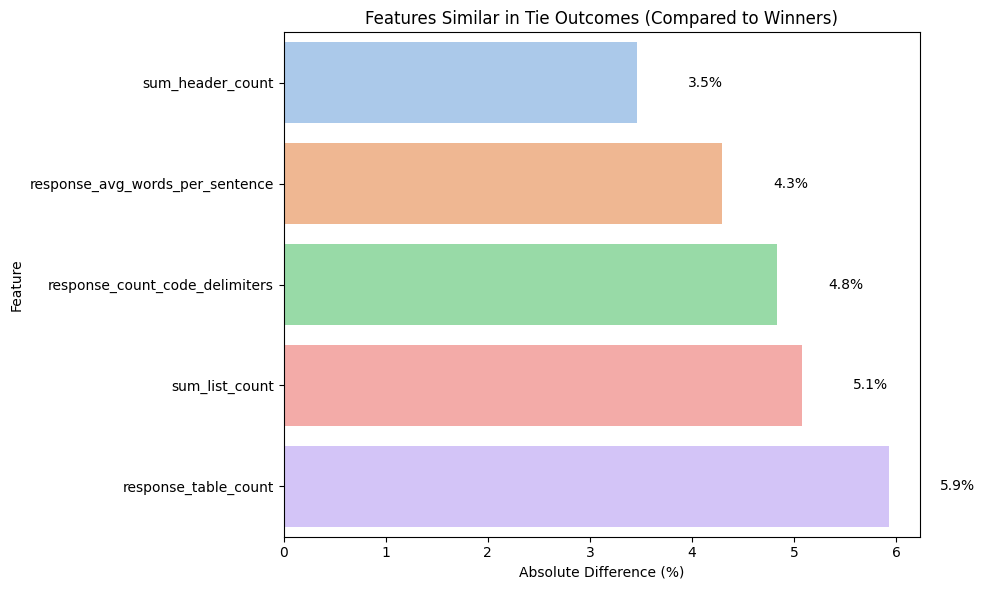

In [79]:
# Analyze features that are similar in tie matches compared to winner matches

df_final = df_final.copy()

# Combine a/b features into a single column based on winner
features_pairs = cfg['feature_pairs']

for col_a, col_b, col_comb in features_pairs:
    df_final[col_comb] = df_final.apply(
        lambda row: row[col_a] if row['a']==1 and row['b']==0
                    else row[col_b] if row['b']==1 and row['a']==0
                    else (row[col_a]+row[col_b])/2 if row['a']==1 and row['b']==1
                    else 0,
        axis=1
    )

# List of combined features
features = [col_comb for _, _, col_comb in features_pairs]

# Select only winner rows
winner_rows = df_final[(df_final['a']==1) | (df_final['b']==1)]

# Select tie rows
tie_rows = df_final[df_final['winner_mapped'] == 3]

# Calculate average feature values
tie_avg = tie_rows[features].mean()
winner_avg = winner_rows[features].mean()

# Compute absolute percentage difference
diff_percent = ((tie_avg - winner_avg).abs() / winner_avg * 100).sort_values(ascending=True)
top_similar_features = diff_percent.head()

# Plot features most similar in tie outcomes
plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_similar_features.values, y=top_similar_features.index, palette='pastel')

plt.xlabel('Absolute Difference (%)')
plt.ylabel('Feature')
plt.title('Features Similar in Tie Outcomes (Compared to Winners)')

# Annotate bars with percentage values
for i, v in enumerate(top_similar_features.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", color='black', va='center')

plt.tight_layout()
plt.show()


In [80]:
top_similar_features

sum_header_count                   3.465270
response_avg_words_per_sentence    4.293744
response_count_code_delimiters     4.832089
sum_list_count                     5.075888
response_table_count               5.934257
dtype: float64

<div id="Plot-11-RandomForest-Feature-Importance">
<h2>Plot 11: Random Forest Feature Importance for Predicting Gemini Wins</h2>

<p>
In this step, we use a Random Forest classifier to identify which features are most important for predicting Gemini wins.  
We first remove rows where both models are bad, then combine feature pairs into a single value based on the winner.  
We define the target as 1 if Gemini won (model A) and 0 otherwise.  
Finally, we train the Random Forest, extract feature importances, and visualize them using a horizontal bar plot.
</p>
</div>

</div>


Random Forest accuracy on test set: 0.55

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.33      0.39       580
           1       0.59      0.72      0.65       781

    accuracy                           0.55      1361
   macro avg       0.53      0.52      0.52      1361
weighted avg       0.54      0.55      0.54      1361


Predicted probabilities (first 10 samples):
   y_true  y_pred_proba
0       1         0.740
1       1         0.540
2       0         0.465
3       1         0.455
4       0         0.580
5       1         0.385
6       1         0.470
7       1         0.755
8       0         0.455
9       1         0.635


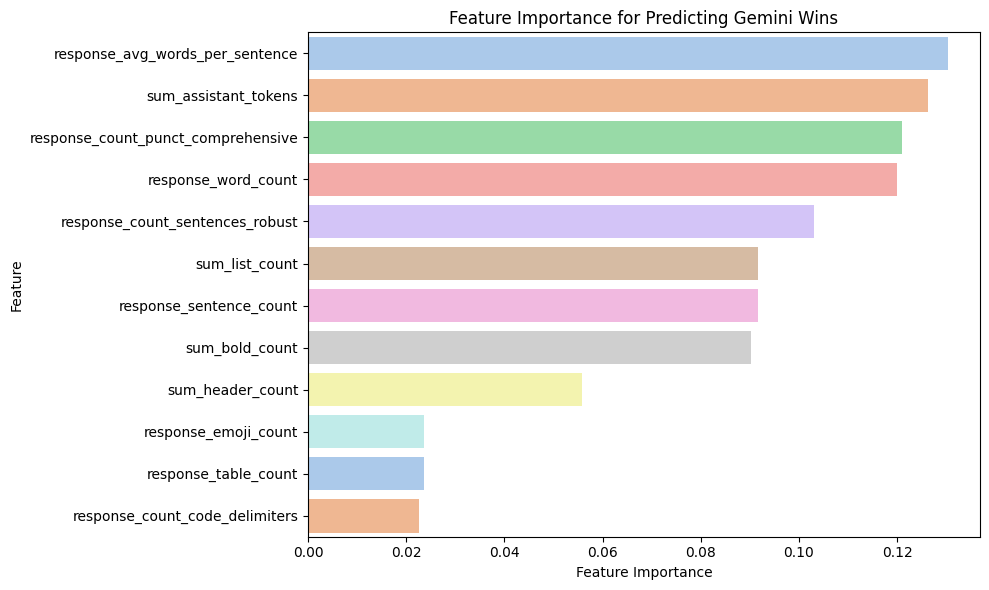

In [81]:
# Make a copy of df_final
df_rf = df_final.copy()
df_rf = df_rf[(df_rf['a'] + df_rf['b']) > 0]  # Remove both_bad rows
df_rf['winner_label'] = df_rf['a']  # Target: 1 if Gemini won (a=Gemini), 0 otherwise

# Feature pairs
features_pairs = cfg['feature_pairs']

# Create combined features
for col_a, col_b, col_comb in features_pairs:
    df_rf[col_comb] = df_rf.apply(
        lambda row: row[col_a] if row['a']==1 and row['b']==0
                    else row[col_b] if row['b']==1 and row['a']==0
                    else (row[col_a]+row[col_b])/2 if row['a']==1 and row['b']==1
                    else 0,
        axis=1
    )

features = [col_comb for _, _, col_comb in features_pairs]

# Prepare data
X = df_rf[features]
y = df_rf['winner_label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of Gemini win (label=1)

# Accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest accuracy on test set: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Show predicted probabilities for first 10 samples
proba_df = pd.DataFrame({'y_true': y_test.values, 'y_pred_proba': y_proba})
print("\nPredicted probabilities (first 10 samples):")
print(proba_df.head(10))

# Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette='pastel')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Predicting Gemini Wins')
plt.tight_layout()
plt.show()


<div id="Plot-12-Correlation-Analysis-with-Gemini-Wins"> 
<h2>Plot 12: Correlation Analysis with Gemini Wins</h2>
<p> In this step, we analyze the correlation between features and Gemini winning. We create a binary target column (`is_gemini`) indicating whether Gemini won the match. We combine the feature pairs (A/B) into single values depending on the winner of each match. Finally, we compute the correlation matrix including the target and visualize it as a heatmap to observe which features are most associated with Gemini wins. </p> </div>

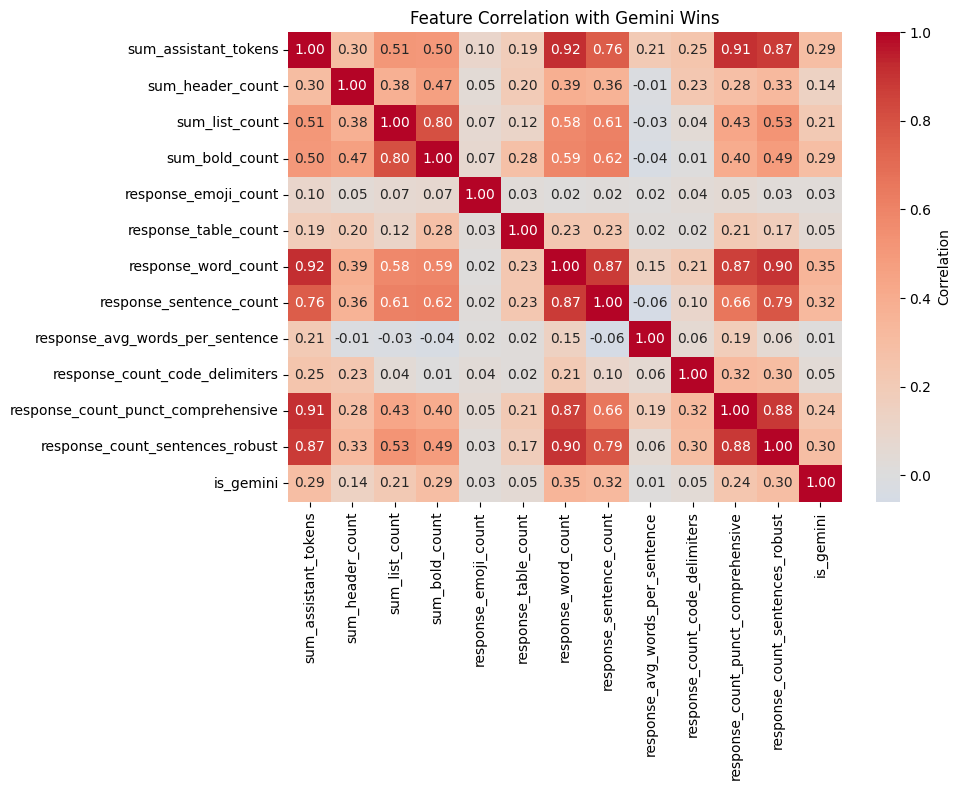

In [82]:
# Make a copy to avoid SettingWithCopyWarning
df_corr = df_final.copy()

# Create binary column: 1 if winner is Gemini, 0 otherwise
df_corr['is_gemini'] = (df_corr['winner_mapped'] == 1).astype(int)

# List of features to include in the heatmap
features_pairs = cfg['feature_pairs']

# Combine a/b columns into single feature for winner analysis
for col_a, col_b, col_comb in features_pairs:
    df_corr[col_comb] = df_corr.apply(
        lambda row: row[col_a] if row['a']==1 and row['b']==0
                    else row[col_b] if row['b']==1 and row['a']==0
                    else (row[col_a]+row[col_b])/2 if row['a']==1 and row['b']==1
                    else 0,
        axis=1
    )

# Features for heatmap
features = [col_comb for _, _, col_comb in features_pairs]

# Include 'is_gemini' as the target
features.append('is_gemini')

# Compute correlation
corr_matrix = df_corr[features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Correlation'},
    center=0
)
plt.title('Feature Correlation with Gemini Wins')
plt.tight_layout()
plt.show()


<div id="Plot-13-Interactive-Violin-Plots"> 
<h2>Plot 13: Interactive Violin Plots of Feature Distributions by Winner</h2>
<p> In this step, we create interactive violin plots for each combined feature to visualize their distribution across different winners. - We combine feature pairs (A/B) into a single column depending on the winner of the match. - Winner names are mapped from numeric codes to labels (Gemini, Other Model, Tie, Both Bad). - Interactive violin plots are generated for each feature, showing the full distribution, box plot, and individual points for deeper exploration. </p> </div>

In [83]:
# # Make a copy
# df_plot = df_final.copy()

# # Winner mapping
# winner_map = cfg['winner_map']

# # Combine features a/b into single columns
# features_pairs = cfg['feature_pairs']

# for col_a, col_b, col_comb in features_pairs:
#     df_plot[col_comb] = df_plot.apply(
#         lambda row: row[col_a] if row['a']==1 and row['b']==0
#                     else row[col_b] if row['b']==1 and row['a']==0
#                     else (row[col_a]+row[col_b])/2 if row['a']==1 and row['b']==1
#                     else 0,
#         axis=1
#     )

# # Map winner names
# df_plot['winner_name'] = df_plot['winner_mapped'].map(winner_map)

# # List of combined features
# features = [col_comb for _, _, col_comb in features_pairs]

# # Plot interactive Violin plots
# for feature in features:
#     fig = px.violin(
#         df_plot,
#         x='winner_name',
#         y=feature,
#         color='winner_name',
#         box=True,           
#         points='all',       
#         hover_data=df_plot.columns,
#         labels={
#             'winner_name': 'Winner',
#             feature: feature
#         },
#         title=f'{feature} Distribution by Winner'
#     )
#     fig.show()


<div id="Plot-14-Feature-Comparison-by-Winner">
<h2>Plot-14: Feature Comparison by Winner (Percentage of Max)</h2>
<p> In this step, we normalize each feature per winner relative to the maximum value across all winners to express it as a percentage: $$ \text{Percent} = \frac{\text{Feature Value for Winner}}{\max(\text{Feature Value for All Winners})} \times 100 $$ - We combine feature pairs (A/B) into single columns depending on the winner. - Mean values of each feature are calculated per winner. - Each feature value is converted to a percentage of the maximum value for that feature. - Finally, grouped bar plots are generated showing the normalized feature comparison across winners with percentages displayed on the bars. </p> </div>

In [84]:
# Make a copy
df_plot = df_final.copy()

# Winner mapping
winner_map = cfg['winner_map']
df_plot['winner_name'] = df_plot['winner_mapped'].map(winner_map)

# Combine features a/b into single columns
features_pairs = cfg['feature_pairs']

for col_a, col_b, col_comb in features_pairs:
    df_plot[col_comb] = df_plot.apply(
        lambda row: row[col_a] if row['a']==1 and row['b']==0
                    else row[col_b] if row['b']==1 and row['a']==0
                    else (row[col_a]+row[col_b])/2 if row['a']==1 and row['b']==1
                    else 0,
        axis=1
    )

# List of combined features
features = [col_comb for _, _, col_comb in features_pairs]

# Calculate mean for each winner and feature
mean_features = df_plot.groupby('winner_name')[features].mean().reset_index()

# Convert to long format for plotting
mean_features_long = mean_features.melt(
    id_vars='winner_name', 
    value_vars=features, 
    var_name='Feature', 
    value_name='Mean Value'
)

# Convert each feature to percentage of max
mean_features_long['Percent'] = mean_features_long.groupby('Feature')['Mean Value']\
    .transform(lambda x: x / x.max() * 100)

# Plot grouped bar chart
fig = px.bar(
    mean_features_long, 
    x='Percent', 
    y='Feature', 
    color='winner_name', 
    barmode='group', 
    text='Percent',
    labels={'Percent': 'Percentage of Max', 'Feature': 'Feature', 'winner_name': 'Winner'},
    title='Feature Comparison by Winner (Percentage of Max)'
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()


<div id="Plot-15-Criteria-Breakdown-by-Winner"> 
<h2>Plot 15: Criteria Breakdown by Winner</h2>
<p>
In this step, we visualize how different evaluation criteria relate to the outcome of the matches.  
- We focus on the <strong>criteria_v0.1</strong> features extracted from the dataset (e.g., complexity, creativity, domain knowledge, problem solving, technical accuracy).  
- Winner codes are mapped to readable labels: Gemini, Other Model, Tie, Both Bad.  
- For each winner category, we calculate the mean value of each criteria (proportion of True).  
- A grouped bar chart is created, showing the relative contribution of each criterion across winner categories.  
- This plot helps us identify which criteria are more commonly satisfied in matches won by Gemini compared to other outcomes, giving insight into what factors correlate with Gemini's success.
</p>
</div>


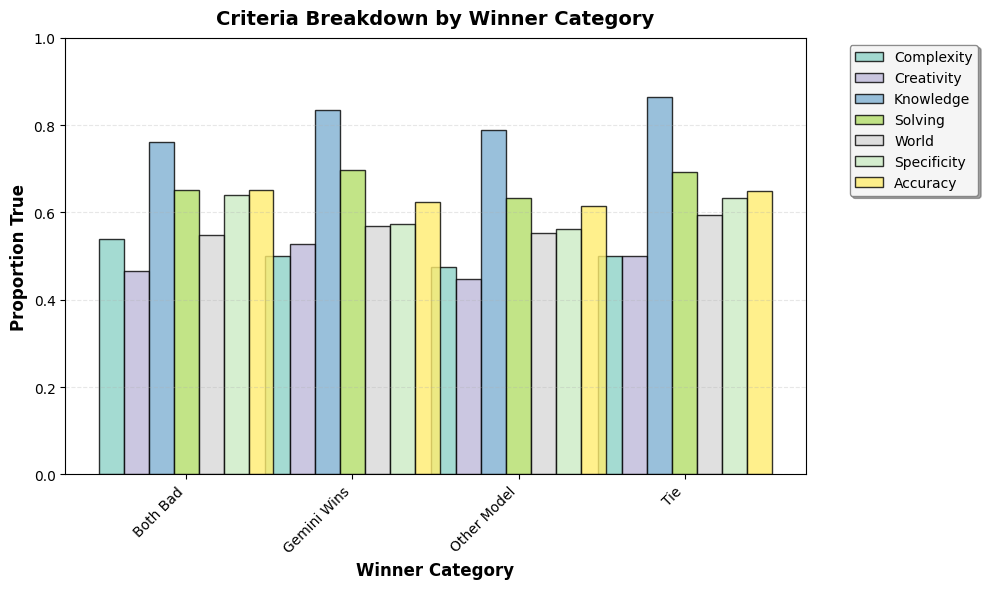

In [85]:
# Make a copy
df_plot = df_final.copy()

# Map winner codes to readable names
winner_map = cfg['winner_map']

# Create a column for readable winner names
df_plot['winner_name_readable'] = df_plot['winner_mapped'].map(winner_map)

# Select criteria columns
criteria_cols = [c for c in df_plot.columns if 'criteria_v0.1' in c]

# Compute mean of each criteria per winner
criteria_means = df_plot.groupby('winner_name_readable', observed=True)[criteria_cols].mean()

# Plot settings
x = np.arange(len(criteria_means))
width = 0.15
colors_list = plt.cm.Set3(np.linspace(0, 1, len(criteria_cols)))

plt.figure(figsize=(10,6))

for idx, crit_col in enumerate(criteria_cols):
    # Offset bars for grouped layout
    offset = (idx - len(criteria_cols) / 2) * width + width / 2
    crit_name = crit_col.split('_')[-1].replace('_', ' ').title()
    
    plt.bar(
        x + offset,
        criteria_means[crit_col],
        width,
        label=crit_name[:20],
        color=colors_list[idx],
        alpha=0.8,
        edgecolor='black'
    )

plt.xlabel('Winner Category', fontsize=12, fontweight='bold')
plt.ylabel('Proportion True', fontsize=12, fontweight='bold')
plt.title('Criteria Breakdown by Winner Category', fontsize=14, fontweight='bold', pad=10)

# X-axis labels
labels = criteria_means.index.tolist()
plt.xticks(x, labels, rotation=45, ha='right', fontsize=10)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10,
    ncol=1,
    framealpha=0.9,
    edgecolor='gray',
    fancybox=True,
    shadow=True
)

plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


<div id="Plot-16-Categorical-Features-on-Gemini-Win"> 
<h2>Plot 16: Effect of Categorical (Boolean) Features on Gemini Win</h2>
<p>
In this step, we analyze how different categorical (boolean) features influence the likelihood of Gemini winning a match.  
- We focus on boolean features extracted from the dataset (e.g., creative_writing, criteria_v0.1, if_v0.1, math_v0.1, and other 0/1 columns).  
- For each feature, we compute the <strong>Gemini win rate</strong> when the feature is 1 versus when it is 0.  
- The difference in win rates (feature=1 minus feature=0) is calculated, indicating whether the presence of the feature favors Gemini.  
- A horizontal bar chart is plotted showing these differences in percentage points, with annotations for sample counts and p-values from chi-squared tests.  
- This visualization highlights which boolean features are most strongly associated with Gemini’s success and provides insight into factors that increase the likelihood of winning.
</p>
</div>


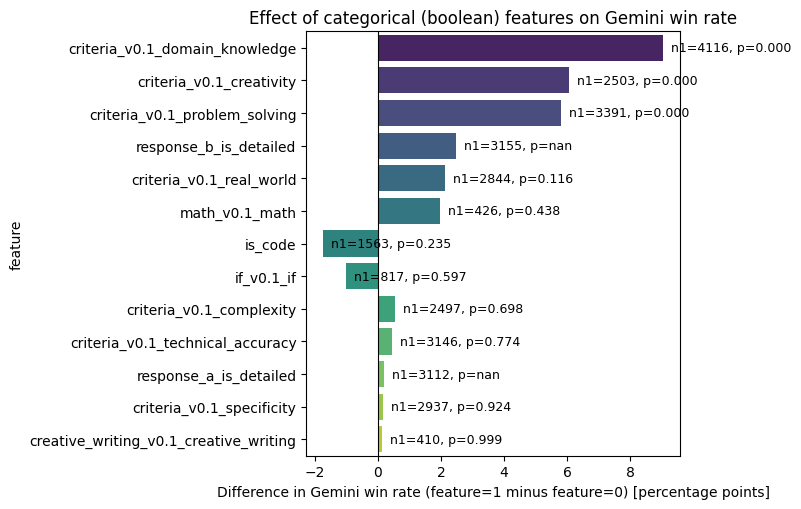

,feature,rate_when_1,rate_when_0,diff,pval,count_1,count_0
3,criteria_v0.1_domain_knowledge,0.695,0.605,0.090,0.0000,4116,891
2,criteria_v0.1_creativity,0.710,0.649,0.061,0.0000,2503,2504
4,criteria_v0.1_problem_solving,0.698,0.640,0.058,0.0000,3391,1616
12,response_b_is_detailed,0.688,0.664,0.025,nan,3155,1852
5,criteria_v0.1_real_world,0.688,0.667,0.021,0.1160,2844,2163
10,math_v0.1_math,0.697,0.678,0.020,0.4384,426,4581
9,is_code,0.667,0.685,-0.017,0.2352,1563,3444
8,if_v0.1_if,0.671,0.681,-0.010,0.5974,817,4190
1,criteria_v0.1_complexity,0.682,0.676,0.006,0.6977,2497,2510
7,criteria_v0.1_technical_accuracy,0.681,0.677,0.004,0.7740,3146,1861


In [86]:
# Categorical (boolean) candidates from flattened category_tag / other bools
cat_prefixes = ['creative_writing', 'criteria_v0.1', 'if_v0.1', 'math_v0.1']
cat_cols = []
for p in cat_prefixes:
    cat_cols += [c for c in df_final.columns if c.startswith(p)]
# Also include any other bool columns from dataset except control columns
bool_cols = [c for c in df_final.columns if df_final[c].dropna().isin([0,1]).all() and c not in ['a','b','gemini_win','winner_mapped']]
# Merge and unique
cat_cols = sorted(list(set(cat_cols + bool_cols)))

# Remove non-boolean ones (keep only columns with values 0/1)
final_cat_cols = []
for c in cat_cols:
    vals = df_final[c].dropna().unique()
    if set(vals).issubset({0,1}):
        final_cat_cols.append(c)
cat_cols = final_cat_cols

# -----------------------
# Categorical (boolean) features: win rates and chi2 test
# -----------------------
cat_results = []
for col in cat_cols:
    # Build contingency table: rows = feature value (0/1), cols = gemini_win (0/1)
    contingency = pd.crosstab(df_final[col], df_final['gemini_win'])
    # Ensure both rows exist
    if 0 not in contingency.index:
        contingency.loc[0] = [0,0]
    if 1 not in contingency.index:
        contingency.loc[1] = [0,0]
    contingency = contingency.sort_index()  # rows 0 then 1
    try:
        chi2, p, dof, expected = chi2_contingency(contingency)
    except Exception:
        p = np.nan
    # compute win rates
    rate_when_1 = df_final.loc[df_final[col]==1, 'gemini_win'].mean() if df_final[df_final[col]==1].shape[0]>0 else np.nan
    rate_when_0 = df_final.loc[df_final[col]==0, 'gemini_win'].mean() if df_final[df_final[col]==0].shape[0]>0 else np.nan
    diff = (rate_when_1 - rate_when_0)  # positive means feature=1 favors Gemini
    cat_results.append({
        'feature': col,
        'rate_when_1': rate_when_1,
        'rate_when_0': rate_when_0,
        'diff': diff,
        'pval': p,
        'count_1': int(df_final[df_final[col]==1].shape[0]),
        'count_0': int(df_final[df_final[col]==0].shape[0])
    })

cat_df = pd.DataFrame(cat_results).sort_values('diff', key=lambda s: s.abs(), ascending=False)

# Plot differences in win rate (percentage points)
plt.figure(figsize=(8, max(4, 0.4 * len(cat_df))))
sns.barplot(x=cat_df['diff']*100, y=cat_df['feature'], palette='viridis')
plt.axvline(0, color='k', linewidth=0.8)
plt.xlabel('Difference in Gemini win rate (feature=1 minus feature=0) [percentage points]')
plt.title('Effect of categorical (boolean) features on Gemini win rate')
# annotate counts and p-values
for i, row in cat_df.iterrows():
    idx = cat_df.index.get_loc(i)
    plt.text(row['diff']*100, idx, f"  n1={row['count_1']}, p={row['pval']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Show table of categorical results
display(cat_df.style.format({'rate_when_1':'{:.3f}','rate_when_0':'{:.3f}','diff':'{:.3f}','pval':'{:.4f}'}))


<h3> Interpretation guidance (quick) </h3>

**Numeric correlations**  
Positive correlation means higher feature values are associated with a higher probability of Gemini winning.  
The **p-value** shows whether the correlation is statistically meaningful (e.g., p < 0.05 suggests the correlation is unlikely to be due to chance).

**Categorical differences (0/1 features)**  
The value **'diff'** is `rate(feature=1) - rate(feature=0)`.  
Positive values mean the feature being **1** increases Gemini’s win rate.  
The **chi-square p-value** indicates whether this difference is likely to be real rather than noise.


<div id="Plot-17-Feature-Importance-for-Gemini-Win">
<h2>Plot 17: Feature Importance for Predicting Gemini Win</h2>
<p>
In this step, we use a Random Forest classifier to quantify the relative importance of different features in predicting whether Gemini wins a match.  
- We include the numeric feature <strong>context_tokens</strong> and categorical (boolean) features extracted from the dataset (e.g., <strong>creative_writing</strong>, <strong>criteria_v0.1</strong>, <strong>if_v0.1</strong>, <strong>math_v0.1</strong>).  
- The Random Forest model is trained on a stratified train-test split of the dataset with class balancing.  
- Feature importances are extracted from the trained model, reflecting each feature’s contribution to the predictive performance.  
- A horizontal bar chart visualizes these importances, allowing a clear comparison of which features most strongly influence the likelihood of a Gemini win.  
- Additionally, probability predictions and predicted labels for the test set are computed, enabling evaluation of model performance, e.g., accuracy and per-sample predicted probabilities.  
- This analysis helps identify key factors—both numeric and boolean—that drive Gemini’s success in matches.
</p>
</div>


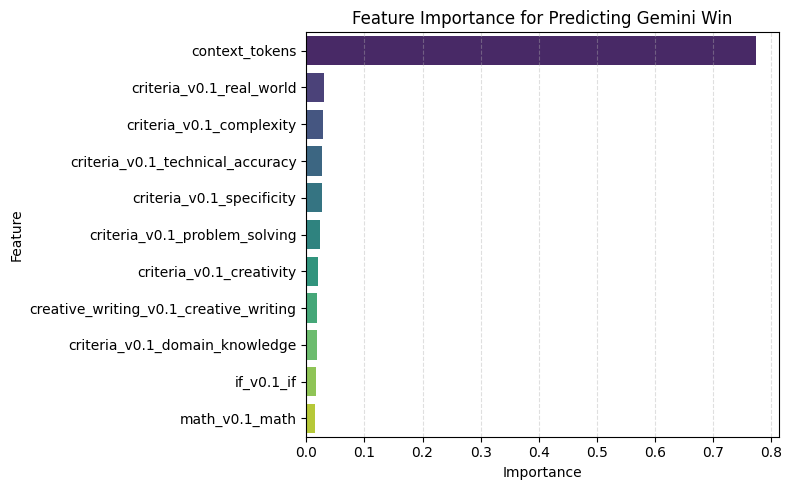

,feature,importance
0,context_tokens,0.773873
6,criteria_v0.1_real_world,0.029797
2,criteria_v0.1_complexity,0.029594
8,criteria_v0.1_technical_accuracy,0.027824
7,criteria_v0.1_specificity,0.026209
5,criteria_v0.1_problem_solving,0.023136
3,criteria_v0.1_creativity,0.020961
1,creative_writing_v0.1_creative_writing,0.018845
4,criteria_v0.1_domain_knowledge,0.018113
9,if_v0.1_if,0.017495


,probability_gemini_win,predicted_label,true_label
0,0.996667,1,0
1,0.371284,0,0
2,0.472384,0,1
3,0.404137,0,1
4,0.446490,0,1
5,0.550698,1,1
6,0.898806,1,1
7,0.986667,1,0
8,0.446696,0,0
9,0.298456,0,0


Random Forest accuracy on test set: 0.552


In [87]:
# --------------------------------------------------
# 1) Extract exactly the features specified
# --------------------------------------------------

cat_prefixes = ['creative_writing', 'criteria_v0.1', 'if_v0.1', 'math_v0.1']

# Find all boolean columns starting with these prefixes
cat_cols = []
for p in cat_prefixes:
    cat_cols += [c for c in df_final.columns if c.startswith(p)]

# Keep only columns that are strictly 0/1
cat_cols = [c for c in cat_cols if df_final[c].dropna().isin([0,1]).all()]

# Numeric feature
numeric_col = ['context_tokens']

# Final feature set
final_features = numeric_col + cat_cols


# --------------------------------------------------
# 2) Prepare data
# --------------------------------------------------

df_model = df_final[final_features + ['gemini_win']].dropna()

X = df_model[final_features]
y = df_model['gemini_win']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# --------------------------------------------------
# 3) Random Forest model
# --------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


# --------------------------------------------------
# 4) Feature importance extraction
# --------------------------------------------------

imp_df = pd.DataFrame({
    'feature': final_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)


# --------------------------------------------------
# 5) Plot feature importances
# --------------------------------------------------

plt.figure(figsize=(8, max(5, 0.35 * len(imp_df))))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title("Feature Importance for Predicting Gemini Win")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

display(imp_df)


# --------------------------------------------------
# 6) Add probability predictions
# --------------------------------------------------
# Random Forest returns probability for each class.
# [:, 1] is the probability of class '1' → Gemini win.

probs = rf.predict_proba(X_test)[:, 1]
preds = rf.predict(X_test)

prediction_df = pd.DataFrame({
    'probability_gemini_win': probs,
    'predicted_label': preds,
    'true_label': y_test.values
})

display(prediction_df.head(20))


# --------------------------------------------------
# 7) Model accuracy
# --------------------------------------------------
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
print("Random Forest accuracy on test set:", round(accuracy, 3))


<div id="Plot-18-Cumulative-Win-Rate-Curve"> 
<h2>Plot 18: Cumulative Win Rate Curve for Gemini</h2>
<p>
In this step, we visualize how the predicted probability of Gemini winning evolves as features are gradually activated according to their importance.  
- We use the features identified previously (both numeric and boolean, including context_tokens, creative_writing, criteria_v0.1, if_v0.1, math_v0.1) and order them by their <strong>Random Forest feature importance</strong>.  
- Starting with all features inactive, we calculate the baseline predicted probability of a Gemini win.  
- Then, one by one, features are activated in order of importance, and the mean predicted probability of a Gemini win across the test set is computed at each step.  
- A cumulative line plot is drawn showing the progression of Gemini’s predicted win probability as more features are included.  
- Each point on the curve is annotated with the corresponding feature name and the predicted probability, highlighting which features contribute most to increasing the likelihood of a Gemini win.  
- This visualization provides an intuitive understanding of how individual features cumulatively affect model predictions and which factors are most influential in achieving a Gemini win.
</p>
</div>


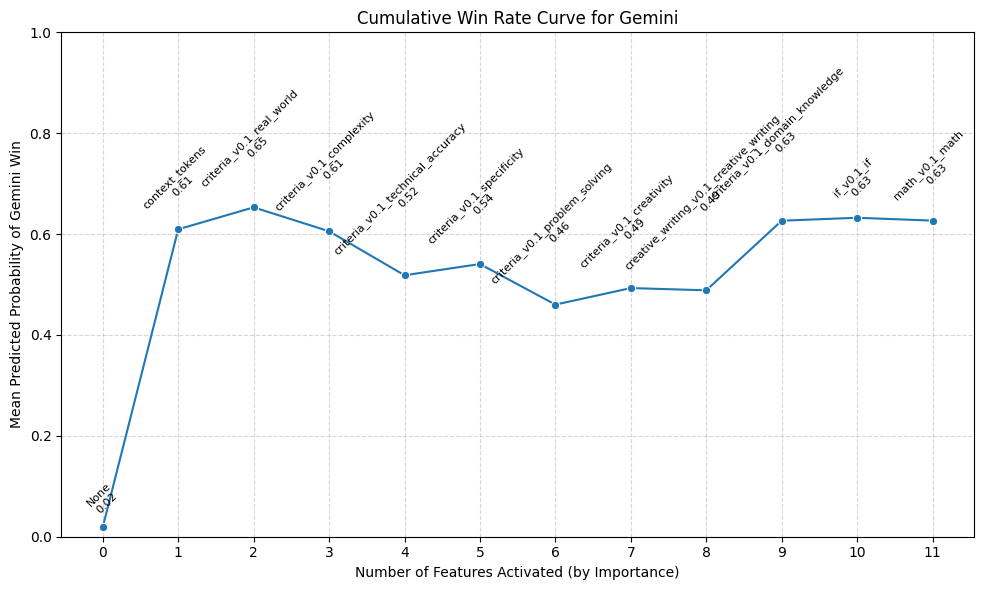

In [88]:
# --------------------------------------------------
# Cumulative Win Rate Curve with Annotations
# --------------------------------------------------

# 1) Sort features by importance descending
sorted_features = imp_df['feature'].tolist()

# 2) Prepare DataFrame to store cumulative probabilities
cumulative_probs = []

# Copy of X_test for manipulation
X_test_cum = X_test.copy()

# Start with all features inactive (0)
for f in sorted_features:
    X_test_cum[f] = 0

# Base probability: all features inactive
base_probs = rf.predict_proba(X_test_cum)[:, 1]
cumulative_probs.append({'n_features': 0, 'mean_prob': base_probs.mean(), 'feature_activated': 'None'})

# Activate features one by one in order of importance
for i, f in enumerate(sorted_features, start=1):
    X_test_cum[f] = X_test[f]  # set feature values from test set
    probs = rf.predict_proba(X_test_cum)[:, 1]
    cumulative_probs.append({'n_features': i, 'mean_prob': probs.mean(), 'feature_activated': f})

# Convert to DataFrame
cum_df = pd.DataFrame(cumulative_probs)

# --------------------------------------------------
# Plot Cumulative Win Rate Curve with Annotations
# --------------------------------------------------
plt.figure(figsize=(10,6))
sns.lineplot(data=cum_df, x='n_features', y='mean_prob', marker='o')
plt.xlabel('Number of Features Activated (by Importance)')
plt.ylabel('Mean Predicted Probability of Gemini Win')
plt.title('Cumulative Win Rate Curve for Gemini')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, len(sorted_features)+1))
plt.ylim(0,1)

# Annotate each point with the feature name and probability
for _, row in cum_df.iterrows():
    plt.text(row['n_features'], row['mean_prob'] + 0.02, 
             f"{row['feature_activated']}\n{row['mean_prob']:.2f}", 
             ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()


In [89]:
# --------------------------------------------------
# 1) Sort features by importance descending
# --------------------------------------------------
sorted_features = imp_df['feature'].tolist()

# --------------------------------------------------
# 2) Prepare DataFrame to store cumulative probabilities
# --------------------------------------------------
cumulative_probs = []

# Copy of X_test for manipulation
X_test_cum = X_test.copy()

# Start with all features inactive (0)
for f in sorted_features:
    X_test_cum[f] = 0

# Base probability: all features inactive
base_probs = rf.predict_proba(X_test_cum)[:, 1]
cumulative_probs.append({
    'n_features': 0,
    'mean_prob': base_probs.mean(),
    'feature_activated': 'None'
})

# Activate features one by one in order of importance
for i, f in enumerate(sorted_features, start=1):
    X_test_cum[f] = X_test[f]
    probs = rf.predict_proba(X_test_cum)[:, 1]
    cumulative_probs.append({
        'n_features': i,
        'mean_prob': probs.mean(),
        'feature_activated': f
    })

# Convert to DataFrame
cum_df = pd.DataFrame(cumulative_probs)

# Create hover text for tooltip
cum_df['hover_text'] = cum_df.apply(
    lambda row: f"Feature Activated: {row['feature_activated']}<br>"
                f"Number of Features: {row['n_features']}<br>"
                f"Mean Predicted Probability: {row['mean_prob']:.3f}", axis=1
)

# --------------------------------------------------
# 3) Plot with Plotly for interactive tooltip only
# --------------------------------------------------
fig = px.line(
    cum_df,
    x='n_features',
    y='mean_prob',
    markers=True,
    hover_name='feature_activated',
    hover_data={'n_features': True, 'mean_prob': ':.3f'},
    labels={
        'n_features': 'Number of Features Activated (by Importance)',
        'mean_prob': 'Mean Predicted Probability of Gemini Win'
    },
    title='Cumulative Win Rate Curve for Gemini'
)

# Remove text on points
fig.update_traces(text=None)

# Layout adjustments
fig.update_layout(
    width=1200,
    height=700,
    template='plotly_white',
    xaxis=dict(dtick=1),
    yaxis=dict(range=[0, 1]),
    hovermode='closest'
)

fig.show()


### checking emojis with emoji


In [90]:
import emoji
checking_emojis = ['conversation_a', 'conversation_b', 'response_a', 'response_b']
for checking_emoji in checking_emojis:
    has_emoji = any(ch in emoji.EMOJI_DATA for ch in df[checking_emoji])
    print(f'\n{checking_emoji} column has emojis? {has_emoji}')


conversation_a column has emojis? False

conversation_b column has emojis? False

response_a column has emojis? False

response_b column has emojis? False


## Embeding prompt (similarity)

In [91]:
df_embeding = pd.read_csv('embedding_lmarena_total_eval_1_turn_1_new.csv')

In [92]:
df_embeding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92476 entries, 0 to 92475
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           92476 non-null  object
 1   user_prompt  92476 non-null  object
 2   embedding    92476 non-null  object
dtypes: object(3)
memory usage: 2.1+ MB


In [93]:
# filter Model Dataset with ID
df_embeding_gemini = df_embeding[df_embeding['id'].isin(df1['id'])].copy()

# adding language column
df_embeding_gemini['language'] = df_embeding_gemini['id'].map(df1.set_index('id')['language'])

print(df_embeding_gemini.info())
print('report Nan column:','\n',df_embeding_gemini.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 9425 entries, 0 to 92464
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9425 non-null   object
 1   user_prompt  9425 non-null   object
 2   embedding    9425 non-null   object
 3   language     9425 non-null   object
dtypes: object(4)
memory usage: 368.2+ KB
None
report Nan column: 
 id             0
user_prompt    0
embedding      0
language       0
dtype: int64


In [94]:
from sklearn.metrics.pairwise import cosine_similarity
def ensure_list(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x
df_embeding_gemini = df_embeding_gemini.copy()
df_embeding_gemini['embedding'] = df_embeding_gemini['embedding'].apply(ensure_list)
emb_matrix = np.vstack(df_embeding_gemini['embedding'].values)

sim_matrix = cosine_similarity(emb_matrix, emb_matrix)


print(emb_matrix.shape)
print(sim_matrix.shape)

sim_df = pd.DataFrame(sim_matrix, index=df_embeding_gemini.index, columns=df_embeding_gemini.index)

(9425, 768)
(9425, 9425)


### Plot 19: Similarity Matrix (Cosine Similarity)
This figure shows a cosine similarity matrix for a random sample of 1,000 items from the dataset. Each cell in the heatmap represents the similarity between a pair of items, where lighter colors indicate higher cosine similarity values (closer to 1) and darker colors indicate lower similarity (closer to 0). 

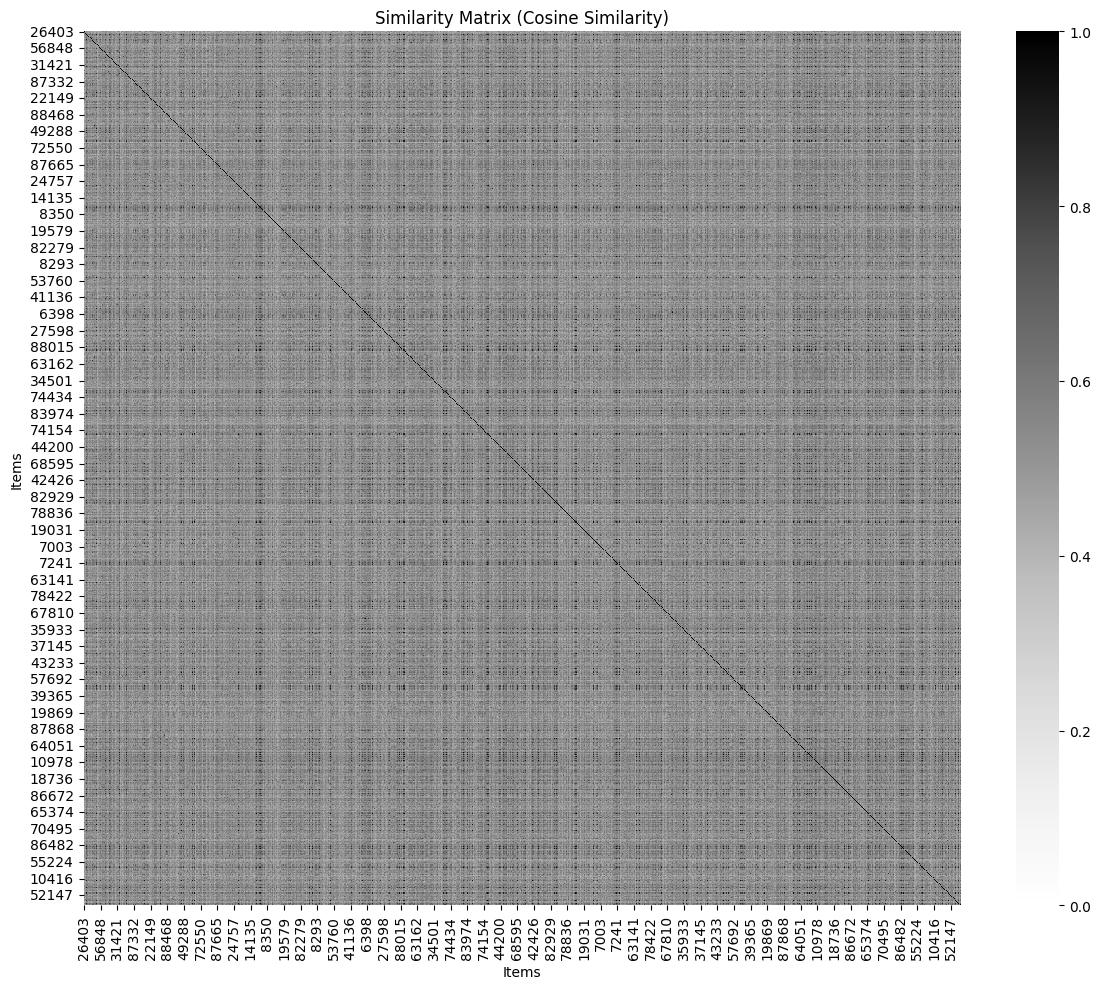

In [95]:
sample_ids = np.random.choice(sim_df.index, size=1000, replace=False)
sim_sub = sim_df.loc[sample_ids, sample_ids]

plt.figure(figsize=(12, 10))
sns.heatmap(sim_sub, cmap='Greys', vmin=0, vmax=1)
plt.title("Similarity Matrix (Cosine Similarity)")
plt.xlabel("Items")
plt.ylabel("Items")
plt.tight_layout()
plt.show()

### Plot 20: Distribution of pairwise similarities
These two histograms show the distribution of pairwise cosine similarities between item embeddings. In the first plot, all languages are included: each bar represents how many item pairs fall into a given similarity range

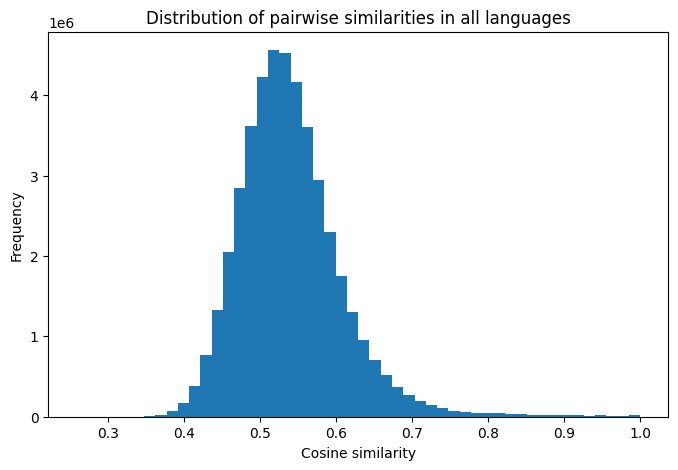

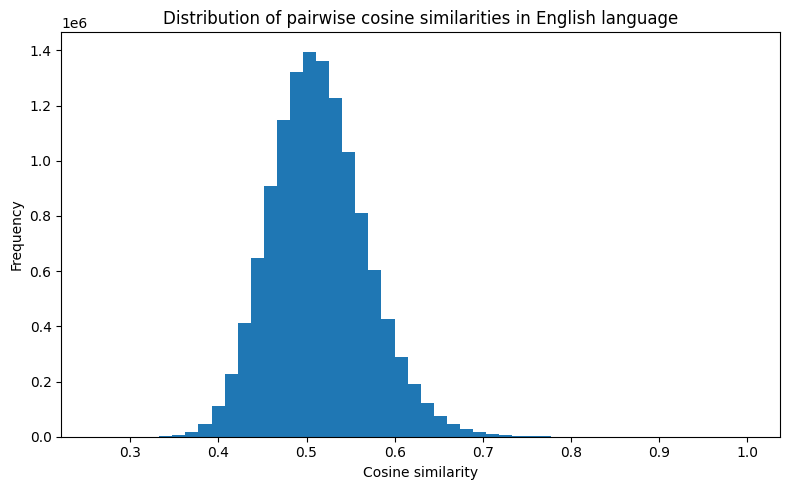

In [96]:
triu_indices = np.triu_indices_from(sim_matrix, k=1)
sims_flat = sim_matrix[triu_indices]

plt.figure(figsize=(8, 5))
plt.hist(sims_flat, bins=50)

plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.title("Distribution of pairwise similarities in all languages")
plt.show()

mask_en = df_embeding_gemini['language'] == 'en'
idx_en = np.where(mask_en)[0]       
sim_en_matrix = sim_matrix[np.ix_(idx_en, idx_en)]  
triu_idx = np.triu_indices_from(sim_en_matrix, k=1)
sims_flat_en = sim_en_matrix[triu_idx]
plt.figure(figsize=(8, 5))
plt.hist(sims_flat_en, bins=50)
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.title("Distribution of pairwise cosine similarities in English language")
plt.tight_layout()
plt.show()

### Plot 21: UMAP projection of embeddings
These figures show a two-dimensional UMAP projection of the embedding space, where each point is an item and its position reflects its semantic relationships to other items

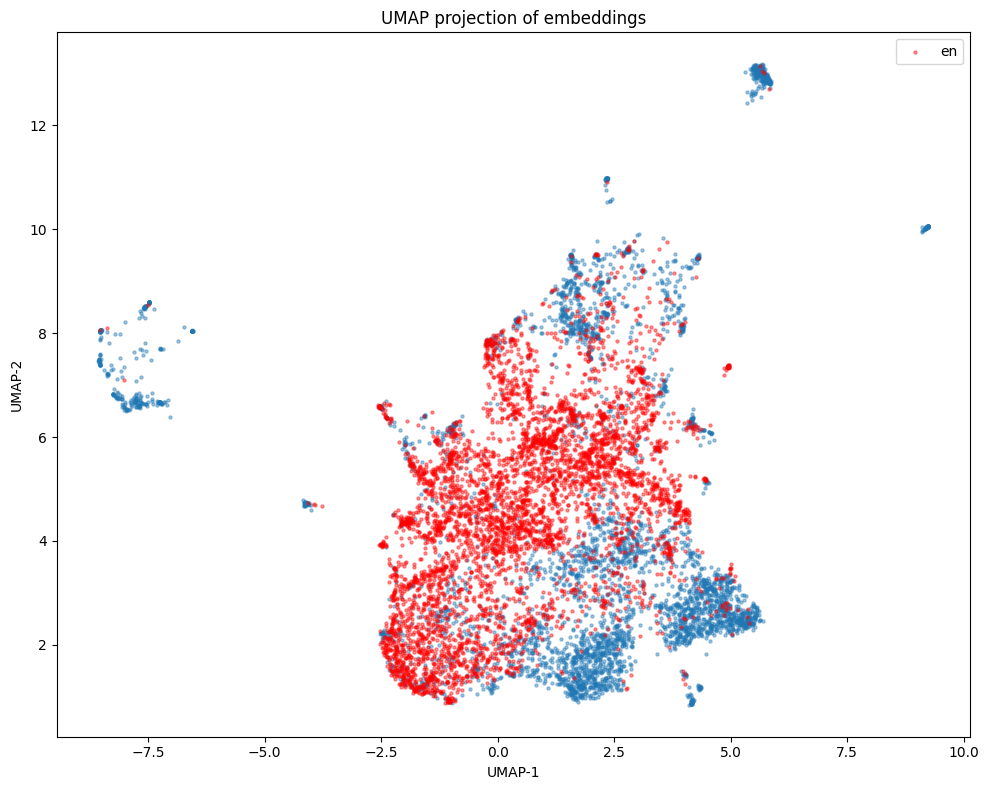

In [97]:
reducer = umap.UMAP(random_state=42, n_jobs=1) #metric='cosine'
emb_2d = reducer.fit_transform(emb_matrix)
mask_en = df_embeding_gemini['language'] == 'en'

plt.figure(figsize=(10, 8))
plt.scatter(emb_2d[~mask_en, 0], emb_2d[~mask_en, 1], s=5, alpha=0.4)
plt.scatter(emb_2d[mask_en, 0], emb_2d[mask_en, 1], s=5, alpha=0.4, color='red', label='en')
plt.title("UMAP projection of embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()

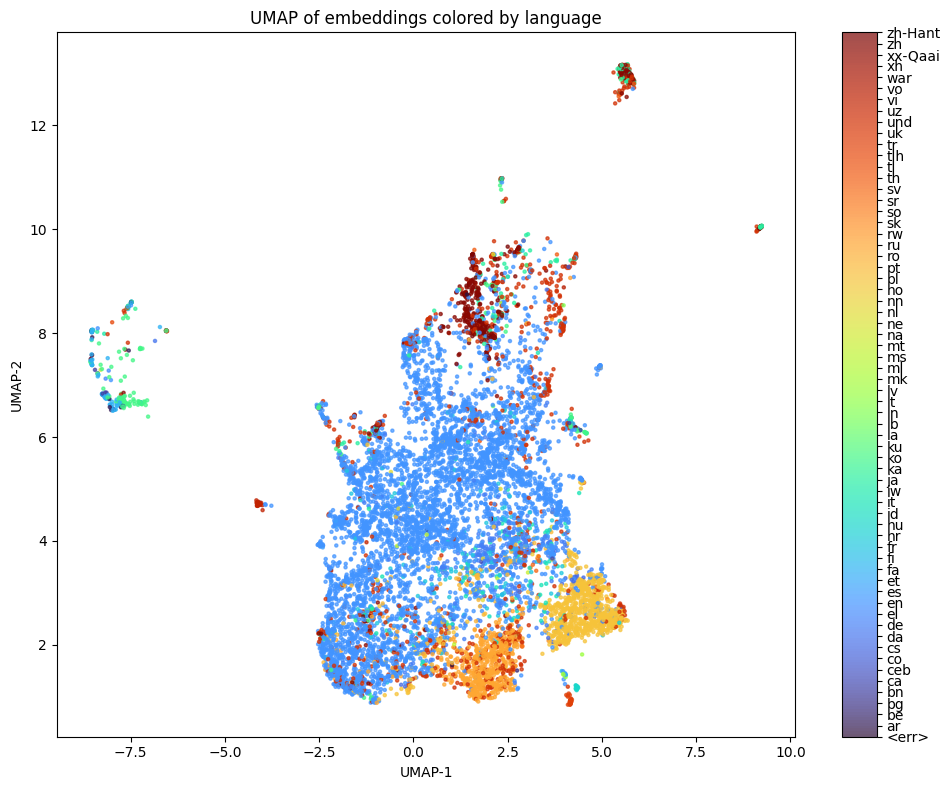

In [98]:
df_umap = df_embeding_gemini  
lang_cat = df_umap['language'].astype('category')

lang_codes = lang_cat.cat.codes           
lang_labels = list(lang_cat.cat.categories) 
plt.figure(figsize=(10, 8))

sc = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=lang_codes,
    cmap='turbo',
    alpha=0.7,
    s=5
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of embeddings colored by language")

cbar = plt.colorbar(sc)
cbar.set_ticks(range(len(lang_labels)))
cbar.set_ticklabels(lang_labels)

plt.tight_layout()
plt.show()

### plot 22: Within-language similarity distribution
These two plots summarize how similar items are within each language in the embedding space.

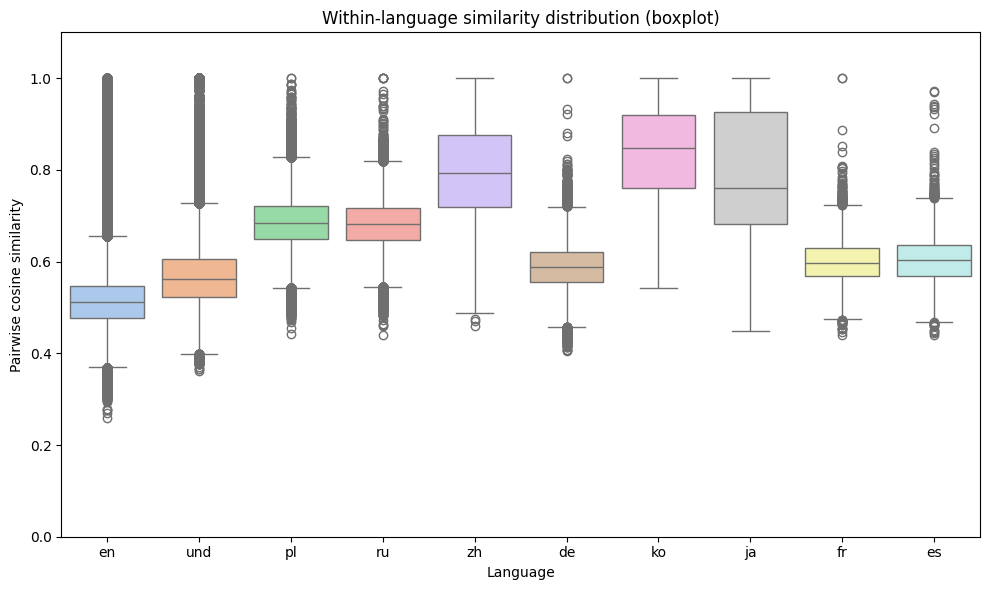

In [99]:
lang_counts = df_embeding_gemini['language'].value_counts()
top_langs = lang_counts.head(10).index.tolist()
print()
rows = []

for lang in top_langs:
    mask = df_embeding_gemini['language'] == lang
    idx = np.where(mask)[0]   

    sim_sub = sim_matrix[np.ix_(idx, idx)]   

    tri = np.triu_indices_from(sim_sub, k=1)
    sims_flat = sim_sub[tri]

    for s in sims_flat:
        rows.append({"language": lang, "similarity": s})
df_box = pd.DataFrame(rows)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_box,
    x='language',
    y='similarity',
    palette= 'pastel'
)

plt.xlabel("Language")
plt.ylabel("Pairwise cosine similarity")
plt.title("Within-language similarity distribution (boxplot)")
plt.ylim(0, 1.1)  
plt.tight_layout()
plt.show()


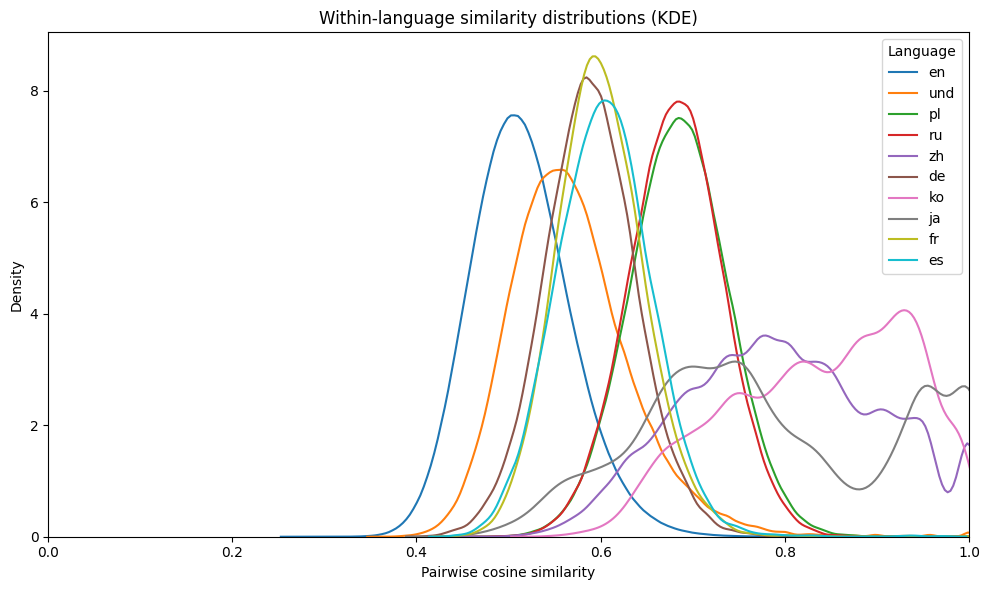

In [100]:
similarity_data = {}

for lang in top_langs:
    mask = df_embeding_gemini['language'] == lang
    idx = np.where(mask)[0]  

    sim_sub = sim_matrix[np.ix_(idx, idx)]

    tri = np.triu_indices_from(sim_sub, k=1)
    sims_flat = sim_sub[tri]

    similarity_data[lang] = sims_flat

plt.figure(figsize=(10, 6))

for lang, sims in similarity_data.items():
   

    sns.kdeplot(
        sims,
        label=lang,
        fill=False, 
        linewidth=1.5
    )
    
plt.xlabel("Pairwise cosine similarity")
plt.ylabel("Density")
plt.title("Within-language similarity distributions (KDE)")
plt.xlim(0, 1)   
plt.legend(title="Language")
plt.tight_layout()
plt.show()


### Plot 23: Mean cosine & strong connections similarity between languages
These two figures summarize how similar the embedding space is across languages. The heatmap shows **the mean cosine similarity between pairs of languages**

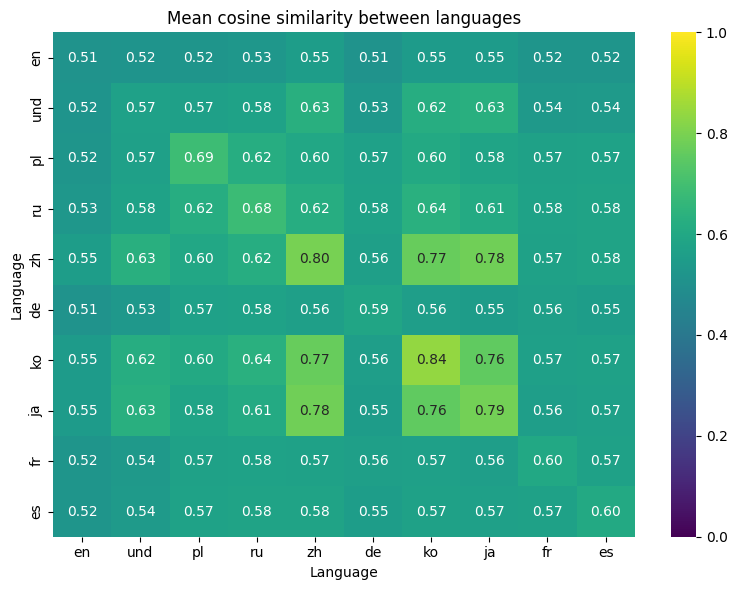

In [101]:
lang_counts = df_embeding_gemini['language'].value_counts()

min_count = 20
lang_counts_filtered = lang_counts[lang_counts >= min_count]

top_n = 10
langs = lang_counts_filtered.head(top_n).index.tolist()

lang_to_idx = {}
for lang in langs:
    mask = df_embeding_gemini['language'] == lang
    idx = np.where(mask)[0]      
    lang_to_idx[lang] = idx


L = len(langs)
mean_sims = np.full((L, L), np.nan)

for i, lang_i in enumerate(langs):
    idx_i = lang_to_idx[lang_i]
    for j, lang_j in enumerate(langs):
        idx_j = lang_to_idx[lang_j]

        if len(idx_i) == 0 or len(idx_j) == 0:
            continue

        if i == j:
            if len(idx_i) < 2:
                continue
            sim_sub = sim_matrix[np.ix_(idx_i, idx_i)]    
            tri = np.triu_indices_from(sim_sub, k=1)
            vals = sim_sub[tri]
        else:
            sim_sub = sim_matrix[np.ix_(idx_i, idx_j)]   
            vals = sim_sub.ravel()

        if vals.size == 0:
            continue

        mean_sims[i, j] = vals.mean()

sim_df = pd.DataFrame(mean_sims, index=langs, columns=langs)

plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_df,
    annot=True,       
    fmt=".2f",
    vmin=0.0,
    vmax=1.0,        
    cmap="viridis"
)

plt.title("Mean cosine similarity between languages")
plt.xlabel("Language")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

Number of nodes in graph: 500
sim_sub shape: (500, 500)
Number of nodes: 500
Number of edges: 2899


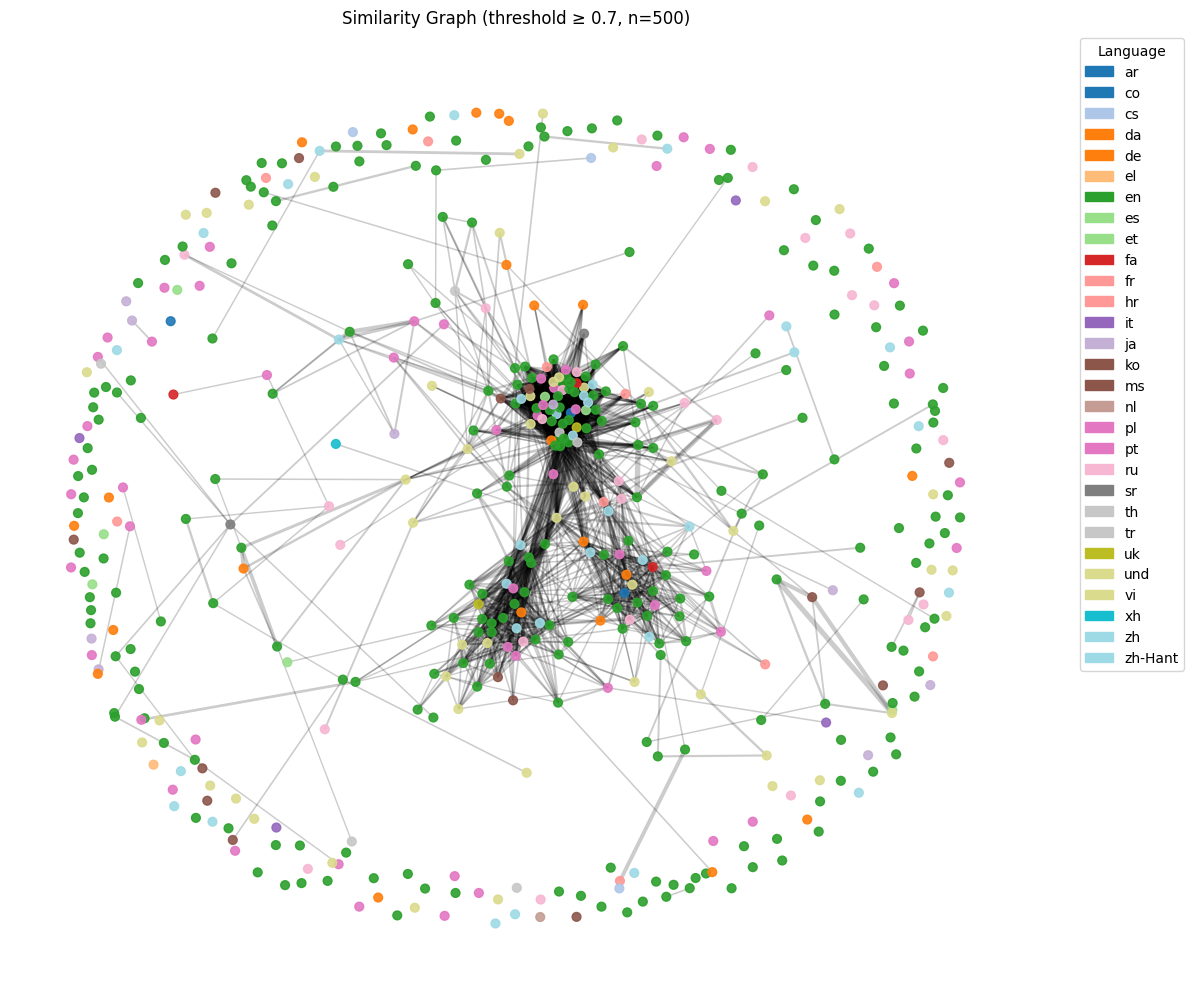

In [103]:
import networkx as nx
df_sim = df_embeding_gemini.copy()  
df_sim = df_sim.reset_index(drop=True) 

def ensure_list(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

df_sim['embedding'] = df_sim['embedding'].apply(ensure_list)
emb_matrix = np.vstack(df_sim['embedding'].values)
sim_matrix = cosine_similarity(emb_matrix, emb_matrix)
df_sub = df_sim.copy()
subset_n = 500
if len(df_sub) > subset_n:
    df_sub = df_sub.sample(subset_n, random_state=42)

idx_sub = df_sub.index.to_numpy()

print("Number of nodes in graph:", len(idx_sub))

sim_sub = sim_matrix[np.ix_(idx_sub, idx_sub)]
print("sim_sub shape:", sim_sub.shape)

G = nx.Graph()

for local_i, global_i in enumerate(idx_sub):
    G.add_node(
        local_i, 
        language=df1.loc[global_i, 'language'],
    )

threshold = 0.7

n = len(idx_sub)
for i in range(n):
    for j in range(i + 1, n):
        s = sim_sub[i, j]
        if s >= threshold:
            G.add_edge(i, j, weight=float(s))

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

pos = nx.spring_layout(G, k=0.3, iterations=60, seed=42)

languages = sorted({G.nodes[n]['language'] for n in G.nodes})
num_langs = len(languages)

cmap = plt.get_cmap('tab20')  
lang_to_color = {
    lang: cmap(i / max(1, num_langs - 1))
    for i, lang in enumerate(languages)
}

node_colors = [lang_to_color[G.nodes[n]['language']] for n in G.nodes]

edge_weights = [G[u][v]['weight'] for u, v in G.edges]

edge_widths = [1 + 3*(w - threshold)/(1 - threshold) for w in edge_weights]

plt.figure(figsize=(12, 10))

# edges
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    width=edge_widths
)

# nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=40,
    alpha=0.9
)

plt.axis('off')
plt.title(f"Similarity Graph (threshold ≥ {threshold}, n={len(idx_sub)})")

handles = [
    mpatches.Patch(color=lang_to_color[lang], label=lang)
    for lang in languages
]
plt.legend(
    handles=handles,
    title="Language",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()